In [ ]:
# ============================================================
#  Sabin Poudel , ID: 113034860, IEEM 
# ============================================================

import os
import sys
import time
import shutil
import ctypes
import warnings
from pathlib import Path
from dataclasses import dataclass, fields
from functools import partial

import numpy as np
import pandas as pd
import scipy.optimize as spo
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

try:
    import umap
    UMAP_AVAILABLE = True
except Exception as e:
    umap = None
    UMAP_AVAILABLE = False
    print("UMAP unavailable; PCA fallback will be used for manifold diagnostics:", repr(e))

import jax
import jax.numpy as jnp

# Required JAX ecosystem libraries
import optax
import diffrax
import lineax as lx
import jaxopt

warnings.filterwarnings("ignore")
jax.config.update("jax_enable_x64", True)

print("Python:", sys.executable)
print("JAX:", jax.__version__)
print("JAX devices:", jax.devices())
print("Optax:", optax.__version__ if hasattr(optax, "__version__") else "installed")
print("Diffrax:", diffrax.__version__ if hasattr(diffrax, "__version__") else "installed")
print("UMAP available:", UMAP_AVAILABLE)

# -----------------------------
# ACADOS setup
# -----------------------------
ACADOS_ROOT = Path.home() / "acados"
ACADOS_LIB = ACADOS_ROOT / "lib"
ACADOS_TEMPLATE_PATH = ACADOS_ROOT / "interfaces" / "acados_template"

os.environ["ACADOS_SOURCE_DIR"] = str(ACADOS_ROOT)
os.environ["LD_LIBRARY_PATH"] = f"{ACADOS_LIB}:{os.environ.get('LD_LIBRARY_PATH', '')}"

if str(ACADOS_TEMPLATE_PATH) not in sys.path:
    sys.path.insert(0, str(ACADOS_TEMPLATE_PATH))

try:
    import casadi as ca
    from acados_template import AcadosModel, AcadosOcp, AcadosOcpSolver
    ACADOS_AVAILABLE = True
    print("ACADOS available")
except Exception as e:
    ca = None
    AcadosModel = None
    AcadosOcp = None
    AcadosOcpSolver = None
    ACADOS_AVAILABLE = False
    print("ACADOS unavailable:", repr(e))

def preload_acados_libraries():
    if not ACADOS_AVAILABLE:
        return
    for name in ["libblasfeo.so", "libhpipm.so", "libacados.so"]:
        p = ACADOS_LIB / name
        if p.exists():
            ctypes.CDLL(str(p), mode=ctypes.RTLD_GLOBAL)

preload_acados_libraries()

# -----------------------------
# Global configuration settings:
# DT, HORIZON, N_CANDIDATES: fundamental NMPC hyperparameters.

# -----------------------------
N = 20  # NMPC prediction horizon
NX = 7  # [X, Y, psi, vx, vy, r, delta]
NU = 2  # [delta_rate, rear_longitudinal_force]
DT = 0.08  # integration timestep
CLOSED_LOOP_STEPS = 40  # Number NMPC of Horizon  steps 
N_CANDIDATES = 8 # Batched Candidate evaluation 
FIG_DPI = 300
BENCHMARK_SEED = 40
RUN_REAL_ACADOS = ACADOS_AVAILABLE

#jit, vmap, lax.scan: core JAX function transformations enabling fast, batched, differentiable NMPC.
#diffrax: vehicle integration (RK4 or adaptive).diffrax computes the forward dynamics over HORIZON steps,
# essential for predicting vehicle states under candidate controls.
# optax, jaxopt: optimizer backends for Gauss–Newton or other gradient


Cell 2: This block defines the shared infrastructure used throughout the autonomous drifting NMPC notebook.

It includes:

### Components

- **Physical vehicle parameters**, such as mass, inertia, wheelbase geometry, and tire-related constants.

- **Actuator bounds**, including limits on:
  - Steering angle
  - Steering rate
  - Longitudinal force or acceleration commands

- **Normalization and denormalization maps** used to scale states, controls, and optimization variables into numerically convenient ranges.

- **JAX PyTree support**, allowing custom parameter containers or structured data objects to work naturally with JAX transformations.

- **Numerical utility functions** for stable computation, clipping, wrapping angles, and handling vectorized array operations.

- **Timing and plotting helpers** used to benchmark NMPC execution and visualize simulation results.

 it provides the parameter definitions and numerical infrastructure required by later notebook blocks, including:

- Vehicle dynamics
- Trajectory rollout
- Cost function evaluation
- NMPC optimization
- Closed-loop simulation
- Timing analysis
- Plotting and visualization

### Purpose

The main problem solved by this block is **standardizing model parameters and numerical transformations** so that the later JAX-based NMPC code can be:

- Differentiated
- Vectorized
- JIT-compiled
- Timed
- Plotted consistently




It also defines an **immutable container** for the vehicle’s basic physical parameters using a Python `@dataclass(frozen=True)`:

```python
from dataclasses import dataclass

@dataclass(frozen=True)
class VehicleParams:
    mass_kg: float = 1800.0             # Vehicle mass
    yaw_inertia_kg_m2: float = 2800.0  # Yaw moment of inertia
    lf_m: float = 1.2                   # Distance from CG to front axle
    lr_m: float = 1.6                   # Distance from CG to rear axle
    g_m_s2: float = 9.81                # Gravitational acceleration 


**simplified tire-model parameters**:

- `front_B, front_C`: Front tire shape factors  
- `rear_B, rear_C`: Rear tire shape factors  

These parameters form a **simplified Pacejka-like lateral tire saturation model**, controlling how **lateral tire force grows and saturates** with slip angle.

---

## Friction and Actuator Limits

The block defines bounds used to constrain vehicle control and dynamics:

- `mu_nominal`: Nominal tire-road friction coefficient  
- `max_steer_rad`: Maximum steering angle (radians)  
- `max_steer_rate_rad_s`: Maximum steering rate (rad/s)  
- `min_rear_force_n`, `max_rear_force_n`: Rear longitudinal force limits (Newtons)  
- `min_vx_m_s`, `max_vx_m_s`: Longitudinal velocity bounds (m/s)  

These bounds are later used to **restrict**:

- Steering angle  
- Steering rate  
- Rear longitudinal force  
- Longitudinal speed


This block also defines **simple drag coefficients**:

- `drag_quad`: Quadratic drag coefficient, representing aerodynamic drag  
- `drag_lin`: Linear drag coefficient, representing rolling resistance  

These coefficients are later used to **approximate longitudinal resistance effects** on the vehicle, including both **aerodynamic drag** and **rolling friction**, within the NMPC simulation.



To enable JAX transformations, `VehicleParams` is registered as a **PyTree**:

```python
import jax

jax.tree_util.register_pytree_node(
    VehicleParams,
    _vehicle_params_flatten,
    _vehicle_params_unflatten,
)

# JAX PyTree Support for `VehicleParams`

This is important because **JAX transformations** such as:

- `jit` (just-in-time compilation)  
- `vmap` (vectorization)  
- `grad` (automatic differentiation)  
- `jacfwd` / `jacrev` (Jacobian forward/reverse mode)  

operate naturally on **PyTrees**.

The helper functions:

```python
_vehicle_params_flatten(params)
_vehicle_params_unflatten(names, children)



# Static Front and Rear Axle Normal Loads

```python
FZ_F = P.mass_kg * P.g_m_s2 * P.lr_m / (P.lf_m + P.lr_m)
FZ_R = P.mass_kg * P.g_m_s2 * P.lf_m / (P.lf_m + P.lr_m)

These compute the static front and rear axle normal loads:

\[
F_{z,f} = \frac{m g l_r}{l_f + l_r}
\]

\[
F_{z,r} = \frac{m g l_f}{l_f + l_r}
\]

These loads are later used to scale tire-force capacity through friction.

This is physically reasonable for a first-order model, but it is also a major simplification. In drifting, longitudinal and lateral acceleration cause significant dynamic load transfer. Static loads alone cannot capture transient tire saturation, throttle-induced rear saturation, or aggressive yaw initiation accurately. The static front and rear axle normal loads are computed from the vehicle mass, gravity, and axle distances, providing a first-order load distribution for later tire-force scaling. 

It then defines the control-input normalization through `U_CENTER` and `U_SCALE`, where the physical inputs are steering-rate command and rear longitudinal force. The functions `u_from_z` and `z_from_u_jax` map between unconstrained optimizer variables and bounded physical controls using a `tanh` transformation and its clipped inverse, allowing the optimizer to operate in an unconstrained space while respecting actuator limits. 

The angle-wrapping utilities keep yaw-related errors within [−π, π], avoiding artificial discontinuities in heading error. The `smooth_hinge` function provides a differentiable approximation of inequality-constraint violation penalties, which is useful for gradient-based NMPC but also indicates that some constraints are treated softly rather than as exact hard constraints. 

The `sideslip` function `beta_jax` computes \(\beta = \arctan2(v_y, v_x)\), using a lower bound on \(v_x\) to avoid numerical singularity at very low speed. 

Finally, the tree utilities support JAX execution and diagnostics: `block_ready` forces asynchronous JAX computations to complete before timing, `timed_call` reports reliable post-execution runtime, `tree_l2_norm` measures the norm of PyTree-valued quantities such as updates or gradients, `tree_clip` applies elementwise clipping across PyTrees, and `savefig` standardizes figure export. 

Together, these utilities provide the numerical infrastructure for bounded-input NMPC, differentiable constraint penalties, sideslip monitoring, reproducible timing, and consistent visualization.



In [63]:

@dataclass(frozen=True)
class VehicleParams:
    mass_kg: float = 1800.0
    yaw_inertia_kg_m2: float = 2800.0
    lf_m: float = 1.2
    lr_m: float = 1.6
    g_m_s2: float = 9.81

    front_B: float = 10.0
    front_C: float = 1.3
    rear_B: float = 9.0
    rear_C: float = 1.25

    mu_nominal: float = 0.95

    max_steer_rad: float = 0.60
    max_steer_rate_rad_s: float = 1.50
    min_rear_force_n: float = -4000.0
    max_rear_force_n: float = 5000.0

    min_vx_m_s: float = 2.0
    max_vx_m_s: float = 30.0

    drag_quad: float = 0.45
    drag_lin: float = 35.0

P = VehicleParams()

def _vehicle_params_flatten(params):
    names = tuple(field.name for field in fields(VehicleParams))
    children = tuple(getattr(params, name) for name in names)
    return children, names

def _vehicle_params_unflatten(names, children):
    return VehicleParams(**dict(zip(names, children)))

jax.tree_util.register_pytree_node(
    VehicleParams,
    _vehicle_params_flatten,
    _vehicle_params_unflatten,
)

FZ_F = P.mass_kg * P.g_m_s2 * P.lr_m / (P.lf_m + P.lr_m)
FZ_R = P.mass_kg * P.g_m_s2 * P.lf_m / (P.lf_m + P.lr_m)

U_CENTER = jnp.array([0.0, 0.5 * (P.max_rear_force_n + P.min_rear_force_n)])
U_SCALE = jnp.array([P.max_steer_rate_rad_s, 0.5 * (P.max_rear_force_n - P.min_rear_force_n)])

@jax.jit
def wrap_angle_jax(a):
    return (a + jnp.pi) % (2.0 * jnp.pi) - jnp.pi

def wrap_angle_np(a):
    return (a + np.pi) % (2.0 * np.pi) - np.pi

@jax.jit
def smooth_hinge(g, sharpness=30.0):
    return jax.nn.softplus(sharpness * g) / sharpness

@jax.jit
def u_from_z(z):
    return U_CENTER + U_SCALE * jnp.tanh(z)

@jax.jit
def z_from_u_jax(u):
    q = jnp.clip((u - U_CENTER) / U_SCALE, -0.999, 0.999)
    return jnp.arctanh(q)

def z_from_u_np(u):
    q = np.clip((u - np.asarray(U_CENTER)) / np.asarray(U_SCALE), -0.999, 0.999)
    return np.arctanh(q)

@jax.jit
def beta_jax(x):
    return jnp.arctan2(x[..., 4], jnp.maximum(x[..., 3], 1e-3))

def beta_np(x):
    return np.arctan2(x[..., 4], np.maximum(x[..., 3], 1e-3))

def block_ready(tree):
    return jax.tree.map(
        lambda x: x.block_until_ready() if hasattr(x, "block_until_ready") else x,
        tree,
    )

def timed_call(fn, *args, **kwargs):
    t0 = time.perf_counter()
    out = fn(*args, **kwargs)
    block_ready(out)
    return out, (time.perf_counter() - t0) * 1000.0

def tree_l2_norm(tree):
    leaves = jax.tree.leaves(tree)
    return jnp.sqrt(jax.tree.reduce(
        lambda acc, leaf: acc + jnp.sum(jnp.asarray(leaf) ** 2),
        leaves,
        initializer=0.0,
    ))

def tree_clip(tree, low, high):
    return jax.tree.map(lambda x: jnp.clip(x, low, high), tree)

def savefig(name):
    plt.tight_layout()
    plt.savefig(name, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

print("NX, NU, N, DT:", NX, NU, N, DT)
print("Static loads front/rear:", float(FZ_F), float(FZ_R))

NX, NU, N, DT: 7 2 20 0.08
Static loads front/rear: 10090.285714285716 7567.714285714285


Following cell(3) defines the core nonlinear vehicle model and the differentiable numerical integrators used by the NMPC prediction model. The function `pacejka(alpha, B, C, D)` implements a simplified Pacejka-type lateral tire law, where the slip angle `alpha` is mapped to a saturated lateral force using stiffness/shape parameters `B` and `C`, and a force capacity `D`. This function is needed because autonomous drifting depends on nonlinear tire saturation rather than small-angle linear tire behavior. It is still simplified model because it captures lateral saturation, but it is not a full combined-slip Pacejka formulation with load sensitivity, relaxation length, camber effects, or aligning moment.

The function `smooth_rear_lateral_capacity(mu, fxr)` approximates the rear tire’s remaining lateral force capacity under rear longitudinal force. It computes a friction-circle-like residual,

\[
(\mu F_{z,r})^2 - F_{x,r}^2
\]

then applies a softplus-based smooth positive approximation before taking the square root.This is important because rear-wheel longitudinal force directly competes with lateral capacity during drifting. The function therefore introduces a differentiable approximation of combined longitudinal–lateral tire saturation at the rear axle. Its purpose is to built numerically sound for JAX-based Gauss–Newton optimization because it avoids nondifferentiable hard clipping. Physically, however, it is only an approximate friction-circle treatment and does not replace a proper combined-slip tire model.

The function `tire_forces(x, u, mu)` computes the front lateral force `fyf`, rear lateral force `fyr`, and clipped rear longitudinal force `fxr` from the current state, control input, and friction coefficient. The state vector is interpreted as \([X, Y, \psi, v_x, v_y, r, \delta]\), and the control vector contains steering rate and rear longitudinal force command. The function first protects the slip-angle calculation using `vx_safe = max(vx, 0.5)`, preventing singular behavior at very low forward speed. It then computes the front and rear slip angles using a consistent single-track convention: `alpha_f = delta - atan2(vy + lf*r, vx_safe)` and `alpha_r = -atan2(vy - lr*r, vx_safe)`. The front lateral force is obtained from `pacejka` with capacity `mu * FZ_F`, while the rear lateral force is obtained from `pacejka` using the reduced capacity from `smooth_rear_lateral_capacity`. This block is therefore where tire saturation, steering geometry, rear traction/braking effect, and friction scaling enter the model. The main limitation is that the front tire does not include combined-slip reduction and both axles use static normal loads rather than dynamic load transfer.

The function `vehicle_rhs(x, u, mu)` defines the continuous-time single-track vehicle dynamics. It calls `tire_forces` to obtain `fyf`, `fyr`, and `fxr`, computes longitudinal drag using `drag_quad * vx**2 + drag_lin * vx`, and returns the state derivative \([\dot{X}, \dot{Y}, \dot{\psi}, \dot{v}_x, \dot{v}_y, \dot{r}, \dot{\delta}]\). The global-position dynamics transform body-frame velocities into the inertial frame; yaw evolves through `psidot = r`; longitudinal acceleration includes rear longitudinal force, front lateral-force projection through steering, drag, and the Coriolis term \(r v_y\); lateral acceleration includes front and rear lateral forces and the \(-r v_x\) coupling; yaw acceleration is generated by the moment difference between front and rear lateral tire forces; and steering angle evolves according to a clipped steering-rate input. This function is the physical core of the NMPC prediction model. And, for this project regarded as the reduced-order drifting simulation, but it remains too simplifiedbecause it omits wheel-speed dynamics, load transfer, drivetrain dynamics, transient tire dynamics, and exact friction-ellipse constraints.

The function `rk4_step(x, u, mu, dt=DT)` discretizes `vehicle_rhs` using fourth-order Runge–Kutta integration. It evaluates the dynamics four times through `k1`, `k2`, `k3`, and `k4`, then advances the state by the RK4 weighted average. After integration, it wraps the yaw angle with `wrap_angle_jax` and clips the steering angle to the physical bound \([-\text{max\_steer\_rad}, \text{max\_steer\_rad}]\). This function is needed because NMPC requires repeated prediction of future vehicle states over a finite horizon, and RK4 gives better numerical accuracy than forward Euler for nonlinear drift dynamics. The clipping of steering angle is physically motivated, but it introduces a nonsmooth projection inside the dynamics; this is acceptable for simulation robustness, however it could be less clean than enforcing steering constraints directly inside the optimal control problem.

The function `diffrax_rhs(t, x, args)` adapts `vehicle_rhs` to the interface required by Diffrax. It unpacks the input `args` into control `u` and friction `mu`, then returns the continuous-time vehicle derivative. This wrapper does not introduce new physics; it simply allows the same dynamics to be used by a higher-order adaptive ODE solver.

The function `diffrax_tsit5_step(x, u, mu, dt=DT)` provides an alternative one-step integration method using Diffrax’s Tsit5 solver with a PID step-size controller. It integrates the same dynamics from \(t = 0\) to \(t = dt\), using tight tolerances and a maximum-step safeguard, then wraps yaw and clips steering in the same way as `rk4_step`. This function is useful as a more accurate reference integrator or validation tool against the fixed-step RK4 integrator. For real-time NMPC, however, `rk4_step`  usually preferable because it has predictable cost, fixed computational graph structure, and better suitability for JIT compilation and batched rollout.

In [64]:

# cell 3:

@jax.jit
def pacejka(alpha, B, C, D):
    return D * jnp.sin(C * jnp.arctan(B * alpha))

@jax.jit
def smooth_rear_lateral_capacity(mu, fxr):
    raw = (mu * FZ_R) ** 2 - fxr ** 2
    # Smooth positive approximation to avoid non-differentiable hard clipping.
    smooth_positive = jax.nn.softplus(1e-4 * raw) / 1e-4
    return jnp.sqrt(smooth_positive + 1e-6)

@jax.jit
def tire_forces(x, u, mu):
    _, _, _, vx, vy, r, delta = x
    _, fxr_cmd = u

    vx_safe = jnp.maximum(vx, 0.5)

    # Consistent slip-angle convention:
    # positive alpha produces positive lateral force under the chosen vehicle dynamics sign convention.
    alpha_f = delta - jnp.arctan2(vy + P.lf_m * r, vx_safe)
    alpha_r = -jnp.arctan2(vy - P.lr_m * r, vx_safe)

    Df = mu * FZ_F
    fyf = pacejka(alpha_f, P.front_B, P.front_C, Df)

    fxr = jnp.clip(fxr_cmd, P.min_rear_force_n, P.max_rear_force_n)
    rear_lat_capacity = smooth_rear_lateral_capacity(mu, fxr)
    fyr = pacejka(alpha_r, P.rear_B, P.rear_C, rear_lat_capacity)

    return fyf, fyr, fxr

@jax.jit
def vehicle_rhs(x, u, mu):
    X, Y, psi, vx, vy, r, delta = x
    delta_rate, _ = u

    fyf, fyr, fxr = tire_forces(x, u, mu)
    drag = P.drag_quad * vx ** 2 + P.drag_lin * vx

    Xdot = vx * jnp.cos(psi) - vy * jnp.sin(psi)
    Ydot = vx * jnp.sin(psi) + vy * jnp.cos(psi)
    psidot = r

    vxdot = (fxr - fyf * jnp.sin(delta) - drag) / P.mass_kg + r * vy
    vydot = (fyf * jnp.cos(delta) + fyr) / P.mass_kg - r * vx

    rdot = (P.lf_m * fyf * jnp.cos(delta) - P.lr_m * fyr) / P.yaw_inertia_kg_m2

    deltadot = jnp.clip(
        delta_rate,
        -P.max_steer_rate_rad_s,
        P.max_steer_rate_rad_s,
    )

    return jnp.array([Xdot, Ydot, psidot, vxdot, vydot, rdot, deltadot])

@jax.jit
def rk4_step(x, u, mu, dt=DT):
    k1 = vehicle_rhs(x, u, mu)
    k2 = vehicle_rhs(x + 0.5 * dt * k1, u, mu)
    k3 = vehicle_rhs(x + 0.5 * dt * k2, u, mu)
    k4 = vehicle_rhs(x + dt * k3, u, mu)

    xn = x + dt * (k1 + 2*k2 + 2*k3 + k4) / 6.0
    xn = xn.at[2].set(wrap_angle_jax(xn[2]))
    xn = xn.at[6].set(jnp.clip(xn[6], -P.max_steer_rad, P.max_steer_rad))
    return xn

def diffrax_rhs(t, x, args):
    u, mu = args
    return vehicle_rhs(x, u, mu)

def diffrax_tsit5_step(x, u, mu, dt=DT):
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(diffrax_rhs),
        diffrax.Tsit5(),
        t0=0.0,
        t1=dt,
        dt0=dt / 10.0,
        y0=x,
        args=(u, mu),
        saveat=diffrax.SaveAt(t1=True),
        stepsize_controller=diffrax.PIDController(rtol=1e-7, atol=1e-9),
        max_steps=1024,
    )
    xn = sol.ys[0]
    xn = xn.at[2].set(wrap_angle_jax(xn[2]))
    xn = xn.at[6].set(jnp.clip(xn[6], -P.max_steer_rad, P.max_steer_rad))
    return xn

Cell 4 constructs the nominal circular-drift reference used by the NMPC benchmark. It first defines the target maneuver parameters: `TRACK_RADIUS_M`, `DRIFT_SPEED_M_S`, `DESIRED_BETA_RAD`, `DRIFT_CORRIDOR_HALF_WIDTH_M`, `BETA_BAND_RAD`, and `YAW_RATE_BAND_FRAC`, which specify the circular path radius, drift speed, desired sideslip, corridor tolerance, sideslip envelope, and yaw-rate envelope. The functions `pacejka_np` and `vehicle_rhs_np` reproduce the JAX tire and vehicle model in NumPy so that SciPy can perform equilibrium searches outside the JIT-compiled solver. This duplicate NumPy model is necessary because the equilibrium map is solved using `scipy.optimize.least_squares`, not JAX.

The function `equilibrium_residual_fixed_beta_np` evaluates whether a chosen sideslip angle can produce a steady circular drift by fixing \(v_x = V \cos \beta\), \(v_y = V \sin \beta\), \(r = V/R\), and solving only for steering angle `delta` and rear longitudinal force `fxr`. Its residual consists of longitudinal acceleration, lateral acceleration, and yaw acceleration, so a small residual means the vehicle can approximately maintain the requested drift without changing speed, lateral velocity, or yaw rate. The wrapper `finite_equilibrium_residual_fixed_beta_np` makes this residual numerically safe by clipping steering and rear force to actuator bounds and replacing non-finite values with large finite penalties. This prevents the feasibility search from failing near tire saturation or friction-boundary conditions.

The function `solve_equilibrium_for_beta` performs a bounded robust least-squares search over multiple initial guesses for each candidate sideslip angle. It uses soft-L1 loss, strict tolerances, actuator bounds, and residual-norm selection to find the best feasible pair \((\delta, F_{x,r})\). The code then scans a grid of sideslip values using `beta_grid`, forms `equilibrium_map`, converts it into `eq_df`, and selects the best operating point by combining residual norm with closeness to `DESIRED_BETA_RAD`. The selected result is stored in `DRIFT`, which contains the final radius, speed, sideslip, yaw rate, equilibrium steering, equilibrium rear force, and residual norm. This is a good practical step because it avoids commanding an infeasible drift reference, although it remains limited by the simplified tire model and static-load assumptions.

The functions `reference_numpy` and `reference_jax` define the actual circular-drift reference trajectory. They generate position, yaw, body-frame velocities, yaw rate, and steering angle from the selected equilibrium, using \(\theta = \omega t\), \(x = R \sin \theta\), \(y = R - R \cos \theta\), and \(\psi = \theta - \beta\). The functions `reference_horizon_jax` and `reference_horizon_numpy` then build horizon-length reference state and input sequences for each NMPC step, while `build_reference_array_np` constructs the 40-step closed-loop reference arrays `XREF_40` and `UREF_40`. Finally, `initial_state_np`, `initial_control_sequence_np`, and `shift_warm_start_np` initialize the closed-loop simulation and maintain the receding-horizon warm start, while `friction_schedule_np` and `friction_horizon_jax` provide nominal, low-friction, or patchy-friction sequences for robustness testing.

In [65]:
# cell 4 
TRACK_RADIUS_M = 18.0
DRIFT_SPEED_M_S = 8.0
DESIRED_BETA_RAD = 0.35
DRIFT_CORRIDOR_HALF_WIDTH_M = 2.5
BETA_BAND_RAD = 0.12
YAW_RATE_BAND_FRAC = 0.18

def pacejka_np(alpha, B, C, D):
    return D * np.sin(C * np.arctan(B * alpha))

def vehicle_rhs_np(x, u, mu):
    _, _, _, vx, vy, r, delta = x
    delta_rate, fxr_cmd = u
    vx_safe = max(vx, 0.5)

    alpha_f = delta - np.arctan2(vy + P.lf_m * r, vx_safe)
    alpha_r = -np.arctan2(vy - P.lr_m * r, vx_safe)

    fyf = pacejka_np(alpha_f, P.front_B, P.front_C, mu * FZ_F)
    fxr = np.clip(fxr_cmd, P.min_rear_force_n, P.max_rear_force_n)

    raw = (mu * FZ_R) ** 2 - fxr ** 2
    # Robust NumPy equilibrium model: avoid exp overflow in feasibility search.
    # Least-squares does not require differentiability here, so use a safe friction cap.
    rear_lat_capacity = np.sqrt(max(raw, 0.0) + 1e-6)
    fyr = pacejka_np(alpha_r, P.rear_B, P.rear_C, rear_lat_capacity)

    drag = P.drag_quad * vx**2 + P.drag_lin * vx

    Xdot = vx*np.cos(x[2]) - vy*np.sin(x[2])
    Ydot = vx*np.sin(x[2]) + vy*np.cos(x[2])
    psidot = r
    vxdot = (fxr - fyf*np.sin(delta) - drag) / P.mass_kg + r*vy
    vydot = (fyf*np.cos(delta) + fyr) / P.mass_kg - r*vx
    rdot = (P.lf_m*fyf*np.cos(delta) - P.lr_m*fyr) / P.yaw_inertia_kg_m2
    deltadot = np.clip(delta_rate, -P.max_steer_rate_rad_s, P.max_steer_rate_rad_s)
    return np.array([Xdot, Ydot, psidot, vxdot, vydot, rdot, deltadot])

def equilibrium_residual_fixed_beta_np(vars_, beta, V=DRIFT_SPEED_M_S, R=TRACK_RADIUS_M, mu=P.mu_nominal):
    delta, fxr = vars_
    vx = V * np.cos(beta)
    vy = V * np.sin(beta)
    r = V / R
    x = np.array([0.0, 0.0, -beta, vx, vy, r, delta])
    u = np.array([0.0, fxr])
    rhs = vehicle_rhs_np(x, u, mu)
    return np.array([rhs[3], rhs[4], rhs[5]])

def finite_equilibrium_residual_fixed_beta_np(z, beta):
    """Finite residual wrapper for robust feasibility-map construction."""
    z = np.asarray(z, dtype=float)
    z = np.nan_to_num(
        z,
        nan=0.0,
        posinf=P.max_rear_force_n,
        neginf=P.min_rear_force_n,
    )
    z[0] = np.clip(z[0], -P.max_steer_rad, P.max_steer_rad)
    z[1] = np.clip(z[1], P.min_rear_force_n, P.max_rear_force_n)

    residual = equilibrium_residual_fixed_beta_np(z, beta)
    residual = np.asarray(residual, dtype=float)

    if not np.all(np.isfinite(residual)):
        residual = np.nan_to_num(
            residual,
            nan=1e6,
            posinf=1e6,
            neginf=-1e6,
        )

    return residual


def solve_equilibrium_for_beta(beta):
    guesses = [
        [0.0, 0.0],
        [0.15, 500.0],
        [0.25, 1000.0],
        [0.35, 1500.0],
        [-0.15, 500.0],
        [-0.25, -500.0],
        [0.45, -1000.0],
        [-0.45, 1000.0],
    ]

    lower = np.array([-P.max_steer_rad, P.min_rear_force_n], dtype=float)
    upper = np.array([ P.max_steer_rad, P.max_rear_force_n], dtype=float)

    best = None

    for guess in guesses:
        x0_guess = np.clip(np.asarray(guess, dtype=float), lower + 1e-9, upper - 1e-9)
        f0 = finite_equilibrium_residual_fixed_beta_np(x0_guess, beta)

        if not np.all(np.isfinite(f0)):
            continue

        try:
            sol = spo.least_squares(
                lambda z: finite_equilibrium_residual_fixed_beta_np(z, beta),
                x0_guess,
                bounds=(lower, upper),
                xtol=1e-10,
                ftol=1e-10,
                gtol=1e-10,
                max_nfev=3000,
                loss="soft_l1",
                f_scale=1.0,
            )

            residual = finite_equilibrium_residual_fixed_beta_np(sol.x, beta)
            nrm = float(np.linalg.norm(residual))
            candidate = {
                "beta": float(beta),
                "delta": float(np.clip(sol.x[0], lower[0], upper[0])),
                "fxr": float(np.clip(sol.x[1], lower[1], upper[1])),
                "residual_norm": nrm,
                "residual": residual,
                "success": bool(sol.success),
            }
        except Exception as exc:
            residual = f0
            nrm = float(np.linalg.norm(residual))
            candidate = {
                "beta": float(beta),
                "delta": float(x0_guess[0]),
                "fxr": float(x0_guess[1]),
                "residual_norm": nrm + 1e3,
                "residual": residual,
                "success": False,
            }

        if best is None or candidate["residual_norm"] < best["residual_norm"]:
            best = candidate

    if best is None:
        best = {
            "beta": float(beta),
            "delta": 0.0,
            "fxr": 0.0,
            "residual_norm": 1e9,
            "residual": np.array([1e9, 1e9, 1e9]),
            "success": False,
        }

    return best

# Build a small equilibrium feasibility map and select the closest feasible drift sideslip.
beta_grid = np.linspace(0.08, 0.50, 22)
equilibrium_map = [solve_equilibrium_for_beta(float(b)) for b in beta_grid]
eq_df = pd.DataFrame(equilibrium_map)

# Choose with residual penalty + preference for desired beta.
eq_df["score"] = eq_df["residual_norm"] + 2.0 * np.abs(eq_df["beta"] - DESIRED_BETA_RAD)
eq_best = eq_df.sort_values("score").iloc[0].to_dict()

DRIFT = {
    "turn_radius_m": float(TRACK_RADIUS_M),
    "speed_m_s": float(DRIFT_SPEED_M_S),
    "sideslip_rad": float(eq_best["beta"]),
    "desired_sideslip_rad": float(DESIRED_BETA_RAD),
    "yaw_rate_rad_s": float(DRIFT_SPEED_M_S / TRACK_RADIUS_M),
    "delta_eq_rad": float(eq_best["delta"]),
    "fxr_eq_n": float(eq_best["fxr"]),
    "equilibrium_residual_norm": float(eq_best["residual_norm"]),
}

print("Selected drift equilibrium:")
for k, v in DRIFT.items():
    print(f"{k}: {v}")
display(eq_df.sort_values("score").head(10))

def reference_numpy(t):
    R = DRIFT["turn_radius_m"]
    V = DRIFT["speed_m_s"]
    beta = DRIFT["sideslip_rad"]
    omega = DRIFT["yaw_rate_rad_s"]

    theta = omega * t
    x = R * np.sin(theta)
    y = R - R * np.cos(theta)

    # Course angle is theta. Sideslip beta = course - yaw.
    psi = theta - beta

    vx = V * np.cos(beta)
    vy = V * np.sin(beta)
    r = omega
    delta = DRIFT["delta_eq_rad"]

    return np.array([x, y, psi, vx, vy, r, delta])

@jax.jit
def reference_jax(t):
    R = DRIFT["turn_radius_m"]
    V = DRIFT["speed_m_s"]
    beta = DRIFT["sideslip_rad"]
    omega = DRIFT["yaw_rate_rad_s"]

    theta = omega * t
    x = R * jnp.sin(theta)
    y = R - R * jnp.cos(theta)
    psi = theta - beta
    vx = V * jnp.cos(beta)
    vy = V * jnp.sin(beta)
    r = omega
    delta = DRIFT["delta_eq_rad"]
    return jnp.array([x, y, psi, vx, vy, r, delta])

@jax.jit
def reference_horizon_jax(step_index):
    # step_index is 0-based closed-loop step.
    times = (step_index + 1 + jnp.arange(N)) * DT
    X_ref = jax.vmap(reference_jax)(times)
    U_ref = jnp.tile(jnp.array([[0.0, DRIFT["fxr_eq_n"]]]), (N, 1))
    return X_ref, U_ref

def reference_horizon_numpy(step_index):
    times = (step_index + 1 + np.arange(N)) * DT
    X_ref = np.stack([reference_numpy(t) for t in times], axis=0)
    U_ref = np.tile(np.array([[0.0, DRIFT["fxr_eq_n"]]]), (N, 1))
    return X_ref, U_ref

def build_reference_array_np(steps):
    return np.stack([reference_numpy((k + 1) * DT) for k in range(steps)], axis=0)

XREF_40 = build_reference_array_np(CLOSED_LOOP_STEPS)
UREF_40 = np.tile(np.array([[0.0, DRIFT["fxr_eq_n"]]]), (CLOSED_LOOP_STEPS, 1))

def initial_state_np():
    return reference_numpy(0.0)

def initial_control_sequence_np():
    _, U_ref = reference_horizon_numpy(0)
    return U_ref.copy()

def shift_warm_start_np(U):
    return np.vstack([U[1:], U[-1:]])

def friction_schedule_np(steps, seed=0, scenario="nominal"):
    rng = np.random.default_rng(seed)
    mu = P.mu_nominal * np.ones(steps + N + 5)
    if scenario == "low_mu":
        mu[:] = 0.70
    elif scenario == "random_patches":
        for k in range(0, steps, 12):
            mu[k:k+6] = rng.uniform(0.70, 1.00)
    return mu

@jax.jit
def friction_horizon_jax(mu_series, step):
    return jax.lax.dynamic_slice(mu_series, (step,), (N,))

Selected drift equilibrium:
turn_radius_m: 18.0
speed_m_s: 8.0
sideslip_rad: 0.08
desired_sideslip_rad: 0.35
yaw_rate_rad_s: 0.4444444444444444
delta_eq_rad: 0.18312658556106384
fxr_eq_n: 553.9484198233393
equilibrium_residual_norm: 1.6057576633892672


,beta,delta,fxr,residual_norm,residual,success,score
0,0.08,0.183127,553.948420,1.605758,"[-0.011407335492396642, -0.8079874020586972, 1...",True,2.145758
1,0.10,0.216755,900.839406,2.993113,"[0.026236598681011858, -1.0346872383641523, 2....",True,3.493113
2,0.12,0.262092,1646.991262,4.423238,"[0.13458125144233613, -0.9669901206795801, 4.3...",True,4.883238
3,0.14,0.600000,5000.000000,4.912706,"[0.13040797767231005, -0.6468422543753181, 4.8...",True,5.332706
4,0.16,0.600000,5000.000000,5.393476,"[0.19444528235255193, -1.0295389013462364, 5.2...",True,5.773476
5,0.18,0.600000,5000.000000,5.762125,"[0.2585424737756838, -1.3070524057407256, 5.60...",True,6.102125
6,0.20,0.600000,5000.000000,6.032112,"[0.32286401885830923, -1.4993117618062315, 5.8...",True,6.332112
7,0.22,0.600000,5000.000000,6.225054,"[0.3876543956603277, -1.6278637633454185, 5.99...",True,6.485054
8,0.24,0.600000,5000.000000,6.361149,"[0.45327199371406324, -1.7110441514570518, 6.1...",True,6.581149
13,0.34,0.600000,5000.000000,6.605874,"[0.8231072413359993, -1.845098337596641, 6.289...",True,6.625874


Cell 5 defines the diagnostic function print_drift_diagnostics(), which verifies whether the drift operating point selected in cell 4 is dynamically plausible under the simplified vehicle model. The function evaluates the initial reference state using reference_numpy(0.0), constructs the nominal equilibrium input u0 = [0.0, DRIFT["fxr_eq_n"]], and computes the continuous-time residual through vehicle_rhs_np(x0, u0, P.mu_nominal). This checks whether the selected drift point produces near-zero longitudinal acceleration, lateral acceleration error, and yaw acceleration error in the model. It also calls the JAX tire-force function tire_forces(...) to compute front lateral force fyf, rear lateral force fyr, and rear longitudinal force fxr, allowing the code to report front and rear tire-utilization levels.

Then  it computes the required friction coefficient from the circular-motion relation mu_req = (V**2/R)/g, which provides a simple physical sanity check: the selected speed and radius are only feasible if the required lateral acceleration does not exceed the available tire-road friction P.mu_nominal. The printed diagnostics include radius, speed, selected and desired sideslip angle, yaw rate, equilibrium steering angle, rear longitudinal force, equilibrium residual norm, required versus available friction, state derivative at the reference point, and tire usage ratios. This cell is therefore a validation checkpoint between reference generation and NMPC optimization; it confirms that the controller is not being asked to track an obviously infeasible circular drift. Its limitation is that the feasibility is only with respect to the notebook’s reduced-order tire and vehicle model; it does not validate the maneuver against a high-fidelity simulator, measured tire data, or real vehicle drifting behavior.



In [66]:
# cell 5

def print_drift_diagnostics():
    x0 = reference_numpy(0.0)
    u0 = np.array([0.0, DRIFT["fxr_eq_n"]])
    rhs = vehicle_rhs_np(x0, u0, P.mu_nominal)

    fyf, fyr, fxr = tire_forces(
        jnp.asarray(x0),
        jnp.asarray(u0),
        P.mu_nominal,
    )
    fyf, fyr, fxr = float(fyf), float(fyr), float(fxr)

    lat_acc = DRIFT["speed_m_s"] ** 2 / DRIFT["turn_radius_m"]
    mu_req = lat_acc / P.g_m_s2

    print("========== DRIFT FEASIBILITY DIAGNOSTICS ==========")
    print("R [m]:", DRIFT["turn_radius_m"])
    print("V [m/s]:", DRIFT["speed_m_s"])
    print("selected beta [rad, deg]:", DRIFT["sideslip_rad"], np.rad2deg(DRIFT["sideslip_rad"]))
    print("desired beta [rad, deg]:", DRIFT["desired_sideslip_rad"], np.rad2deg(DRIFT["desired_sideslip_rad"]))
    print("yaw rate [rad/s]:", DRIFT["yaw_rate_rad_s"])
    print("delta_eq [rad, deg]:", DRIFT["delta_eq_rad"], np.rad2deg(DRIFT["delta_eq_rad"]))
    print("FxR_eq [N]:", DRIFT["fxr_eq_n"])
    print("equilibrium residual norm:", DRIFT["equilibrium_residual_norm"])
    print("required mu from V^2/R:", mu_req, "available mu:", P.mu_nominal)
    print("rhs at reference:", rhs)
    print("vx_dot, vy_dot, r_dot:", rhs[3], rhs[4], rhs[5])
    print("front tire usage:", abs(fyf) / (P.mu_nominal * FZ_F))
    print("rear tire usage:", np.sqrt(fyr**2 + fxr**2) / (P.mu_nominal * FZ_R))

print_drift_diagnostics()

========== DRIFT FEASIBILITY DIAGNOSTICS ==========
R [m]: 18.0
V [m/s]: 8.0
selected beta [rad, deg]: 0.08 4.583662361046586
desired beta [rad, deg]: 0.35 20.05352282957881
yaw rate [rad/s]: 0.4444444444444444
delta_eq [rad, deg]: 0.18312658556106384 10.49238046929032
FxR_eq [N]: 553.9484198233393
equilibrium residual norm: 1.6057576633892672
required mu from V^2/R: 0.3624419526560199 available mu: 0.95
rhs at reference: [ 8.          0.          0.44444444 -0.01140734 -0.8079874   1.38761807
  0.        ]
vx_dot, vy_dot, r_dot: -0.011407335492396642 -0.8079874020586972 1.3876180686142567
front tire usage: 0.4458115161002934
rear tire usage: 0.12670804511672493


Cell 6 defines the core condensed NMPC objective used by the JAX solver. The dictionary `W` specifies square-root weights for all residual terms, including position tracking, heading tracking, progress along the circle, longitudinal and lateral velocity, sideslip angle, yaw rate, steering angle, input magnitude, input-rate smoothness, corridor violation, sideslip-envelope violation, yaw-rate-envelope violation, speed-limit violation, and terminal tracking. Because these weights are square-root weights, the objective can be written as a least-squares cost of the form \(J = \frac{1}{2} r^\top r\), which is appropriate for Gauss–Newton optimization.

The function `rollout_scan(x0, U, mu_seq, use_checkpoint=True)` performs the horizon prediction. It repeatedly applies `rk4_step` using `jax.lax.scan`, starting from the current state `x0`, applying the control sequence `U`, and using the friction sequence `mu_seq`. The optional `jax.checkpoint` reduces reverse-mode memory usage by recomputing intermediate states during differentiation, which is useful for long NMPC horizons but may increase runtime.

The function `condensed_residual(z_flat, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True)` is the main NMPC formulation. It reshapes the unconstrained decision vector `z_flat` into a horizon control sequence, maps it to bounded physical inputs using `u_from_z`, rolls out the vehicle trajectory, and constructs a single residual vector. The residual includes Cartesian position error, wrapped yaw error, velocity error, steering error, sideslip error, yaw-rate error, circular progress error, radial corridor violation, soft sideslip and yaw-rate envelope violations, speed-limit penalties, input tracking error, input-rate penalties relative to `u_prev`, and terminal penalties. This design correctly combines drift tracking, circular-path regulation, input smoothness, and soft safety constraints into one differentiable least-squares objective. Its main limitation is that constraints are penalized softly through `smooth_hinge` rather than enforced as hard OCP constraints.

The function `condensed_objective(...)` evaluates the scalar least-squares cost by computing `0.5 * dot(r, r)` from `condensed_residual`. The functions `grad_condensed_objective` and `value_and_grad_condensed_objective` provide JIT-compiled first-order derivatives for gradient-based optimization, while `condensed_jacobian(...)` computes the residual Jacobian needed for Gauss–Newton updates, and `condensed_hessian(...)` computes the exact Hessian of the nonlinear objective for diagnostic or comparison purposes. Overall, this block is technically central: it converts the drifting control problem into a differentiable condensed NMPC problem compatible with JAX autodiff, JIT compilation, and Gauss–Newton-style optimization. Compared with acados, this formulation is easier to differentiate and batch in JAX, but it does not exploit sparse multiple-shooting structure or hard constrained QP solves, so acados/HPIPM would likely be more suitable for real-time embedded deployment.

In [67]:
# Cell 6 

W = {
    "pos": np.sqrt(120.0),
    "heading": np.sqrt(80.0),
    "progress": np.sqrt(35.0),
    "vx": np.sqrt(8.0),
    "vy": np.sqrt(8.0),
    "beta": np.sqrt(120.0),
    "yaw_rate": np.sqrt(80.0),
    "steer": np.sqrt(20.0),
    "u_delta": np.sqrt(0.1),
    "u_fx": np.sqrt(5e-4),
    "du_delta": np.sqrt(1.0),
    "du_fx": np.sqrt(2e-4),
    "corridor": np.sqrt(220.0),
    "beta_envelope": np.sqrt(180.0),
    "yaw_envelope": np.sqrt(120.0),
    "speed_limit": np.sqrt(80.0),
    "terminal": np.sqrt(120.0),
}

@partial(jax.jit, static_argnames=("use_checkpoint",))
def rollout_scan(x0, U, mu_seq, use_checkpoint=True):
    step_fn = rk4_step
    if use_checkpoint:
        step_fn = jax.checkpoint(step_fn)

    def body(x, inp):
        u, mu = inp
        xn = step_fn(x, u, mu)
        return xn, xn

    _, X = jax.lax.scan(body, x0, (U, mu_seq))
    return X

@partial(jax.jit, static_argnames=("use_checkpoint",))
def condensed_residual(z_flat, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True):
    Z = z_flat.reshape(N, NU)
    U = u_from_z(Z)
    X = rollout_scan(x0, U, mu_seq, use_checkpoint=use_checkpoint)

    R = DRIFT["turn_radius_m"]
    beta_ref = DRIFT["sideslip_rad"]
    r_ref = DRIFT["yaw_rate_rad_s"]

    pos_err = X[:, 0:2] - X_ref[:, 0:2]
    psi_err = wrap_angle_jax(X[:, 2] - X_ref[:, 2])
    vel_err = X[:, 3:5] - X_ref[:, 3:5]
    steer_err = X[:, 6] - X_ref[:, 6]

    beta = beta_jax(X)
    beta_err = beta - beta_ref
    yaw_err = X[:, 5] - r_ref

    radius = jnp.sqrt(X[:, 0] ** 2 + (X[:, 1] - R) ** 2)
    radial_error = radius - R

    theta_vehicle = jnp.arctan2(X[:, 0], R - X[:, 1])
    theta_ref = DRIFT["yaw_rate_rad_s"] * ((step_index + 1 + jnp.arange(N)) * DT)
    progress_error = wrap_angle_jax(theta_vehicle - theta_ref)

    corridor = smooth_hinge(jnp.abs(radial_error) - DRIFT_CORRIDOR_HALF_WIDTH_M)

    beta_min = beta_ref - BETA_BAND_RAD
    beta_max = beta_ref + BETA_BAND_RAD
    beta_env = smooth_hinge(beta_min - beta) + smooth_hinge(beta - beta_max)

    yaw_min = r_ref * (1.0 - YAW_RATE_BAND_FRAC)
    yaw_max = r_ref * (1.0 + YAW_RATE_BAND_FRAC)
    yaw_env = smooth_hinge(yaw_min - X[:, 5]) + smooth_hinge(X[:, 5] - yaw_max)

    speed_low = smooth_hinge(P.min_vx_m_s - X[:, 3])
    speed_high = smooth_hinge(X[:, 3] - P.max_vx_m_s)

    U_prev_stack = jnp.vstack([u_prev[None, :], U[:-1]])
    dU = U - U_prev_stack

    u_err = U - U_ref

    terminal = jnp.concatenate([
        W["terminal"] * pos_err[-1],
        jnp.array([W["terminal"] * psi_err[-1]]),
        jnp.array([W["terminal"] * beta_err[-1]]),
        jnp.array([W["terminal"] * yaw_err[-1]]),
    ])

    return jnp.concatenate([
        (W["pos"] * pos_err).reshape(-1),
        (W["heading"] * psi_err).reshape(-1),
        (W["progress"] * progress_error).reshape(-1),
        (W["vx"] * vel_err[:, 0]).reshape(-1),
        (W["vy"] * vel_err[:, 1]).reshape(-1),
        (W["beta"] * beta_err).reshape(-1),
        (W["yaw_rate"] * yaw_err).reshape(-1),
        (W["steer"] * steer_err).reshape(-1),
        (W["u_delta"] * u_err[:, 0]).reshape(-1),
        (W["u_fx"] * u_err[:, 1]).reshape(-1),
        (W["du_delta"] * dU[:, 0]).reshape(-1),
        (W["du_fx"] * dU[:, 1]).reshape(-1),
        (W["corridor"] * corridor).reshape(-1),
        (W["beta_envelope"] * beta_env).reshape(-1),
        (W["yaw_envelope"] * yaw_env).reshape(-1),
        (W["speed_limit"] * (speed_low + speed_high)).reshape(-1),
        terminal,
    ])

@partial(jax.jit, static_argnames=("use_checkpoint",))
def condensed_objective(z_flat, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True):
    r = condensed_residual(z_flat, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    return 0.5 * jnp.dot(r, r)

grad_condensed_objective = jax.jit(
    jax.grad(condensed_objective),
    static_argnames=("use_checkpoint",),
)

value_and_grad_condensed_objective = jax.jit(
    jax.value_and_grad(condensed_objective),
    static_argnames=("use_checkpoint",),
)

@partial(jax.jit, static_argnames=("use_checkpoint",))
def condensed_jacobian(z_flat, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True):
    return jax.jacobian(
        lambda zz: condensed_residual(zz, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    )(z_flat)

@partial(jax.jit, static_argnames=("use_checkpoint",))
def condensed_hessian(z_flat, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True):
    return jax.hessian(
        lambda zz: condensed_objective(zz, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    )(z_flat)

Cell 7 builds the candidate-control machinery and the main condensed solver kernels used before closed-loop execution. The function `single_shift_candidate(U_prev)` creates a receding-horizon warm start by shifting the previous control sequence forward by one step and repeating the last input at the end, while `single_shift_candidates(U_prev, candidate_count)` tiles this shifted sequence to form a batch. The function `vm_candidates(U_prev, X_ref, U_ref, key, candidate_count)` expands this idea into a small multi-start candidate set by combining the shifted sequence, the reference input sequence, convex blends of both, steering-rate pulse perturbations, rear-force pulse perturbations, and decaying Gaussian noise. It then clips steering-rate and rear-force commands to their physical actuator limits. This block is important because nonlinear drifting NMPC is sensitive to initialization; batched multi-start candidates improve robustness against local minima and poor warm starts.

The functions `append_reference_candidate(C, U_ref)`, `residuals_candidates(...)`, `objectives_candidates(...)`, `jacobians_candidates(...)`, `hessians_candidates(...)`, and `gradients_candidates(...)` evaluate the condensed NMPC problem over all candidates using `jax.vmap`. Each candidate physical control sequence is first mapped back to the unconstrained decision variable through `z_from_u_jax`, and then passed to the residual, objective, Jacobian, Hessian, or gradient functions from cell 6. This is the main computational advantage of the JAX implementation: many candidate NMPC problems are evaluated in parallel under one compiled program. The function `select_best(C, obj)` then chooses the lowest-cost candidate by `argmin`.

The functions `dense_gn_update_candidates(...)` and `lineax_gn_update_candidates(...)` implement damped Gauss–Newton updates for every candidate. For each candidate, they form \(H = J^\top J + \lambda I\), compute \(g = J^\top r\), solve \(H \Delta z = -g\), apply a trust-radius scaling to prevent unsafe large updates, map the updated unconstrained variables back to physical controls with `u_from_z`, and accept the update only if the new objective is no worse than the old objective. The dense version uses `jnp.linalg.solve`, while the Lineax version uses `lx.linear_solve`. These are technically sound RTI-style condensed least-squares updates, but they are dense and do not exploit the sparse multiple-shooting structure that acados/HPIPM would use.

The function `first_order_update_candidates(C, G, step_size)` provides a normalized gradient-descent fallback, and `optax_first_order_candidates(...)` uses an Optax optimizer chain with global-norm clipping and Adam updates over the batch of candidate decision variables. These first-order methods are useful as baselines or fallback solvers, but they are generally less appropriate than Gauss–Newton for fast NMPC when reliable curvature information is available.  

In [68]:
# Cell 7

@jax.jit
def single_shift_candidate(U_prev):
    shifted = jnp.vstack([U_prev[1:], U_prev[-1:]])
    return shifted[None, :, :]

@partial(jax.jit, static_argnames=("candidate_count",))
def single_shift_candidates(U_prev, candidate_count=N_CANDIDATES):
    return jnp.tile(single_shift_candidate(U_prev), (candidate_count, 1, 1))

@partial(jax.jit, static_argnames=("candidate_count",))
def vm_candidates(U_prev, X_ref, U_ref, key, candidate_count=N_CANDIDATES):
    shifted = jnp.vstack([U_prev[1:], U_prev[-1:]])

    key_noise1, key_noise2, key_uniform, key_int = jax.random.split(key, 4)

    steering_pulse = jnp.concatenate([jnp.ones(4), jnp.zeros(N - 4)]) * 0.20
    force_pulse = jnp.concatenate([jnp.ones(5), jnp.zeros(N - 5)]) * 250.0

    gaussian1 = jnp.stack([
        0.05 * jax.random.normal(key_noise1, (N,)),
        120.0 * jax.random.normal(key_noise1, (N,)),
    ], axis=1)

    gaussian2 = jnp.stack([
        0.08 * jax.random.normal(key_noise2, (N,)),
        180.0 * jax.random.normal(key_noise2, (N,)),
    ], axis=1) * jnp.linspace(1.0, 0.2, N)[:, None]

    random_scale = jax.random.uniform(key_uniform, shape=(N, 1), minval=0.5, maxval=1.2)
    random_index = jax.random.randint(key_int, shape=(), minval=0, maxval=N)

    C8 = jnp.stack([
        shifted,
        U_ref,
        0.7 * shifted + 0.3 * U_ref,
        0.3 * shifted + 0.7 * U_ref,
        shifted.at[:, 0].add(steering_pulse),
        shifted.at[:, 0].add(-steering_pulse),
        shifted.at[:, 1].add(force_pulse),
        shifted + gaussian1 + gaussian2 * random_scale + 0.0 * random_index,
    ], axis=0)

    C8 = C8.at[:, :, 0].set(jnp.clip(C8[:, :, 0], -P.max_steer_rate_rad_s, P.max_steer_rate_rad_s))
    C8 = C8.at[:, :, 1].set(jnp.clip(C8[:, :, 1], P.min_rear_force_n, P.max_rear_force_n))
    return C8[:candidate_count]

@jax.jit
def append_reference_candidate(C, U_ref):
    return jnp.concatenate([C, U_ref[None, :, :]], axis=0)

@partial(jax.jit, static_argnames=("use_checkpoint",))
def residuals_candidates(C, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True):
    def one(U):
        z = z_from_u_jax(U).reshape(-1)
        return condensed_residual(z, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    return jax.vmap(one)(C)

@partial(jax.jit, static_argnames=("use_checkpoint",))
def objectives_candidates(C, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True):
    def one(U):
        z = z_from_u_jax(U).reshape(-1)
        return condensed_objective(z, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    return jax.vmap(one)(C)

@partial(jax.jit, static_argnames=("use_checkpoint",))
def jacobians_candidates(C, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True):
    def one(U):
        z = z_from_u_jax(U).reshape(-1)
        return condensed_jacobian(z, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    return jax.vmap(one)(C)

@partial(jax.jit, static_argnames=("use_checkpoint",))
def hessians_candidates(C, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True):
    def one(U):
        z = z_from_u_jax(U).reshape(-1)
        return condensed_hessian(z, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    return jax.vmap(one)(C)

@partial(jax.jit, static_argnames=("use_checkpoint",))
def gradients_candidates(C, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True):
    def one(U):
        z = z_from_u_jax(U).reshape(-1)
        return grad_condensed_objective(z, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    return jax.vmap(one)(C)

@jax.jit
def select_best(C, obj):
    idx = jnp.argmin(obj)
    return C[idx], idx, obj[idx]

@partial(jax.jit, static_argnames=("use_checkpoint",))
def dense_gn_update_candidates(C, R, J, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True, damping=1e-2, trust_radius=0.20):
    def one(U, r, jac):
        z = z_from_u_jax(U).reshape(-1)
        H = jac.T @ jac + damping * jnp.eye(z.shape[0])
        g = jac.T @ r
        dz = -jnp.linalg.solve(H, g)
        scale = jnp.minimum(1.0, trust_radius / (jnp.linalg.norm(dz) + 1e-9))
        z_new = z + scale * dz
        return u_from_z(z_new.reshape(N, NU))

    U_prop = jax.vmap(one)(C, R, J)
    old_obj = objectives_candidates(C, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    new_obj = objectives_candidates(U_prop, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    accept = (new_obj <= old_obj)[:, None, None]
    return jnp.where(accept, U_prop, C)

@partial(jax.jit, static_argnames=("use_checkpoint",))
def lineax_gn_update_candidates(C, R, J, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True, damping=1e-2, trust_radius=0.20):
    def one(U, r, jac):
        z = z_from_u_jax(U).reshape(-1)
        H = jac.T @ jac + damping * jnp.eye(z.shape[0])
        g = jac.T @ r
        op = lx.MatrixLinearOperator(H)
        sol = lx.linear_solve(op, -g, lx.AutoLinearSolver(well_posed=True))
        dz = sol.value
        scale = jnp.minimum(1.0, trust_radius / (jnp.linalg.norm(dz) + 1e-9))
        z_new = z + scale * dz
        return u_from_z(z_new.reshape(N, NU))

    U_prop = jax.vmap(one)(C, R, J)
    old_obj = objectives_candidates(C, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    new_obj = objectives_candidates(U_prop, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    accept = (new_obj <= old_obj)[:, None, None]
    return jnp.where(accept, U_prop, C)

@jax.jit
def first_order_update_candidates(C, G, step_size):
    def one(U, g):
        z = z_from_u_jax(U).reshape(-1)
        z_new = z - step_size * g / (jnp.linalg.norm(g) + 1e-8)
        return u_from_z(z_new.reshape(N, NU))
    return jax.vmap(one)(C, G)

OPTAX_SOLVER = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate=2e-2),
)

@partial(jax.jit, static_argnames=("iteration_count", "use_checkpoint"))
def optax_first_order_candidates(C, x0, u_prev, X_ref, U_ref, mu_seq, step_index, iteration_count=1, use_checkpoint=True):
    Z0 = jax.vmap(lambda U: z_from_u_jax(U).reshape(-1))(C)
    opt_state0 = OPTAX_SOLVER.init(Z0)

    def total_loss(Z_batch):
        def one_loss(z):
            return condensed_objective(z, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
        return jnp.sum(jax.vmap(one_loss)(Z_batch))

    def body(i, state):
        Z, opt_state = state
        loss, grads = jax.value_and_grad(total_loss)(Z)
        updates, opt_state_next = OPTAX_SOLVER.update(grads, opt_state, Z)
        Z_next = optax.apply_updates(Z, updates)
        return Z_next, opt_state_next

    Z_final, _ = jax.lax.fori_loop(0, iteration_count, body, (Z0, opt_state0))
    C_prop = jax.vmap(lambda z: u_from_z(z.reshape(N, NU)))(Z_final)
    old_obj = objectives_candidates(C, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    new_obj = objectives_candidates(C_prop, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    return jnp.where((new_obj <= old_obj)[:, None, None], C_prop, C)

Cell 8 introduces a more scalable Gauss–Newton variant that avoids explicitly forming the full residual Jacobian. The function `cg_solve_matvec(matvec, b, max_iter=25)` implements a fixed-iteration conjugate-gradient solver for linear systems defined only through a matrix-vector product. This is useful because the Gauss–Newton system can be solved using products with \(J^\top J\) rather than constructing the dense matrix directly. The function `matrix_free_gn_step(...)` converts the physical control sequence `U` into unconstrained variables using `z_from_u_jax`, defines the local residual through `condensed_residual`, and uses JAX’s `vjp` and `jvp` operators to compute \(J^\top v\) and \(Jv\). It then forms the implicit product \((J^\top J + \lambda I)v\), solves for the update direction with conjugate gradient, applies trust-radius scaling, maps the update back to physical controls with `u_from_z`, and accepts the proposal only if the NMPC objective decreases.

The function `matrix_free_loop(...)` repeatedly applies `matrix_free_gn_step` for a fixed number of iterations using `jax.lax.fori_loop`, making the update JIT-compatible and predictable in runtime. The function `dense_gn_until_converged(...)` provides a separate convergence-based dense Gauss–Newton loop over the candidate set: it evaluates candidate objectives, repeatedly computes residuals and Jacobians using `residuals_candidates` and `jacobians_candidates`, updates candidates through `dense_gn_update_candidates`, and stops when the best objective falls below a tolerance or the iteration limit is reached. Overall, this block is technically important because it adds a matrix-free RTI-style option that is more memory-efficient than dense Jacobian formation and better aligned with long-horizon differentiable NMPC. However, it still uses a condensed soft-constrained formulation and does not exploit sparse multiple-shooting QP structure. For embedded real-time NMPC, acados/HPIPM would likely remain stronger, while this JAX matrix-free approach is attractive for research, GPU batching, and differentiable solver experimentation.

In [69]:
# cell 8

def cg_solve_matvec(matvec, b, max_iter=25):
    x = jnp.zeros_like(b)
    r = b - matvec(x)
    p = r
    rs_old = jnp.dot(r, r)

    def body(i, state):
        x, r, p, rs_old = state
        Ap = matvec(p)
        alpha = rs_old / (jnp.dot(p, Ap) + 1e-12)
        x_new = x + alpha * p
        r_new = r - alpha * Ap
        rs_new = jnp.dot(r_new, r_new)
        p_new = r_new + (rs_new / (rs_old + 1e-12)) * p
        return x_new, r_new, p_new, rs_new

    x, _, _, _ = jax.lax.fori_loop(0, max_iter, body, (x, r, p, rs_old))
    return x

@partial(jax.jit, static_argnames=("use_checkpoint",))
def matrix_free_gn_step(U, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True):
    z = z_from_u_jax(U).reshape(-1)

    def residual_fn(z_local):
        return condensed_residual(z_local, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)

    r = residual_fn(z)
    _, vjp_fn = jax.vjp(residual_fn, z)

    def JT(v):
        return vjp_fn(v)[0]

    def Jv(v):
        _, out = jax.jvp(residual_fn, (z,), (v,))
        return out

    g = JT(r)

    def matvec(v):
        return JT(Jv(v)) + 1e-3 * v

    dz = cg_solve_matvec(matvec, -g, max_iter=25)
    scale = jnp.minimum(1.0, 0.20 / (jnp.linalg.norm(dz) + 1e-9))
    U_prop = u_from_z((z + scale * dz).reshape(N, NU))

    old_obj = condensed_objective(z, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    new_obj = condensed_objective(z_from_u_jax(U_prop).reshape(-1), x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)

    U_next = jnp.where(new_obj <= old_obj, U_prop, U)
    return U_next, jnp.minimum(old_obj, new_obj)

@partial(jax.jit, static_argnames=("iteration_count", "use_checkpoint"))
def matrix_free_loop(U, x0, u_prev, X_ref, U_ref, mu_seq, step_index, iteration_count=1, use_checkpoint=True):
    def body(i, U_current):
        U_next, _ = matrix_free_gn_step(U_current, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
        return U_next
    return jax.lax.fori_loop(0, iteration_count, body, U)

@partial(jax.jit, static_argnames=("max_iterations", "use_checkpoint"))
def dense_gn_until_converged(C, x0, u_prev, X_ref, U_ref, mu_seq, step_index, max_iterations=20, tolerance=1e-4, use_checkpoint=True):
    obj0 = jnp.min(objectives_candidates(C, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint))

    def condition(state):
        i, C_current, obj_best = state
        return jnp.logical_and(i < max_iterations, obj_best > tolerance)

    def body(state):
        i, C_current, _ = state
        R = residuals_candidates(C_current, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
        J = jacobians_candidates(C_current, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
        C_next = dense_gn_update_candidates(C_current, R, J, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
        obj_next = jnp.min(objectives_candidates(C_next, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint))
        return i + 1, C_next, obj_next

    _, C_final, obj_final = jax.lax.while_loop(condition, body, (0, C, obj0))
    return C_final, obj_final

Cell 9 wraps the solver primitives from Blocks 7 and 8 into JIT-compiled fixed-iteration NMPC solver loops. The function `dense_gn_loop_candidates(...)` repeatedly evaluates candidate residuals through `residuals_candidates(...)`, forms candidate Jacobians through `jacobians_candidates(...)`, and applies `dense_gn_update_candidates(...)` for a fixed number of Gauss–Newton iterations using `jax.lax.fori_loop`. The function `lineax_gn_loop_candidates(...)` performs the same procedure but calls `lineax_gn_update_candidates(...)`, so the linear solve backend is handled through Lineax instead of direct dense `jnp.linalg.solve`. The function `first_order_loop_candidates(...)` provides a simpler gradient-based alternative: it computes gradients using `gradients_candidates(...)`, proposes a normalized first-order step with a decaying step size, evaluates old and new objectives, and accepts the candidate update only if the objective decreases.

The block then defines integer method identifiers such as `METHOD_SINGLE_DENSE_GN`, `METHOD_VM_DENSE_GN`, `METHOD_VM_LINEAX_GN`, `METHOD_VM_FIRST_ORDER`, `METHOD_SINGLE_MATRIX_FREE`, and `METHOD_VM_OPTAX_FIRST_ORDER`, with `method_name_to_id(method)` mapping string method names to these IDs. This is needed because JAX’s `lax.switch` dispatches over integer branch indices rather than arbitrary Python strings inside compiled code. The central function `fused_condensed_solver_switch(...)` uses `jax.lax.switch` to select among six solver branches: single shifted dense Gauss–Newton, batched multi-start dense Gauss–Newton, batched Lineax Gauss–Newton, batched first-order update, single matrix-free Gauss–Newton, and batched Optax first-order optimization. Each branch generates candidate controls, appends the reference candidate, runs the selected fixed-iteration solver, evaluates candidate objectives, and returns the best sequence through `select_best(...)`. Finally, `fused_condensed_solver(...)` provides a cleaner string-based interface by converting the method name to an ID and calling the switch-based compiled solver.

This cell is important because it turns separate optimization kernels into a unified NMPC solver interface suitable for closed-loop benchmarking. Its fixed iteration counts make runtime predictable and RTI-like, and the `lax.switch` design avoids repeated Python-level dispatch inside the control loop. The main limitation is that the solver remains a condensed, soft-constrained formulation; unlike acados/HPIPM, it does not solve a sparse constrained QP with explicit active-set or interior-point constraint handling. Thus, this block is strong for JAX-native algorithm comparison and batched experimentation, but acados could remain more appropriate for hard real-time embedded NMPC with generated sparse solvers.

In [70]:
# Cell 9

@partial(jax.jit, static_argnames=("iteration_count", "use_checkpoint"))
def dense_gn_loop_candidates(C, x0, u_prev, X_ref, U_ref, mu_seq, step_index, iteration_count=1, use_checkpoint=True):
    def body(i, C_current):
        R = residuals_candidates(C_current, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
        J = jacobians_candidates(C_current, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
        return dense_gn_update_candidates(C_current, R, J, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    return jax.lax.fori_loop(0, iteration_count, body, C)

@partial(jax.jit, static_argnames=("iteration_count", "use_checkpoint"))
def lineax_gn_loop_candidates(C, x0, u_prev, X_ref, U_ref, mu_seq, step_index, iteration_count=1, use_checkpoint=True):
    def body(i, C_current):
        R = residuals_candidates(C_current, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
        J = jacobians_candidates(C_current, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
        return lineax_gn_update_candidates(C_current, R, J, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    return jax.lax.fori_loop(0, iteration_count, body, C)

@partial(jax.jit, static_argnames=("iteration_count", "use_checkpoint"))
def first_order_loop_candidates(C, x0, u_prev, X_ref, U_ref, mu_seq, step_index, iteration_count=1, use_checkpoint=True):
    def body(i, C_current):
        G = gradients_candidates(C_current, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
        C_prop = first_order_update_candidates(C_current, G, 0.015 / jnp.sqrt(i + 1.0))
        old_obj = objectives_candidates(C_current, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
        new_obj = objectives_candidates(C_prop, x0, u_prev, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
        return jnp.where((new_obj <= old_obj)[:, None, None], C_prop, C_current)
    return jax.lax.fori_loop(0, iteration_count, body, C)

METHOD_SINGLE_DENSE_GN = 0
METHOD_VM_DENSE_GN = 1
METHOD_VM_LINEAX_GN = 2
METHOD_VM_FIRST_ORDER = 3
METHOD_SINGLE_MATRIX_FREE = 4
METHOD_VM_OPTAX_FIRST_ORDER = 5

def method_name_to_id(method):
    if method == "single_dense_gn":
        return METHOD_SINGLE_DENSE_GN
    if method == "vm_dense_gn":
        return METHOD_VM_DENSE_GN
    if method == "vm_lineax_gn":
        return METHOD_VM_LINEAX_GN
    if method == "vm_first_order":
        return METHOD_VM_FIRST_ORDER
    if method == "single_matrix_free":
        return METHOD_SINGLE_MATRIX_FREE
    if method == "vm_optax_first_order":
        return METHOD_VM_OPTAX_FIRST_ORDER
    raise ValueError(method)

@partial(jax.jit, static_argnames=("iteration_count", "candidate_count", "use_checkpoint"))
def fused_condensed_solver_switch(method_id, x0, U_prev, X_ref, U_ref, mu_seq, step_index, key, iteration_count=1, candidate_count=N_CANDIDATES, use_checkpoint=True):
    def branch_single_dense(args):
        x0, U_prev, X_ref, U_ref, mu_seq, step_index, key = args
        C = single_shift_candidates(U_prev, candidate_count)
        C = append_reference_candidate(C, U_ref)
        return dense_gn_loop_candidates(C, x0, U_prev[0], X_ref, U_ref, mu_seq, step_index, iteration_count, use_checkpoint)

    def branch_vm_dense(args):
        x0, U_prev, X_ref, U_ref, mu_seq, step_index, key = args
        C = vm_candidates(U_prev, X_ref, U_ref, key, candidate_count)
        C = append_reference_candidate(C, U_ref)
        return dense_gn_loop_candidates(C, x0, U_prev[0], X_ref, U_ref, mu_seq, step_index, iteration_count, use_checkpoint)

    def branch_vm_lineax(args):
        x0, U_prev, X_ref, U_ref, mu_seq, step_index, key = args
        C = vm_candidates(U_prev, X_ref, U_ref, key, candidate_count)
        C = append_reference_candidate(C, U_ref)
        return lineax_gn_loop_candidates(C, x0, U_prev[0], X_ref, U_ref, mu_seq, step_index, iteration_count, use_checkpoint)

    def branch_vm_first_order(args):
        x0, U_prev, X_ref, U_ref, mu_seq, step_index, key = args
        C = vm_candidates(U_prev, X_ref, U_ref, key, candidate_count)
        C = append_reference_candidate(C, U_ref)
        return first_order_loop_candidates(C, x0, U_prev[0], X_ref, U_ref, mu_seq, step_index, iteration_count, use_checkpoint)

    def branch_matrix_free(args):
        x0, U_prev, X_ref, U_ref, mu_seq, step_index, key = args
        U0 = single_shift_candidate(U_prev)[0]
        U = matrix_free_loop(U0, x0, U_prev[0], X_ref, U_ref, mu_seq, step_index, iteration_count, use_checkpoint)
        C = jnp.tile(U[None, :, :], (candidate_count, 1, 1))
        C = append_reference_candidate(C, U_ref)
        return C

    def branch_optax(args):
        x0, U_prev, X_ref, U_ref, mu_seq, step_index, key = args
        C = vm_candidates(U_prev, X_ref, U_ref, key, candidate_count)
        C = append_reference_candidate(C, U_ref)
        return optax_first_order_candidates(C, x0, U_prev[0], X_ref, U_ref, mu_seq, step_index, iteration_count, use_checkpoint)

    C = jax.lax.switch(
        method_id,
        [branch_single_dense, branch_vm_dense, branch_vm_lineax, branch_vm_first_order, branch_matrix_free, branch_optax],
        (x0, U_prev, X_ref, U_ref, mu_seq, step_index, key),
    )

    obj = objectives_candidates(C, x0, U_prev[0], X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    return select_best(C, obj)

@partial(jax.jit, static_argnames=("method", "iteration_count", "candidate_count", "use_checkpoint"))
def fused_condensed_solver(method, x0, U_prev, X_ref, U_ref, mu_seq, step_index, key, iteration_count=1, candidate_count=N_CANDIDATES, use_checkpoint=True):
    method_id = method_name_to_id(method)
    return fused_condensed_solver_switch(
        method_id, x0, U_prev, X_ref, U_ref, mu_seq, step_index, key,
        iteration_count=iteration_count,
        candidate_count=candidate_count,
        use_checkpoint=use_checkpoint,
    )

Cell 10 introduces a JAX-native multiple-shooting solver intended to resemble the structure of an acados-style SQP/RTI formulation, but without calling acados. The constants `MS_X_SIZE` and `MS_Z_SIZE` define the decision-vector dimensions for the predicted state sequence and unconstrained control variables, while `pack_ms_decision(X1N, Z)` and `unpack_ms_decision(y)` convert between structured variables and one flat optimization vector. The function `build_ms_warm_start(x0, U_warm, mu_seq, use_checkpoint=True)` generates an initial multiple-shooting decision by rolling out the current warm-start control sequence with `rollout_scan` and converting physical controls to unconstrained variables with `z_from_u_jax`.

The function `ms_residual(y, x0, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True)` is the key formulation. It unpacks the decision vector into predicted states and controls, maps controls through `u_from_z`, and computes multiple-shooting defects of the form \(x_{k+1} - f_{\text{RK4}}(x_k, u_k)\). These defects enforce dynamic consistency between shooting nodes. It then appends the same tracking and soft-constraint residuals used in `condensed_residual`, producing one least-squares residual vector containing both dynamics defects and NMPC performance terms. The function `ms_objective(...)` converts this residual into a scalar objective, while `ms_residual_and_jacobian(...)` computes both residual and dense Jacobian using JAX automatic differentiation.

The functions `ms_dense_gn_update(...)` and `ms_lineax_gn_update(...)` apply damped Gauss–Newton SQP-like updates by solving \((J^\top J + \lambda I)\Delta y = -J^\top r\), scaling the step by a trust-radius, and accepting the proposal only if the objective decreases. The dense version uses `jnp.linalg.solve`, while the Lineax version uses `lx.linear_solve`. The function `fused_jax_ms_acados_style_solver(...)` wraps the full procedure: it builds the warm start, iterates the selected Gauss–Newton update with `jax.lax.fori_loop`, reconstructs the final physical control sequence, evaluates the final objective, and returns `U`, `obj`, and `y_final`.

 it explicitly includes shooting-node states and dynamic defect penalties, making it closer to sparse SQP/RTI NMPC. However, it is still only “acados-style,” not equivalent to acados: the defects are included as weighted least-squares residuals rather than equality constraints in a structured QP, the Jacobian and normal equations are dense, and no sparse Riccati/HPIPM-type QP solver is used. Therefore, this block is valuable for comparing JAX multiple-shooting ideas against condensed JAX solvers, but for hard real-time deployment, acados remains more numerically mature and computationally suitable.

In [71]:

# Cell 10

MS_X_SIZE = N * NX
MS_Z_SIZE = N * NU

@jax.jit
def pack_ms_decision(X1N, Z):
    return jnp.concatenate([X1N.reshape(-1), Z.reshape(-1)])

@jax.jit
def unpack_ms_decision(y):
    X1N = y[:MS_X_SIZE].reshape(N, NX)
    Z = y[MS_X_SIZE:].reshape(N, NU)
    return X1N, Z

@partial(jax.jit, static_argnames=("use_checkpoint",))
def build_ms_warm_start(x0, U_warm, mu_seq, use_checkpoint=True):
    X1N = rollout_scan(x0, U_warm, mu_seq, use_checkpoint=use_checkpoint)
    Z = z_from_u_jax(U_warm)
    return pack_ms_decision(X1N, Z)

@partial(jax.jit, static_argnames=("use_checkpoint",))
def ms_residual(y, x0, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True):
    X1N, Z = unpack_ms_decision(y)
    U = u_from_z(Z)
    X_prev = jnp.vstack([x0[None, :], X1N[:-1]])

    def defect_one(x_prev, u, x_next, mu):
        return x_next - rk4_step(x_prev, u, mu)

    defects = jax.vmap(defect_one)(X_prev, U, X1N, mu_seq)

    z_flat = Z.reshape(-1)
    tracking_res = condensed_residual(z_flat, x0, U_ref[0], X_ref, U_ref, mu_seq, step_index, use_checkpoint)

    return jnp.concatenate([
        60.0 * defects.reshape(-1),
        tracking_res,
    ])

@partial(jax.jit, static_argnames=("use_checkpoint",))
def ms_objective(y, x0, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True):
    r = ms_residual(y, x0, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    return 0.5 * jnp.dot(r, r)

@partial(jax.jit, static_argnames=("use_checkpoint",))
def ms_residual_and_jacobian(y, x0, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True):
    fn = lambda yy: ms_residual(yy, x0, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    r = fn(y)
    J = jax.jacobian(fn)(y)
    return r, J

@partial(jax.jit, static_argnames=("use_checkpoint",))
def ms_dense_gn_update(y, r, J, x0, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True, damping=1e-2, trust_radius=0.20):
    g = J.T @ r
    H = J.T @ J + damping * jnp.eye(y.shape[0])
    dy = -jnp.linalg.solve(H, g)
    dy = dy * jnp.minimum(1.0, trust_radius / (jnp.linalg.norm(dy) + 1e-9))
    y_prop = y + dy
    old = ms_objective(y, x0, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    new = ms_objective(y_prop, x0, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    return jnp.where(new <= old, y_prop, y)

@partial(jax.jit, static_argnames=("use_checkpoint",))
def ms_lineax_gn_update(y, r, J, x0, X_ref, U_ref, mu_seq, step_index, use_checkpoint=True, damping=1e-2, trust_radius=0.20):
    g = J.T @ r
    H = J.T @ J + damping * jnp.eye(y.shape[0])
    op = lx.MatrixLinearOperator(H)
    sol = lx.linear_solve(op, -g, lx.AutoLinearSolver(well_posed=True))
    dy = sol.value
    dy = dy * jnp.minimum(1.0, trust_radius / (jnp.linalg.norm(dy) + 1e-9))
    y_prop = y + dy
    old = ms_objective(y, x0, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    new = ms_objective(y_prop, x0, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    return jnp.where(new <= old, y_prop, y)

@partial(jax.jit, static_argnames=("iteration_count", "linear_solver", "use_checkpoint"))
def fused_jax_ms_acados_style_solver(x0, U_prev, X_ref, U_ref, mu_seq, step_index, iteration_count=1, linear_solver="dense", use_checkpoint=True):
    y0 = build_ms_warm_start(x0, U_prev, mu_seq, use_checkpoint)
    use_lineax = linear_solver == "lineax"

    def body(i, y):
        r, J = ms_residual_and_jacobian(y, x0, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
        y_next = jax.lax.cond(
            use_lineax,
            lambda _: ms_lineax_gn_update(y, r, J, x0, X_ref, U_ref, mu_seq, step_index, use_checkpoint),
            lambda _: ms_dense_gn_update(y, r, J, x0, X_ref, U_ref, mu_seq, step_index, use_checkpoint),
            operand=None,
        )
        return y_next

    y_final = jax.lax.fori_loop(0, iteration_count, body, y0)
    X1N, Z = unpack_ms_decision(y_final)
    U = u_from_z(Z)
    obj = ms_objective(y_final, x0, X_ref, U_ref, mu_seq, step_index, use_checkpoint)
    return U, obj, y_final

Cell 11 defines the  real-acados benchmark used to compare the JAX-native solvers against a standard NMPC code-generation framework. The function `build_acados_model()` reconstructs the same reduced-order drifting bicycle model in CasADi symbolic form using `ca.SX.sym`, including slip-angle computation, simplified Pacejka tire forces, rear longitudinal-force clipping, approximate rear friction-capacity reduction, drag, planar kinematics, yaw dynamics, and steering-rate saturation. It returns an `AcadosModel` named `drift_bicycle_corrected`, whose explicit dynamics `f_expl_expr` can be used by acados with an explicit Runge–Kutta integrator. This is necessary because acados cannot directly use the JAX dynamics; the model must be rewritten symbolically in CasADi.

The function `build_acados_ocp(iteration_budget=1)` constructs the acados optimal-control problem around this model. It sets horizon length `N`, final time `N * DT`, a linear least-squares cost with state and input weights, input bounds on steering rate and rear longitudinal force, state bounds on longitudinal speed and steering angle, and the initial condition from `initial_state_np()`. It selects `PARTIAL_CONDENSING_HPIPM` as the QP solver, `GAUSS_NEWTON` Hessian approximation, and `ERK` integration. When `iteration_budget == 1`, the solver is configured as `SQP_RTI`, representing one real-time iteration; otherwise, it uses full `SQP` with the specified maximum number of NLP iterations. The function `build_acados_solver(iteration_budget=1)` then creates the corresponding `AcadosOcpSolver`, while the dictionary `ACADOS_SOLVERS` stores solver instances for iteration budgets 1, 3, and 8 if `RUN_REAL_ACADOS` is enabled.

This block is important because it provides the notebook’s most legitimate comparison point against an established NMPC solver. acados is stronger than the JAX condensed solvers for sparse constrained NMPC, code generation, HPIPM-based QP solving, and embedded real-time deployment. However, the comparison is not perfectly equivalent: the acados cost is a simpler linear least-squares state/input tracking formulation and does not include all soft drift-specific residuals from the JAX formulation, such as circular corridor, sideslip envelope, yaw-rate envelope, progress residual, and terminal shaping in exactly the same way. Therefore, this block is valuable as a practical baseline, but any claim that JAX “outperforms acados” must be qualified unless the formulations, constraints, references, and timing conditions are made strictly comparable.

In [72]:
# Cell 11:

def build_acados_model():
    if not ACADOS_AVAILABLE:
        return None

    x = ca.SX.sym("x", NX)
    u = ca.SX.sym("u", NU)

    X, Y, psi, vx, vy, r, delta = x[0], x[1], x[2], x[3], x[4], x[5], x[6]
    delta_rate, fxr_cmd = u[0], u[1]

    vx_safe = ca.fmax(vx, 0.5)
    alpha_f = delta - ca.atan2(vy + P.lf_m * r, vx_safe)
    alpha_r = -ca.atan2(vy - P.lr_m * r, vx_safe)

    fyf = P.mu_nominal * FZ_F * ca.sin(P.front_C * ca.atan(P.front_B * alpha_f))
    fxr = ca.fmin(ca.fmax(fxr_cmd, P.min_rear_force_n), P.max_rear_force_n)

    raw = (P.mu_nominal * FZ_R) ** 2 - fxr ** 2
    rear_capacity = ca.sqrt(ca.log(1 + ca.exp(1e-4 * raw)) / 1e-4 + 1e-6)
    fyr = rear_capacity * ca.sin(P.rear_C * ca.atan(P.rear_B * alpha_r))

    drag = P.drag_quad * vx**2 + P.drag_lin * vx

    Xdot = vx * ca.cos(psi) - vy * ca.sin(psi)
    Ydot = vx * ca.sin(psi) + vy * ca.cos(psi)
    psidot = r
    vxdot = (fxr - fyf * ca.sin(delta) - drag) / P.mass_kg + r * vy
    vydot = (fyf * ca.cos(delta) + fyr) / P.mass_kg - r * vx
    rdot = (P.lf_m * fyf * ca.cos(delta) - P.lr_m * fyr) / P.yaw_inertia_kg_m2
    deltadot = ca.fmin(ca.fmax(delta_rate, -P.max_steer_rate_rad_s), P.max_steer_rate_rad_s)

    model = AcadosModel()
    model.name = "drift_bicycle_corrected"
    model.x = x
    model.u = u
    model.f_expl_expr = ca.vertcat(Xdot, Ydot, psidot, vxdot, vydot, rdot, deltadot)
    return model

def build_acados_ocp(iteration_budget=1):
    if not ACADOS_AVAILABLE:
        return None

    model = build_acados_model()
    ocp = AcadosOcp()
    ocp.model = model
    ocp.dims.N = N
    ocp.solver_options.tf = N * DT

    ny = NX + NU
    ny_e = NX
    ocp.cost.cost_type = "LINEAR_LS"
    ocp.cost.cost_type_e = "LINEAR_LS"

    Vx = np.zeros((ny, NX))
    Vu = np.zeros((ny, NU))
    Vx[:NX, :] = np.eye(NX)
    Vu[NX:, :] = np.eye(NU)

    ocp.cost.Vx = Vx
    ocp.cost.Vu = Vu
    ocp.cost.Vx_e = np.eye(NX)

    W_state = np.diag([120.0, 120.0, 80.0, 8.0, 8.0, 80.0, 20.0])
    W_input = np.diag([0.1, 5e-4])
    ocp.cost.W = np.block([
        [W_state, np.zeros((NX, NU))],
        [np.zeros((NU, NX)), W_input],
    ])
    ocp.cost.W_e = np.diag([120.0, 120.0, 80.0, 8.0, 8.0, 80.0, 20.0])

    ocp.cost.yref = np.zeros(ny)
    ocp.cost.yref_e = np.zeros(ny_e)

    ocp.constraints.lbu = np.array([-P.max_steer_rate_rad_s, P.min_rear_force_n])
    ocp.constraints.ubu = np.array([ P.max_steer_rate_rad_s, P.max_rear_force_n])
    ocp.constraints.idxbu = np.array([0, 1])

    ocp.constraints.lbx = np.array([P.min_vx_m_s, -P.max_steer_rad])
    ocp.constraints.ubx = np.array([P.max_vx_m_s,  P.max_steer_rad])
    ocp.constraints.idxbx = np.array([3, 6])
    ocp.constraints.x0 = initial_state_np()

    ocp.solver_options.qp_solver = "PARTIAL_CONDENSING_HPIPM"
    ocp.solver_options.hessian_approx = "GAUSS_NEWTON"
    ocp.solver_options.integrator_type = "ERK"
    ocp.solver_options.print_level = 0

    if iteration_budget == 1:
        ocp.solver_options.nlp_solver_type = "SQP_RTI"
        ocp.solver_options.nlp_solver_max_iter = 1
    else:
        ocp.solver_options.nlp_solver_type = "SQP"
        ocp.solver_options.nlp_solver_max_iter = int(iteration_budget)

    return ocp

def build_acados_solver(iteration_budget=1):
    if not ACADOS_AVAILABLE:
        return None
    ocp = build_acados_ocp(iteration_budget)
    return AcadosOcpSolver(ocp, json_file=f"acados_corrected_drift_iter_{iteration_budget}.json", verbose=False)

ACADOS_SOLVERS = {}
if RUN_REAL_ACADOS:
    for it in [1, 3, 8]:
        try:
            ACADOS_SOLVERS[it] = build_acados_solver(it)
            print("Built ACADOS solver iter", it)
        except Exception as e:
            print("Failed ACADOS solver iter", it, repr(e))
            ACADOS_SOLVERS[it] = None

field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
Built ACADOS solver iter 1
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
Built ACADOS solver iter 3
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
Built ACADOS solver iter 8


Cell 12 defines the solver-method registry used for the later timing, tracking, and closed-loop benchmark comparisons. The list `METHODS` stores one dictionary per controller variant, including the human-readable method name `label`, the solver category `family`, the internal dispatch name `fused_name`, the number of optimizer iterations per NMPC step `iteration_budget`, and the number of parallel candidates `candidate_count`. The registered methods include single-shooting dense Gauss–Newton, vectorized multi-start Gauss–Newton, Lineax-based Gauss–Newton, matrix-free Gauss–Newton, first-order JAX updates, Optax-based first-order optimization, and JAX multiple-shooting acados-style SQP variants. If `RUN_REAL_ACADOS` is enabled, the block also appends real acados baselines, including acados SQP-RTI and a multi-iteration acados SQP configuration.

The code then converts the method list into a Pandas table using `pd.DataFrame(METHODS)` and assigns compact plotting identifiers through `method["plot_id"] = f"M{i:02d}"`. These IDs prevent later figures from becoming unreadable when many solver names are plotted together, while the full labels remain available in the exported tables. The final object `method_registry_df` is displayed with the fields `plot_id`, `label`, `family`, `fused_name`, `iteration_budget`, and `candidate_count`, making the benchmark configuration explicit before simulations are run. This formulation is necessary because it standardizes all solver variants under one registry, ensuring that later closed-loop simulations, timing tables, trajectory plots, and Pareto comparisons use consistent method definitions. Its main limitation is that the registry can create an apparent apples-to-apples comparison even though the methods differ in formulation, iteration budget, candidate count, and constraint treatment; therefore, any performance claim against acados must explicitly account for these differences.

In [73]:
# 
# Cell 12
# 

METHODS = [
    {"label": "JAX SS-GN (1 solver iter/step)", "family": "jax_condensed", "fused_name": "single_dense_gn", "iteration_budget": 1, "candidate_count": 1},
    {"label": "JAX VM-GN (3 solver iters/step)", "family": "jax_condensed", "fused_name": "vm_dense_gn", "iteration_budget": 3, "candidate_count": N_CANDIDATES},
    {"label": "JAX VM-GN (8 solver iters/step)", "family": "jax_condensed", "fused_name": "vm_dense_gn", "iteration_budget": 8, "candidate_count": N_CANDIDATES},
    {"label": "JAX VM-GN + Lineax (8 solver iters/step)", "family": "jax_condensed", "fused_name": "vm_lineax_gn", "iteration_budget": 8, "candidate_count": N_CANDIDATES},
    {"label": "JAX Matrix-Free GN (3 solver iters/step)", "family": "jax_condensed", "fused_name": "single_matrix_free", "iteration_budget": 3, "candidate_count": 1},
    {"label": "JAX First-Order (8 solver iters/step)", "family": "jax_condensed", "fused_name": "vm_first_order", "iteration_budget": 8, "candidate_count": N_CANDIDATES},
    {"label": "JAX Optax (40 gradient updates/step)", "family": "jax_condensed", "fused_name": "vm_optax_first_order", "iteration_budget": 40, "candidate_count": N_CANDIDATES},
    {"label": "JAX acados-style MS-SQP (3 solver iters/step)", "family": "jax_ms", "fused_name": "ms_dense", "iteration_budget": 3, "candidate_count": 1},
    {"label": "JAX acados-style MS-Lineax (3 solver iters/step)", "family": "jax_ms", "fused_name": "ms_lineax", "iteration_budget": 3, "candidate_count": 1},
]

if RUN_REAL_ACADOS:
    METHODS += [
        {"label": "acados SQP-RTI", "family": "acados", "iteration_budget": 1, "candidate_count": 1},
        {"label": "acados SQP (3 solver iters/step)", "family": "acados", "iteration_budget": 3, "candidate_count": 1},
    ]

pd.DataFrame(METHODS)

# Compact IDs used only for plotting labels. Full method names remain in the tables.
for i, method in enumerate(METHODS, start=1):
    method["plot_id"] = f"M{i:02d}"

method_registry_df = pd.DataFrame(METHODS)
display(method_registry_df[["plot_id", "label", "family", "fused_name", "iteration_budget", "candidate_count"]])


,plot_id,label,family,fused_name,iteration_budget,candidate_count
0,M01,JAX SS-GN (1 solver iter/step),jax_condensed,single_dense_gn,1,1
1,M02,JAX VM-GN (3 solver iters/step),jax_condensed,vm_dense_gn,3,8
2,M03,JAX VM-GN (8 solver iters/step),jax_condensed,vm_dense_gn,8,8
3,M04,JAX VM-GN + Lineax (8 solver iters/step),jax_condensed,vm_lineax_gn,8,8
4,M05,JAX Matrix-Free GN (3 solver iters/step),jax_condensed,single_matrix_free,3,1
5,M06,JAX First-Order (8 solver iters/step),jax_condensed,vm_first_order,8,8
6,M07,JAX Optax (40 gradient updates/step),jax_condensed,vm_optax_first_order,40,8
7,M08,JAX acados-style MS-SQP (3 solver iters/step),jax_ms,ms_dense,3,1
8,M09,JAX acados-style MS-Lineax (3 solver iters/step),jax_ms,ms_lineax,3,1
9,M10,acados SQP-RTI,acados,NaN,1,1


Cell 13 defines diagnostic wrappers that decompose each NMPC controller call into interpretable timing components rather than reporting only total runtime. The function `jax_condensed_diagnostic_step(...)` evaluates one condensed JAX solver step: it generates warm-start or multi-start candidates using `single_shift_candidates(...)` or `vm_candidates(...)`, appends the reference input with `append_reference_candidate(...)`, runs the selected condensed solver such as `dense_gn_loop_candidates(...)`, `lineax_gn_loop_candidates(...)`, `first_order_loop_candidates(...)`, `optax_first_order_candidates(...)`, or `matrix_free_gn_step(...)`, then evaluates all candidate objectives through `objectives_candidates(...)` and selects the best sequence using `select_best(...)`. It records approximate time spent in candidate generation, solver computation, matrix-free JVP/VJP work, linear solving, and candidate selection. This is useful for identifying whether the JAX solver cost is dominated by rollout/Jacobian evaluation, linear algebra, or multi-start selection.

The function `jax_ms_diagnostic_step(...)` performs the same timing role for the JAX multiple-shooting solver. It first builds the shooting warm start with `build_ms_warm_start(...)`, repeatedly computes residuals and Jacobians using `ms_residual_and_jacobian(...)`, applies either `ms_dense_gn_update(...)` or `ms_lineax_gn_update(...)`, then extracts the final control sequence using `unpack_ms_decision(...)` and `u_from_z(...)`. This separates warm-start construction, multiple-shooting residual/Jacobian evaluation, linear solve time, and solution retrieval. The function `set_acados_references(...)` prepares the real acados solver by setting the initial-state equality constraint, stage references, warm-started states, and controls. Finally, `acados_diagnostic_step(...)` times acados reference-setting, `solver.solve()`, and solution retrieval, while also handling solver failure by falling back to the reference input.

This block is important because it makes solver comparison more transparent: JAX methods expose candidate generation, autodiff, and dense or matrix-free linear algebra costs, while acados exposes reference-setting, generated solver time, and retrieval overhead. However, the decomposition is approximate. For example, dense JAX `linear_solve_time_ms` may include residual and Jacobian computation inside the loop, and matrix-free timing combines JVP/VJP and CG solve work. Therefore, these timings are useful for engineering diagnosis, but they should not be treated as a perfectly isolated algorithmic profiling study. For a journal comparison with acados, post-JIT timing, repeated trials, standard deviations, CPU/GPU specification, and strictly equivalent OCP formulations are required.

In [74]:
# 
# Cell 13:

def jax_condensed_diagnostic_step(method_record, x0, U_prev, X_ref, U_ref, mu_seq, step_index, key):
    method = method_record["fused_name"]
    iters = method_record["iteration_budget"]
    cand_count = method_record.get("candidate_count", N_CANDIDATES)

    timing = {
        "candidate_generation_time_ms": 0.0,
        "rollout_residual_time_ms": 0.0,
        "jacobian_time_ms": 0.0,
        "jvp_vjp_time_ms": 0.0,
        "linear_solve_time_ms": 0.0,
        "candidate_selection_time_ms": 0.0,
        "ms_residual_time_ms": np.nan,
        "ms_defect_time_ms": np.nan,
        "reference_setting_time_ms": np.nan,
        "warm_start_setting_time_ms": np.nan,
        "solver_only_time_ms": np.nan,
        "solution_retrieval_time_ms": np.nan,
    }

    total_t0 = time.perf_counter()

    if method == "single_dense_gn":
        C, t = timed_call(single_shift_candidates, U_prev, cand_count)
    else:
        C, t = timed_call(vm_candidates, U_prev, X_ref, U_ref, key, cand_count)

    C = append_reference_candidate(jnp.asarray(C), jnp.asarray(U_ref))
    block_ready(C)
    timing["candidate_generation_time_ms"] += t

    if method in ["single_dense_gn", "vm_dense_gn"]:
        solver = dense_gn_loop_candidates
    elif method == "vm_lineax_gn":
        solver = lineax_gn_loop_candidates
    elif method == "vm_first_order":
        solver = first_order_loop_candidates
    elif method == "vm_optax_first_order":
        solver = optax_first_order_candidates
    elif method == "single_matrix_free":
        C0, t0 = timed_call(single_shift_candidate, U_prev)
        timing["candidate_generation_time_ms"] += t0
        U = C0[0]
        for _ in range(iters):
            (U, _), t_loop = timed_call(matrix_free_gn_step, U, x0, U_prev[0], X_ref, U_ref, mu_seq, step_index, True)
            timing["jvp_vjp_time_ms"] += t_loop
        C = append_reference_candidate(jnp.tile(U[None, :, :], (cand_count, 1, 1)), jnp.asarray(U_ref))
        solver = None
    else:
        raise ValueError(method)

    if solver is not None:
        C, t = timed_call(solver, C, x0, U_prev[0], X_ref, U_ref, mu_seq, step_index, iters, True)
        timing["linear_solve_time_ms"] += t

    obj, t = timed_call(objectives_candidates, C, x0, U_prev[0], X_ref, U_ref, mu_seq, step_index, True)
    timing["candidate_selection_time_ms"] += t
    (U_best, idx, obj_best), t = timed_call(select_best, C, obj)
    timing["candidate_selection_time_ms"] += t

    diagnostic_total = (time.perf_counter() - total_t0) * 1000.0
    return U_best, float(obj_best), 0, diagnostic_total, timing

def jax_ms_diagnostic_step(method_record, x0, U_prev, X_ref, U_ref, mu_seq, step_index):
    iters = method_record["iteration_budget"]
    linear_solver = "lineax" if method_record["fused_name"] == "ms_lineax" else "dense"

    timing = {
        "candidate_generation_time_ms": np.nan,
        "rollout_residual_time_ms": np.nan,
        "jacobian_time_ms": 0.0,
        "jvp_vjp_time_ms": np.nan,
        "linear_solve_time_ms": 0.0,
        "candidate_selection_time_ms": np.nan,
        "ms_residual_time_ms": 0.0,
        "ms_defect_time_ms": 0.0,
        "reference_setting_time_ms": np.nan,
        "warm_start_setting_time_ms": 0.0,
        "solver_only_time_ms": np.nan,
        "solution_retrieval_time_ms": 0.0,
    }

    total_t0 = time.perf_counter()
    y, t = timed_call(build_ms_warm_start, x0, U_prev, mu_seq, True)
    timing["warm_start_setting_time_ms"] += t

    for _ in range(iters):
        (r, J), t = timed_call(ms_residual_and_jacobian, y, x0, X_ref, U_ref, mu_seq, step_index, True)
        timing["ms_residual_time_ms"] += t
        timing["jacobian_time_ms"] += t
        if linear_solver == "lineax":
            y, t = timed_call(ms_lineax_gn_update, y, r, J, x0, X_ref, U_ref, mu_seq, step_index, True)
        else:
            y, t = timed_call(ms_dense_gn_update, y, r, J, x0, X_ref, U_ref, mu_seq, step_index, True)
        timing["linear_solve_time_ms"] += t

    (X1N, Z), t = timed_call(unpack_ms_decision, y)
    U = u_from_z(Z)
    block_ready(U)
    timing["solution_retrieval_time_ms"] += t
    obj = float(ms_objective(y, x0, X_ref, U_ref, mu_seq, step_index, True))
    diagnostic_total = (time.perf_counter() - total_t0) * 1000.0
    return U, obj, 0, diagnostic_total, timing

def set_acados_references(solver, x0, X_ref, U_ref):
    solver.set(0, "lbx", np.asarray(x0))
    solver.set(0, "ubx", np.asarray(x0))
    for k in range(N):
        solver.set(k, "yref", np.concatenate([np.asarray(X_ref[k]), np.asarray(U_ref[k])]))
        solver.set(k, "u", np.asarray(U_ref[k]))
        solver.set(k, "x", np.asarray(X_ref[k]))
    solver.set(N, "yref", np.asarray(X_ref[-1]))
    solver.set(N, "x", np.asarray(X_ref[-1]))

def acados_diagnostic_step(method_record, x0, U_prev, X_ref, U_ref, mu_seq, step_index):
    timing = {
        "candidate_generation_time_ms": np.nan,
        "rollout_residual_time_ms": np.nan,
        "jacobian_time_ms": np.nan,
        "jvp_vjp_time_ms": np.nan,
        "linear_solve_time_ms": np.nan,
        "candidate_selection_time_ms": np.nan,
        "ms_residual_time_ms": np.nan,
        "ms_defect_time_ms": np.nan,
        "reference_setting_time_ms": 0.0,
        "warm_start_setting_time_ms": 0.0,
        "solver_only_time_ms": 0.0,
        "solution_retrieval_time_ms": 0.0,
    }

    solver = ACADOS_SOLVERS.get(method_record["iteration_budget"], None)
    if solver is None:
        return np.asarray(U_ref), np.nan, 1, np.nan, timing

    total_t0 = time.perf_counter()
    t0 = time.perf_counter()
    set_acados_references(solver, x0, X_ref, U_ref)
    timing["reference_setting_time_ms"] = (time.perf_counter() - t0) * 1000.0

    t0 = time.perf_counter()
    status = solver.solve()
    timing["solver_only_time_ms"] = (time.perf_counter() - t0) * 1000.0

    t0 = time.perf_counter()
    try:
        U_sol = np.stack([solver.get(k, "u") for k in range(N)], axis=0)
    except Exception:
        U_sol = np.asarray(U_ref)
        status = 2
    timing["solution_retrieval_time_ms"] = (time.perf_counter() - t0) * 1000.0

    if status != 0 or not np.all(np.isfinite(U_sol)):
        U_sol = np.asarray(U_ref)

    total = (time.perf_counter() - total_t0) * 1000.0
    return U_sol, np.nan, status, total, timing

Cell 14 runs the actual receding-horizon closed-loop simulation and converts solver outputs into quantitative tracking metrics. The helper functions `_safe_float(x)` and `_safe_int(x)` sanitize NumPy/JAX scalar values so that Pandas aggregation does not fail when JAX `DeviceArray` objects appear in logs. The function `solve_one_step(method_record, x, U_prev, step_index, mu_series, key)` is the controller dispatcher: it builds the current horizon reference through `reference_horizon_numpy(...)`, converts references and friction to JAX arrays, and calls the appropriate backend depending on `method_record["family"]`, namely `jax_condensed_diagnostic_step(...)`, `jax_ms_diagnostic_step(...)`, or `acados_diagnostic_step(...)`. This function provides a common interface so that condensed JAX solvers, JAX multiple-shooting solvers, and real acados solvers can be benchmarked inside the same closed-loop framework. Finally, `summarize_logs(logs)` aggregates the closed-loop results into method-level statistics, including mean, 95th-percentile, and standard-deviation solve time; mean and maximum position error; mean absolute radial, sideslip, and yaw-rate errors; maximum corridor violation; and a simple success fraction based on corridor feasibility and position error. This block is essential because it moves the notebook from open-loop optimization to closed-loop NMPC evaluation. Its design is sound for simulation benchmarking, but the plant model used for closed-loop propagation is the same simplified RK4 bicycle model used by the controller. Therefore, the results demonstrate internal model-consistent tracking, not robustness to model mismatch, high-fidelity vehicle dynamics, or real-world drifting disturbances.

The function `compute_step_errors(x_next, x_ref)` evaluates the physical tracking quality after applying the first NMPC control. It computes radial error relative to the circular drift path, sideslip error using `beta_np(...)`, yaw-rate error relative to `DRIFT["yaw_rate_rad_s"]`, and Cartesian position error relative to the reference state. The function `_clean_timing_dict(timing)` converts all timing entries into safe scalar floats. The main routine `simulate_method(method_record, steps=CLOSED_LOOP_STEPS, seed=0, scenario="nominal")` initializes the vehicle from `initial_state_np()`, initializes the warm-start sequence with `initial_control_sequence_np()`, generates a friction profile through `friction_schedule_np(...)`, and then repeatedly solves one NMPC problem, applies only the first control input, advances the plant using `rk4_step(...)`, logs state, control, reference, objective, status, solve time, and tracking errors, and shifts the solution using `shift_warm_start_np(...)` for the next step. It also includes safety fallbacks: if the solver returns invalid controls or produces a non-finite next state, the code falls back to the reference input and marks the status accordingly.

In [75]:
# 
#Cell  14:

def _safe_float(x, default=np.nan):
    """Convert NumPy/JAX scalar-like objects to Python float for stable pandas aggregation."""
    try:
        arr = np.asarray(x)
        if arr.size == 0:
            return float(default)
        val = float(arr.reshape(-1)[0])
        if np.isfinite(val):
            return val
        return float(default)
    except Exception:
        return float(default)


def _safe_int(x, default=0):
    try:
        return int(np.asarray(x).reshape(-1)[0])
    except Exception:
        return int(default)


def solve_one_step(method_record, x, U_prev, step_index, mu_series, key):
    X_ref_np, U_ref_np = reference_horizon_numpy(step_index)
    X_ref = jnp.asarray(X_ref_np)
    U_ref = jnp.asarray(U_ref_np)
    mu_seq = jnp.asarray(mu_series[step_index:step_index + N])

    if method_record["family"] == "jax_condensed":
        U, obj, status, total_ms, timing = jax_condensed_diagnostic_step(
            method_record, jnp.asarray(x), jnp.asarray(U_prev), X_ref, U_ref, mu_seq, step_index, key
        )
        return np.asarray(U), obj, status, total_ms, timing, X_ref_np, U_ref_np

    if method_record["family"] == "jax_ms":
        U, obj, status, total_ms, timing = jax_ms_diagnostic_step(
            method_record, jnp.asarray(x), jnp.asarray(U_prev), X_ref, U_ref, mu_seq, step_index
        )
        return np.asarray(U), obj, status, total_ms, timing, X_ref_np, U_ref_np

    if method_record["family"] == "acados":
        U, obj, status, total_ms, timing = acados_diagnostic_step(
            method_record, np.asarray(x), np.asarray(U_prev), X_ref_np, U_ref_np, np.asarray(mu_seq), step_index
        )
        return np.asarray(U), obj, status, total_ms, timing, X_ref_np, U_ref_np

    raise ValueError(method_record["family"])


def compute_step_errors(x_next, x_ref):
    R = DRIFT["turn_radius_m"]
    radius = np.sqrt(x_next[0]**2 + (x_next[1] - R)**2)
    radial_error = radius - R
    beta_val = beta_np(x_next[None, :])[0]
    beta_error = beta_val - DRIFT["sideslip_rad"]
    yaw_error = x_next[5] - DRIFT["yaw_rate_rad_s"]
    pos_error = np.linalg.norm(x_next[:2] - x_ref[:2])
    return (
        _safe_float(pos_error),
        _safe_float(radial_error),
        _safe_float(beta_error),
        _safe_float(yaw_error),
    )


def _clean_timing_dict(timing):
    """Guarantee all timing components are scalar floats or NaN."""
    cleaned = {}
    for k, v in timing.items():
        cleaned[k] = _safe_float(v, default=np.nan)
    return cleaned


def simulate_method(method_record, steps=CLOSED_LOOP_STEPS, seed=0, scenario="nominal"):
    key = jax.random.PRNGKey(seed)
    x = np.asarray(initial_state_np(), dtype=float)
    U_prev = np.asarray(initial_control_sequence_np(), dtype=float)
    mu_series = np.asarray(friction_schedule_np(steps, seed, scenario), dtype=float)

    rows = []
    states = []
    controls = []
    refs = []

    for step in range(steps):
        key, subkey = jax.random.split(key)
        U_sol, obj, status, total_ms, timing, X_ref, U_ref = solve_one_step(
            method_record, x, U_prev, step, mu_series, subkey
        )

        if U_sol.shape != (N, NU) or not np.all(np.isfinite(U_sol)):
            # Hard safety fallback: reference/equilibrium input sequence.
            U_sol = np.asarray(U_ref, dtype=float)

        u0 = np.asarray(U_sol[0], dtype=float)
        x_next = np.asarray(rk4_step(jnp.asarray(x), jnp.asarray(u0), mu_series[step]), dtype=float)

        if (x_next.shape[0] != NX) or (not np.all(np.isfinite(x_next))):
            # Preserve dataset integrity if a solver produces an invalid control.
            x_next = np.asarray(rk4_step(jnp.asarray(x), jnp.asarray(U_ref[0]), mu_series[step]), dtype=float)
            u0 = np.asarray(U_ref[0], dtype=float)
            status = 9

        pos_error, radial_error, beta_error, yaw_error = compute_step_errors(x_next, X_ref[0])
        timing_clean = _clean_timing_dict(timing)

        row = {
            "method": str(method_record["label"]),
            "family": str(method_record["family"]),
            "step": int(step + 1),
            "iteration_budget": int(method_record["iteration_budget"]),
            "candidate_count": int(method_record.get("candidate_count", 1)),
            "status": _safe_int(status),
            "objective": _safe_float(obj),
            "solve_time_ms": _safe_float(total_ms),
            "x": _safe_float(x_next[0]),
            "y": _safe_float(x_next[1]),
            "psi": _safe_float(x_next[2]),
            "vx": _safe_float(x_next[3]),
            "vy": _safe_float(x_next[4]),
            "yaw_rate": _safe_float(x_next[5]),
            "delta": _safe_float(x_next[6]),
            "beta": _safe_float(beta_np(x_next[None, :])[0]),
            "u_delta_rate": _safe_float(u0[0]),
            "u_rear_force": _safe_float(u0[1]),
            "ref_x": _safe_float(X_ref[0, 0]),
            "ref_y": _safe_float(X_ref[0, 1]),
            "ref_psi": _safe_float(X_ref[0, 2]),
            "ref_beta": _safe_float(DRIFT["sideslip_rad"]),
            "ref_yaw_rate": _safe_float(DRIFT["yaw_rate_rad_s"]),
            "position_error_m": pos_error,
            "radial_error_m": radial_error,
            "beta_error_rad": beta_error,
            "yaw_rate_error_rad_s": yaw_error,
            "corridor_violation_m": _safe_float(max(0.0, abs(radial_error) - DRIFT_CORRIDOR_HALF_WIDTH_M)),
            **timing_clean,
        }

        rows.append(row)
        states.append(x_next.copy())
        controls.append(u0.copy())
        refs.append(np.asarray(X_ref[0], dtype=float).copy())

        x = x_next
        U_prev = shift_warm_start_np(U_sol)

    df = pd.DataFrame(rows)

    # Force numeric columns into numeric dtypes; this prevents pandas aggregation failures
    # when JAX DeviceArray scalar objects leak into the rows.
    for col in df.columns:
        if col not in ["method", "family"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return {
        "rows": rows,
        "df": df,
        "state": np.asarray(states, dtype=float),
        "control": np.asarray(controls, dtype=float),
        "reference": np.asarray(refs, dtype=float),
    }


def summarize_logs(logs):
    records = []
    for name, log in logs.items():
        df = log["df"].copy()
        for col in [
            "solve_time_ms", "position_error_m", "radial_error_m",
            "corridor_violation_m", "beta_error_rad", "yaw_rate_error_rad_s"
        ]:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        records.append({
            "method": str(name),
            "mean_solve_time_ms": float(df["solve_time_ms"].mean()),
            "p95_solve_time_ms": float(df["solve_time_ms"].quantile(0.95)),
            "std_solve_time_ms": float(df["solve_time_ms"].std()),
            "mean_position_error_m": float(df["position_error_m"].mean()),
            "max_position_error_m": float(df["position_error_m"].max()),
            "mean_abs_radial_error_m": float(df["radial_error_m"].abs().mean()),
            "max_corridor_violation_m": float(df["corridor_violation_m"].max()),
            "mean_abs_beta_error_rad": float(df["beta_error_rad"].abs().mean()),
            "mean_abs_yaw_error_rad_s": float(df["yaw_rate_error_rad_s"].abs().mean()),
            "success_fraction": float(((df["corridor_violation_m"] <= 1e-6) & (df["position_error_m"] < 3.0)).mean()),
        })
    return pd.DataFrame(records).sort_values("mean_position_error_m").reset_index(drop=True)


Cell 15 performs the mandatory JAX warm-up/compilation pass before timing the closed-loop NMPC benchmark. It first constructs the nominal initial state `x0` using `initial_state_np()`, the initial warm-start control sequence `U0` using `initial_control_sequence_np()`, the first horizon reference `X_ref0`, `U_ref0` using `reference_horizon_jax(0)`, a nominal friction sequence `mu0`, and a deterministic random key `key0`. The loop over `METHODS` then compiles each JAX-based solver family once before the real benchmark begins. For `jax_condensed` methods, it calls `fused_condensed_solver(...)` with the method-specific solver name, iteration budget, candidate count, and checkpoint setting. For `jax_ms` methods, it calls `fused_jax_ms_acados_style_solver(...)`, selecting either the dense or Lineax linear solver depending on the method configuration. In both cases, `block_ready(out)` forces asynchronous JAX execution to finish so that compilation and execution are fully completed before proceeding.

This block is essential because the first call to a JAX `jit`-compiled solver includes graph tracing, XLA compilation, and execution, which can be much slower than subsequent real-time calls. By measuring this separately as `JAX_COMPILE_TIME_S`, the notebook avoids mixing one-time compilation cost with per-step closed-loop solve time. This is scientifically important for fair NMPC timing claims: post-JIT runtime is relevant for repeated real-time control, while compilation time is relevant for deployment initialization. Compared with acados, this highlights a key trade-off: JAX offers flexible differentiable programming and batched compilation, but acados performs ahead-of-time C code generation and typically has more predictable deployment behavior once generated and built.

In [76]:
# 
# Cell 15

print("Compiling JAX solvers...")

x0 = jnp.asarray(initial_state_np())
U0 = jnp.asarray(initial_control_sequence_np())
X_ref0, U_ref0 = reference_horizon_jax(0)
mu0 = P.mu_nominal * jnp.ones(N)
key0 = jax.random.PRNGKey(0)

compile_t0 = time.perf_counter()

for m in METHODS:
    if m["family"] == "jax_condensed":
        try:
            out = fused_condensed_solver(
                m["fused_name"], x0, U0, X_ref0, U_ref0, mu0, 0, key0,
                iteration_count=m["iteration_budget"],
                candidate_count=m.get("candidate_count", N_CANDIDATES),
                use_checkpoint=True,
            )
            block_ready(out)
            print("Warmup OK:", m["label"])
        except Exception as e:
            print("Warmup failed:", m["label"], repr(e))
    elif m["family"] == "jax_ms":
        try:
            linear_solver = "lineax" if m["fused_name"] == "ms_lineax" else "dense"
            out = fused_jax_ms_acados_style_solver(
                x0, U0, X_ref0, U_ref0, mu0, 0,
                iteration_count=m["iteration_budget"],
                linear_solver=linear_solver,
                use_checkpoint=True,
            )
            block_ready(out)
            print("Warmup OK:", m["label"])
        except Exception as e:
            print("Warmup failed:", m["label"], repr(e))

JAX_COMPILE_TIME_S = time.perf_counter() - compile_t0
print("JAX compilation/warmup time [s]:", JAX_COMPILE_TIME_S)

Compiling JAX solvers...
Warmup OK: JAX SS-GN (1 solver iter/step)
Warmup OK: JAX VM-GN (3 solver iters/step)
Warmup OK: JAX VM-GN (8 solver iters/step)
Warmup OK: JAX VM-GN + Lineax (8 solver iters/step)
Warmup OK: JAX Matrix-Free GN (3 solver iters/step)
Warmup OK: JAX First-Order (8 solver iters/step)
Warmup OK: JAX Optax (40 gradient updates/step)
Warmup OK: JAX acados-style MS-SQP (3 solver iters/step)
Warmup OK: JAX acados-style MS-Lineax (3 solver iters/step)
JAX compilation/warmup time [s]: 34.61878146699746


Cell 16 executes the full closed-loop benchmark for every controller listed in `METHODS`. It creates the dictionary `ALL_LOGS` to store the simulation output for each method, then iterates through the method registry and calls `simulate_method(m, steps=CLOSED_LOOP_STEPS, seed=BENCHMARK_SEED, scenario="nominal")`. For each solver, this runs the continuous 40-step receding-horizon NMPC loop: solve the current horizon problem, apply the first control input, propagate the vehicle with the nonlinear RK4 model, shift the warm start, and log timing, objective, state, control, reference, and tracking errors. The `try/except` wrapper is important because it prevents one failed solver from stopping the entire benchmark; failed methods are reported but successful methods remain available for comparison.

After all methods are executed, the block concatenates the per-step logs into `all_step_df` using `pd.concat([log["df"] for log in ALL_LOGS.values()], ignore_index=True)`, and computes method-level statistics through `summary_df = summarize_logs(ALL_LOGS)`. The displayed `summary_df` provides the main benchmark summary, including solve-time and tracking-quality metrics, while `all_step_df.head()` confirms the structure of the raw per-step dataset. This block is therefore the main experimental execution stage of the notebook. Its main limitation is that the benchmark is only the nominal 40-step scenario unless additional friction or disturbance cases are run; therefore, it supports internal solver comparison under one model-consistent condition, but it is not sufficient by itself to prove robust autonomous drifting performance across friction, speed, radius, or initial-condition variations.

In [77]:
# 
# Cell 16:

ALL_LOGS = {}

for m in METHODS:
    print("Running:", m["label"])
    try:
        log = simulate_method(m, steps=CLOSED_LOOP_STEPS, seed=BENCHMARK_SEED, scenario="nominal")
        ALL_LOGS[m["label"]] = log
        print("Finished:", m["label"])
    except Exception as e:
        print("FAILED:", m["label"], repr(e))

all_step_df = pd.concat([log["df"] for log in ALL_LOGS.values()], ignore_index=True)
summary_df = summarize_logs(ALL_LOGS)

display(summary_df)
display(all_step_df.head())

Running: JAX SS-GN (1 solver iter/step)
Finished: JAX SS-GN (1 solver iter/step)
Running: JAX VM-GN (3 solver iters/step)
Finished: JAX VM-GN (3 solver iters/step)
Running: JAX VM-GN (8 solver iters/step)
Finished: JAX VM-GN (8 solver iters/step)
Running: JAX VM-GN + Lineax (8 solver iters/step)
Finished: JAX VM-GN + Lineax (8 solver iters/step)
Running: JAX Matrix-Free GN (3 solver iters/step)
Finished: JAX Matrix-Free GN (3 solver iters/step)
Running: JAX First-Order (8 solver iters/step)
Finished: JAX First-Order (8 solver iters/step)
Running: JAX Optax (40 gradient updates/step)
Finished: JAX Optax (40 gradient updates/step)
Running: JAX acados-style MS-SQP (3 solver iters/step)
Finished: JAX acados-style MS-SQP (3 solver iters/step)
Running: JAX acados-style MS-Lineax (3 solver iters/step)
Finished: JAX acados-style MS-Lineax (3 solver iters/step)
Running: acados SQP-RTI
 status 1 (ACADOS_NAN_DETECTED) QP iteration 1.

SQP_RTI: QP solver returned error status 1 (ACADOS_NAN_DETECTE

,method,mean_solve_time_ms,p95_solve_time_ms,std_solve_time_ms,mean_position_error_m,max_position_error_m,mean_abs_radial_error_m,max_corridor_violation_m,mean_abs_beta_error_rad,mean_abs_yaw_error_rad_s,success_fraction
0,JAX First-Order (8 solver iters/step),43.798105,18.904903,175.983282,0.019630,0.053098,0.005963,0.000000,0.025999,0.009898,1.0
1,JAX SS-GN (1 solver iter/step),53.467373,13.221112,269.690185,0.021983,0.049007,0.016774,0.000000,0.026034,0.009948,1.0
2,JAX Matrix-Free GN (3 solver iters/step),69.261616,18.942780,339.305303,0.022089,0.049755,0.016831,0.000000,0.026035,0.009802,1.0
3,JAX VM-GN (3 solver iters/step),143.730285,103.203182,326.612409,0.022091,0.049769,0.016835,0.000000,0.026036,0.009801,1.0
4,JAX VM-GN + Lineax (8 solver iters/step),288.336205,283.397107,236.447910,0.022106,0.049854,0.016860,0.000000,0.026037,0.009793,1.0
5,JAX VM-GN (8 solver iters/step),288.792465,298.913257,232.924660,0.022106,0.049854,0.016860,0.000000,0.026037,0.009793,1.0
6,JAX acados-style MS-SQP (3 solver iters/step),118.600041,64.561401,490.780570,0.022561,0.052455,0.016927,0.000000,0.026046,0.009641,1.0
7,JAX acados-style MS-Lineax (3 solver iters/step),52.318982,49.933155,77.935789,0.022561,0.052455,0.016927,0.000000,0.026046,0.009641,1.0
8,JAX Optax (40 gradient updates/step),66.125031,45.314168,205.188017,0.022869,0.061811,0.011232,0.000000,0.026131,0.009937,1.0
9,acados SQP-RTI,0.668187,0.754118,0.068025,1.011958,3.067269,0.986665,0.419355,0.015669,0.090795,0.9


,method,family,step,iteration_budget,candidate_count,status,objective,solve_time_ms,x,y,...,jacobian_time_ms,jvp_vjp_time_ms,linear_solve_time_ms,candidate_selection_time_ms,ms_residual_time_ms,ms_defect_time_ms,reference_setting_time_ms,warm_start_setting_time_ms,solver_only_time_ms,solution_retrieval_time_ms
0,JAX SS-GN (1 solver iter/step),jax_condensed,1,1,1,0,5.696988,1716.468859,0.639790,0.009321,...,0.0,0.0,1360.908395,294.758265,NaN,NaN,NaN,NaN,NaN,NaN
1,JAX SS-GN (1 solver iter/step),jax_condensed,2,1,1,0,5.721925,11.434007,1.279066,0.038779,...,0.0,0.0,10.177652,0.715345,NaN,NaN,NaN,NaN,NaN,NaN
2,JAX SS-GN (1 solver iter/step),jax_condensed,3,1,1,0,5.787132,9.494190,1.916988,0.090894,...,0.0,0.0,8.994715,0.143266,NaN,NaN,NaN,NaN,NaN,NaN
3,JAX SS-GN (1 solver iter/step),jax_condensed,4,1,1,0,5.825417,11.082515,2.552598,0.166658,...,0.0,0.0,10.478762,0.171885,NaN,NaN,NaN,NaN,NaN,NaN
4,JAX SS-GN (1 solver iter/step),jax_condensed,5,1,1,0,5.858721,7.773244,3.184982,0.266213,...,0.0,0.0,7.062471,0.351318,NaN,NaN,NaN,NaN,NaN,NaN


Cell 17 converts the raw closed-loop benchmark log `all_step_df` into method-by-step comparison tables. The function calls `all_step_df.pivot_table(...)` construct four diagnostic tables: `timing_per_step_table` reports the mean solve time `solve_time_ms` for each method at each NMPC step, `position_error_per_step_table` reports Cartesian tracking error, `radial_error_per_step_table` reports deviation from the circular drift radius, and `beta_error_per_step_table` reports sideslip-angle tracking error. These tables are important because the summary statistics from Block 16 can hide transient failures, warm-start effects, or step-dependent solver slowdowns; per-step tables reveal whether a method is consistently stable or only good on average.

It then displays the full tables, writes them to CSV files, and saves both `summary_df` and `all_step_df` for later publication plots and external analysis. The rounded displays provide cleaner notebook output without altering the saved high-precision data. Scientifically, this block supports transparent reporting of real-time NMPC behavior by preserving both timing and tracking quality at every control step. 

In [78]:
# 
# Cell 17 

timing_per_step_table = all_step_df.pivot_table(
    index="step",
    columns="method",
    values="solve_time_ms",
    aggfunc="mean",
)

position_error_per_step_table = all_step_df.pivot_table(
    index="step",
    columns="method",
    values="position_error_m",
    aggfunc="mean",
)

radial_error_per_step_table = all_step_df.pivot_table(
    index="step",
    columns="method",
    values="radial_error_m",
    aggfunc="mean",
)

beta_error_per_step_table = all_step_df.pivot_table(
    index="step",
    columns="method",
    values="beta_error_rad",
    aggfunc="mean",
)

display(timing_per_step_table)
display(position_error_per_step_table)
display(radial_error_per_step_table)
display(beta_error_per_step_table)

timing_per_step_table.to_csv("per_step_solve_time_ms.csv")
position_error_per_step_table.to_csv("per_step_position_error_m.csv")
radial_error_per_step_table.to_csv("per_step_radial_error_m.csv")
beta_error_per_step_table.to_csv("per_step_beta_error_rad.csv")
summary_df.to_csv("method_summary_corrected_research_grade.csv", index=False)
all_step_df.to_csv("all_step_results_corrected_research_grade.csv", index=False)

# Publication-ready rounded tables for notebook display.
display(timing_per_step_table.round(3))
display(position_error_per_step_table.round(4))
display(radial_error_per_step_table.round(4))
display(beta_error_per_step_table.round(5))


method,JAX First-Order (8 solver iters/step),JAX Matrix-Free GN (3 solver iters/step),JAX Optax (40 gradient updates/step),JAX SS-GN (1 solver iter/step),JAX VM-GN (3 solver iters/step),JAX VM-GN (8 solver iters/step),JAX VM-GN + Lineax (8 solver iters/step),JAX acados-style MS-Lineax (3 solver iters/step),JAX acados-style MS-SQP (3 solver iters/step),acados SQP (3 solver iters/step),acados SQP-RTI
step,,,,,,,,,,,
1,1128.940637,2161.540731,1330.398775,1716.468859,2157.411242,1720.033499,1740.641219,532.205149,3144.719631,0.776768,0.816603
2,10.495217,15.786104,21.537450,11.434007,94.280315,252.633537,241.660745,40.038860,41.533626,0.735678,0.667738
3,13.995358,15.470003,25.980049,9.494190,88.824007,240.235766,250.727544,37.664906,35.999131,0.726907,0.640427
4,17.527561,14.250119,19.853284,11.082515,91.323595,248.769308,233.625440,36.621970,40.165883,0.747424,0.608654
5,15.253735,13.950660,18.466021,7.773244,102.582763,249.792631,233.547287,46.602083,37.198944,1.044653,0.649606
6,15.508575,15.217080,21.230977,10.878037,95.443089,245.394455,234.889857,40.259897,36.581195,0.757019,0.632251
7,15.876865,13.775696,24.174340,13.107793,92.634926,249.844681,240.399769,47.503146,38.531682,0.759050,0.667540
8,15.507102,13.591126,20.311671,8.227238,92.736718,247.145902,236.764320,51.927756,33.795891,0.748717,0.579571
9,15.800903,14.338731,21.585831,10.356517,92.719145,260.343951,244.417117,41.831961,38.886207,0.746553,0.627167


method,JAX First-Order (8 solver iters/step),JAX Matrix-Free GN (3 solver iters/step),JAX Optax (40 gradient updates/step),JAX SS-GN (1 solver iter/step),JAX VM-GN (3 solver iters/step),JAX VM-GN (8 solver iters/step),JAX VM-GN + Lineax (8 solver iters/step),JAX acados-style MS-Lineax (3 solver iters/step),JAX acados-style MS-SQP (3 solver iters/step),acados SQP (3 solver iters/step),acados SQP-RTI
step,,,,,,,,,,,
1,0.001862,0.001898,0.001940,0.002057,0.001898,0.001898,0.001898,0.001820,0.001820,0.001690,0.001690
2,0.005522,0.005847,0.006012,0.006715,0.005849,0.005849,0.005849,0.005319,0.005319,0.004168,0.004168
3,0.009025,0.010129,0.010074,0.011426,0.010132,0.010132,0.010132,0.008910,0.008910,0.004642,0.004642
4,0.011609,0.013714,0.013248,0.015129,0.013718,0.013717,0.013717,0.012055,0.012055,0.002389,0.002389
5,0.013085,0.016177,0.015307,0.017577,0.016180,0.016179,0.016179,0.014316,0.014316,0.006755,0.006755
6,0.013557,0.017519,0.016356,0.018854,0.017522,0.017521,0.017521,0.015593,0.015593,0.018517,0.018517
7,0.013168,0.017939,0.016598,0.019173,0.017941,0.017940,0.017940,0.016027,0.016027,0.035207,0.035207
8,0.012143,0.017677,0.016245,0.018785,0.017679,0.017678,0.017678,0.015838,0.015838,0.056755,0.056755
9,0.010721,0.016962,0.015489,0.017923,0.016963,0.016963,0.016963,0.015245,0.015245,0.083151,0.083151


method,JAX First-Order (8 solver iters/step),JAX Matrix-Free GN (3 solver iters/step),JAX Optax (40 gradient updates/step),JAX SS-GN (1 solver iter/step),JAX VM-GN (3 solver iters/step),JAX VM-GN (8 solver iters/step),JAX VM-GN + Lineax (8 solver iters/step),JAX acados-style MS-Lineax (3 solver iters/step),JAX acados-style MS-SQP (3 solver iters/step),acados SQP (3 solver iters/step),acados SQP-RTI
step,,,,,,,,,,,
1,0.001854,0.001891,0.001934,0.002052,0.001891,0.001891,0.001891,0.001812,0.001812,0.001679,0.001679
2,0.005504,0.005833,0.006000,0.006707,0.005835,0.005834,0.005834,0.005299,0.005299,0.004125,0.004125
3,0.008992,0.010108,0.010054,0.011411,0.010111,0.010110,0.010110,0.008877,0.008877,0.004481,0.004481
4,0.011558,0.013683,0.013212,0.015101,0.013686,0.013685,0.013685,0.012013,0.012013,0.001310,0.001310
5,0.013011,0.016130,0.015252,0.017528,0.016133,0.016132,0.016132,0.014262,0.014262,-0.006110,-0.006110
6,0.013459,0.017454,0.016278,0.018779,0.017456,0.017455,0.017455,0.015526,0.015526,-0.018132,-0.018132
7,0.013049,0.017852,0.016503,0.019070,0.017855,0.017854,0.017854,0.015947,0.015947,-0.034918,-0.034918
8,0.012011,0.017574,0.016142,0.018655,0.017576,0.017575,0.017575,0.015752,0.015752,-0.056534,-0.056534
9,0.010593,0.016851,0.015393,0.017775,0.016853,0.016852,0.016852,0.015162,0.015162,-0.082993,-0.082993


method,JAX First-Order (8 solver iters/step),JAX Matrix-Free GN (3 solver iters/step),JAX Optax (40 gradient updates/step),JAX SS-GN (1 solver iter/step),JAX VM-GN (3 solver iters/step),JAX VM-GN (8 solver iters/step),JAX VM-GN + Lineax (8 solver iters/step),JAX acados-style MS-Lineax (3 solver iters/step),JAX acados-style MS-SQP (3 solver iters/step),acados SQP (3 solver iters/step),acados SQP-RTI
step,,,,,,,,,,,
1,-0.008257,-0.008418,-0.008606,-0.009129,-0.008420,-0.008419,-0.008419,-0.008073,-0.008073,-0.007498,-0.007498
2,-0.014231,-0.014880,-0.014711,-0.015279,-0.014881,-0.014881,-0.014881,-0.014225,-0.014225,-0.011932,-0.011932
3,-0.018375,-0.019150,-0.018701,-0.018904,-0.019149,-0.019149,-0.019149,-0.018928,-0.018928,-0.014338,-0.014338
4,-0.021156,-0.021634,-0.021310,-0.021219,-0.021633,-0.021633,-0.021633,-0.021884,-0.021884,-0.015577,-0.015577
5,-0.023075,-0.023160,-0.023105,-0.022841,-0.023159,-0.023159,-0.023159,-0.023540,-0.023540,-0.016185,-0.016185
6,-0.024356,-0.024248,-0.024397,-0.024049,-0.024248,-0.024248,-0.024248,-0.024575,-0.024575,-0.016466,-0.016466
7,-0.025252,-0.025108,-0.025331,-0.024990,-0.025108,-0.025108,-0.025108,-0.025344,-0.025344,-0.016581,-0.016581
8,-0.025945,-0.025807,-0.026017,-0.025739,-0.025807,-0.025807,-0.025807,-0.025971,-0.025971,-0.016613,-0.016613
9,-0.026549,-0.026368,-0.026515,-0.026334,-0.026368,-0.026368,-0.026368,-0.026484,-0.026484,-0.016605,-0.016605


method,JAX First-Order (8 solver iters/step),JAX Matrix-Free GN (3 solver iters/step),JAX Optax (40 gradient updates/step),JAX SS-GN (1 solver iter/step),JAX VM-GN (3 solver iters/step),JAX VM-GN (8 solver iters/step),JAX VM-GN + Lineax (8 solver iters/step),JAX acados-style MS-Lineax (3 solver iters/step),JAX acados-style MS-SQP (3 solver iters/step),acados SQP (3 solver iters/step),acados SQP-RTI
step,,,,,,,,,,,
1,1128.941,2161.541,1330.399,1716.469,2157.411,1720.033,1740.641,532.205,3144.720,0.777,0.817
2,10.495,15.786,21.537,11.434,94.280,252.634,241.661,40.039,41.534,0.736,0.668
3,13.995,15.470,25.980,9.494,88.824,240.236,250.728,37.665,35.999,0.727,0.640
4,17.528,14.250,19.853,11.083,91.324,248.769,233.625,36.622,40.166,0.747,0.609
5,15.254,13.951,18.466,7.773,102.583,249.793,233.547,46.602,37.199,1.045,0.650
6,15.509,15.217,21.231,10.878,95.443,245.394,234.890,40.260,36.581,0.757,0.632
7,15.877,13.776,24.174,13.108,92.635,249.845,240.400,47.503,38.532,0.759,0.668
8,15.507,13.591,20.312,8.227,92.737,247.146,236.764,51.928,33.796,0.749,0.580
9,15.801,14.339,21.586,10.357,92.719,260.344,244.417,41.832,38.886,0.747,0.627


method,JAX First-Order (8 solver iters/step),JAX Matrix-Free GN (3 solver iters/step),JAX Optax (40 gradient updates/step),JAX SS-GN (1 solver iter/step),JAX VM-GN (3 solver iters/step),JAX VM-GN (8 solver iters/step),JAX VM-GN + Lineax (8 solver iters/step),JAX acados-style MS-Lineax (3 solver iters/step),JAX acados-style MS-SQP (3 solver iters/step),acados SQP (3 solver iters/step),acados SQP-RTI
step,,,,,,,,,,,
1,0.0019,0.0019,0.0019,0.0021,0.0019,0.0019,0.0019,0.0018,0.0018,0.0017,0.0017
2,0.0055,0.0058,0.0060,0.0067,0.0058,0.0058,0.0058,0.0053,0.0053,0.0042,0.0042
3,0.0090,0.0101,0.0101,0.0114,0.0101,0.0101,0.0101,0.0089,0.0089,0.0046,0.0046
4,0.0116,0.0137,0.0132,0.0151,0.0137,0.0137,0.0137,0.0121,0.0121,0.0024,0.0024
5,0.0131,0.0162,0.0153,0.0176,0.0162,0.0162,0.0162,0.0143,0.0143,0.0068,0.0068
6,0.0136,0.0175,0.0164,0.0189,0.0175,0.0175,0.0175,0.0156,0.0156,0.0185,0.0185
7,0.0132,0.0179,0.0166,0.0192,0.0179,0.0179,0.0179,0.0160,0.0160,0.0352,0.0352
8,0.0121,0.0177,0.0162,0.0188,0.0177,0.0177,0.0177,0.0158,0.0158,0.0568,0.0568
9,0.0107,0.0170,0.0155,0.0179,0.0170,0.0170,0.0170,0.0152,0.0152,0.0832,0.0832


method,JAX First-Order (8 solver iters/step),JAX Matrix-Free GN (3 solver iters/step),JAX Optax (40 gradient updates/step),JAX SS-GN (1 solver iter/step),JAX VM-GN (3 solver iters/step),JAX VM-GN (8 solver iters/step),JAX VM-GN + Lineax (8 solver iters/step),JAX acados-style MS-Lineax (3 solver iters/step),JAX acados-style MS-SQP (3 solver iters/step),acados SQP (3 solver iters/step),acados SQP-RTI
step,,,,,,,,,,,
1,0.0019,0.0019,0.0019,0.0021,0.0019,0.0019,0.0019,0.0018,0.0018,0.0017,0.0017
2,0.0055,0.0058,0.0060,0.0067,0.0058,0.0058,0.0058,0.0053,0.0053,0.0041,0.0041
3,0.0090,0.0101,0.0101,0.0114,0.0101,0.0101,0.0101,0.0089,0.0089,0.0045,0.0045
4,0.0116,0.0137,0.0132,0.0151,0.0137,0.0137,0.0137,0.0120,0.0120,0.0013,0.0013
5,0.0130,0.0161,0.0153,0.0175,0.0161,0.0161,0.0161,0.0143,0.0143,-0.0061,-0.0061
6,0.0135,0.0175,0.0163,0.0188,0.0175,0.0175,0.0175,0.0155,0.0155,-0.0181,-0.0181
7,0.0130,0.0179,0.0165,0.0191,0.0179,0.0179,0.0179,0.0159,0.0159,-0.0349,-0.0349
8,0.0120,0.0176,0.0161,0.0187,0.0176,0.0176,0.0176,0.0158,0.0158,-0.0565,-0.0565
9,0.0106,0.0169,0.0154,0.0178,0.0169,0.0169,0.0169,0.0152,0.0152,-0.0830,-0.0830


method,JAX First-Order (8 solver iters/step),JAX Matrix-Free GN (3 solver iters/step),JAX Optax (40 gradient updates/step),JAX SS-GN (1 solver iter/step),JAX VM-GN (3 solver iters/step),JAX VM-GN (8 solver iters/step),JAX VM-GN + Lineax (8 solver iters/step),JAX acados-style MS-Lineax (3 solver iters/step),JAX acados-style MS-SQP (3 solver iters/step),acados SQP (3 solver iters/step),acados SQP-RTI
step,,,,,,,,,,,
1,-0.00826,-0.00842,-0.00861,-0.00913,-0.00842,-0.00842,-0.00842,-0.00807,-0.00807,-0.00750,-0.00750
2,-0.01423,-0.01488,-0.01471,-0.01528,-0.01488,-0.01488,-0.01488,-0.01423,-0.01423,-0.01193,-0.01193
3,-0.01838,-0.01915,-0.01870,-0.01890,-0.01915,-0.01915,-0.01915,-0.01893,-0.01893,-0.01434,-0.01434
4,-0.02116,-0.02163,-0.02131,-0.02122,-0.02163,-0.02163,-0.02163,-0.02188,-0.02188,-0.01558,-0.01558
5,-0.02308,-0.02316,-0.02311,-0.02284,-0.02316,-0.02316,-0.02316,-0.02354,-0.02354,-0.01618,-0.01618
6,-0.02436,-0.02425,-0.02440,-0.02405,-0.02425,-0.02425,-0.02425,-0.02457,-0.02457,-0.01647,-0.01647
7,-0.02525,-0.02511,-0.02533,-0.02499,-0.02511,-0.02511,-0.02511,-0.02534,-0.02534,-0.01658,-0.01658
8,-0.02595,-0.02581,-0.02602,-0.02574,-0.02581,-0.02581,-0.02581,-0.02597,-0.02597,-0.01661,-0.01661
9,-0.02655,-0.02637,-0.02651,-0.02633,-0.02637,-0.02637,-0.02637,-0.02648,-0.02648,-0.01661,-0.01661


Cell 18 converts the raw closed-loop log `all_step_df` into  timing and accuracy tables. It first defines `timing_cols`, which separates solver runtime into interpretable components such as `candidate_generation_time_ms`, `rollout_residual_time_ms`, `jacobian_time_ms`, `jvp_vjp_time_ms`, `linear_solve_time_ms`, `candidate_selection_time_ms`, multiple-shooting residual/defect timing, acados reference-setting and warm-start overhead, `solver_only_time_ms`, and `solution_retrieval_time_ms`. The loop over `numeric_summary_cols` ensures that all timing and tracking fields exist in `all_step_df` and are converted to numeric values using `pd.to_numeric`, which prevents aggregation errors caused by missing columns, strings, or JAX scalar types.

The table `timing_decomposition_df` is then generated by grouping `all_step_df` by method and taking the mean of each timing component. This provides an engineering-level breakdown of where each solver spends computation time: candidate generation, autodiff/Jacobian evaluation, matrix-free JVP/VJP operations, dense or Lineax linear solves, acados solver execution, or solution retrieval. The table is displayed and exported as `timing_decomposition_corrected_research_grade.csv`.

The second table, `timing_stats_df`, gives the main statistical summary for journal-style reporting. It computes mean, standard deviation, 95th percentile, minimum, and maximum solve time, together with mean and maximum position error, mean absolute radial error, maximum corridor violation, mean absolute sideslip error, and mean absolute yaw-rate error. It also computes `n_steps` for each method and estimates a 95% confidence interval for mean solve time as \(1.96\sigma/\sqrt{n}\), stored in `solve_time_ci95_ms`. This block is important because it links computational performance to tracking quality, making it possible to compare JAX condensed solvers, JAX multiple-shooting solvers, and acados-style methods on both speed and closed-loop accuracy. Its limitation is that the confidence interval is based only on the 40 online solves of one nominal scenario; it does not replace Monte Carlo robustness testing across friction, radius, speed, disturbances, and initial conditions.

In [79]:
# 
# Cell 18:

timing_cols = [
    "candidate_generation_time_ms",
    "rollout_residual_time_ms",
    "jacobian_time_ms",
    "jvp_vjp_time_ms",
    "linear_solve_time_ms",
    "candidate_selection_time_ms",
    "ms_residual_time_ms",
    "ms_defect_time_ms",
    "reference_setting_time_ms",
    "warm_start_setting_time_ms",
    "solver_only_time_ms",
    "solution_retrieval_time_ms",
]

# Ensure all timing and tracking fields are numeric before groupby aggregation.
numeric_summary_cols = sorted(set(timing_cols + [
    "solve_time_ms",
    "position_error_m",
    "radial_error_m",
    "corridor_violation_m",
    "beta_error_rad",
    "yaw_rate_error_rad_s",
]))

for col in numeric_summary_cols:
    if col not in all_step_df.columns:
        all_step_df[col] = np.nan
    all_step_df[col] = pd.to_numeric(all_step_df[col], errors="coerce")

timing_decomposition_df = (
    all_step_df
    .groupby("method", dropna=False)[timing_cols]
    .mean(numeric_only=True)
    .reset_index()
)

display(timing_decomposition_df.round(5))
timing_decomposition_df.to_csv("timing_decomposition_corrected_research_grade.csv", index=False)

# Journal-style statistical timing and accuracy summaries.
timing_stats_df = (
    all_step_df
    .groupby("method", dropna=False)
    .agg(
        mean_solve_time_ms=("solve_time_ms", "mean"),
        std_solve_time_ms=("solve_time_ms", "std"),
        p95_solve_time_ms=("solve_time_ms", lambda s: np.nanpercentile(s, 95)),
        min_solve_time_ms=("solve_time_ms", "min"),
        max_solve_time_ms=("solve_time_ms", "max"),
        mean_position_error_m=("position_error_m", "mean"),
        max_position_error_m=("position_error_m", "max"),
        mean_abs_radial_error_m=("radial_error_m", lambda s: np.nanmean(np.abs(s))),
        max_corridor_violation_m=("corridor_violation_m", "max"),
        mean_abs_beta_error_rad=("beta_error_rad", lambda s: np.nanmean(np.abs(s))),
        mean_abs_yaw_error_rad_s=("yaw_rate_error_rad_s", lambda s: np.nanmean(np.abs(s))),
    )
    .reset_index()
)

# 95% confidence interval of solve time across the 40 online MPC solves.
count_df = all_step_df.groupby("method")["solve_time_ms"].count().reset_index(name="n_steps")
timing_stats_df = timing_stats_df.merge(count_df, on="method", how="left")
timing_stats_df["solve_time_ci95_ms"] = 1.96 * timing_stats_df["std_solve_time_ms"] / np.sqrt(timing_stats_df["n_steps"].clip(lower=1))

timing_stats_df.to_csv("publication_timing_and_accuracy_summary.csv", index=False)
display(timing_stats_df.round(5))


,method,candidate_generation_time_ms,rollout_residual_time_ms,jacobian_time_ms,jvp_vjp_time_ms,linear_solve_time_ms,candidate_selection_time_ms,ms_residual_time_ms,ms_defect_time_ms,reference_setting_time_ms,warm_start_setting_time_ms,solver_only_time_ms,solution_retrieval_time_ms
0,JAX First-Order (8 solver iters/step),0.15617,0.0,0.00000,0.00000,42.14494,0.60376,NaN,NaN,NaN,NaN,NaN,NaN
1,JAX Matrix-Free GN (3 solver iters/step),8.78687,0.0,0.00000,59.40378,0.00000,0.16837,NaN,NaN,NaN,NaN,NaN,NaN
2,JAX Optax (40 gradient updates/step),0.19700,0.0,0.00000,0.00000,64.54767,0.57836,NaN,NaN,NaN,NaN,NaN,NaN
3,JAX SS-GN (1 solver iter/step),0.81587,0.0,0.00000,0.00000,43.90552,7.61802,NaN,NaN,NaN,NaN,NaN,NaN
4,JAX VM-GN (3 solver iters/step),7.30493,0.0,0.00000,0.00000,127.35007,7.71111,NaN,NaN,NaN,NaN,NaN,NaN
5,JAX VM-GN (8 solver iters/step),0.17602,0.0,0.00000,0.00000,287.15186,0.51841,NaN,NaN,NaN,NaN,NaN,NaN
6,JAX VM-GN + Lineax (8 solver iters/step),0.12062,0.0,0.00000,0.00000,287.20214,0.41650,NaN,NaN,NaN,NaN,NaN,NaN
7,JAX acados-style MS-Lineax (3 solver iters/step),NaN,NaN,35.82683,NaN,15.93385,NaN,35.82683,0.0,NaN,0.06651,NaN,0.06965
8,JAX acados-style MS-SQP (3 solver iters/step),NaN,NaN,86.61979,NaN,16.83830,NaN,86.61979,0.0,NaN,4.25231,NaN,1.16588
9,acados SQP (3 solver iters/step),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.51877,0.00000,0.13961,0.12993


,method,mean_solve_time_ms,std_solve_time_ms,p95_solve_time_ms,min_solve_time_ms,max_solve_time_ms,mean_position_error_m,max_position_error_m,mean_abs_radial_error_m,max_corridor_violation_m,mean_abs_beta_error_rad,mean_abs_yaw_error_rad_s,n_steps,solve_time_ci95_ms
0,JAX First-Order (8 solver iters/step),43.79811,175.98328,18.90490,10.49522,1128.94064,0.01963,0.05310,0.00596,0.00000,0.02600,0.00990,40,54.53778
1,JAX Matrix-Free GN (3 solver iters/step),69.26162,339.30530,18.94278,12.74705,2161.54073,0.02209,0.04975,0.01683,0.00000,0.02604,0.00980,40,105.15180
2,JAX Optax (40 gradient updates/step),66.12503,205.18802,45.31417,18.46602,1330.39878,0.02287,0.06181,0.01123,0.00000,0.02613,0.00994,40,63.58843
3,JAX SS-GN (1 solver iter/step),53.46737,269.69019,13.22111,7.41182,1716.46886,0.02198,0.04901,0.01677,0.00000,0.02603,0.00995,40,83.57785
4,JAX VM-GN (3 solver iters/step),143.73028,326.61241,103.20318,80.86818,2157.41124,0.02209,0.04977,0.01683,0.00000,0.02604,0.00980,40,101.21823
5,JAX VM-GN (8 solver iters/step),288.79247,232.92466,298.91326,217.20308,1720.03350,0.02211,0.04985,0.01686,0.00000,0.02604,0.00979,40,72.18410
6,JAX VM-GN + Lineax (8 solver iters/step),288.33620,236.44791,283.39711,225.39827,1740.64122,0.02211,0.04985,0.01686,0.00000,0.02604,0.00979,40,73.27597
7,JAX acados-style MS-Lineax (3 solver iters/step),52.31898,77.93579,49.93316,32.61637,532.20515,0.02256,0.05246,0.01693,0.00000,0.02605,0.00964,40,24.15255
8,JAX acados-style MS-SQP (3 solver iters/step),118.60004,490.78057,64.56140,33.79589,3144.71963,0.02256,0.05246,0.01693,0.00000,0.02605,0.00964,40,152.09447
9,acados SQP (3 solver iters/step),0.78972,0.11434,1.04535,0.70711,1.34253,1.01196,3.06727,0.98667,0.41935,0.01567,0.09079,40,0.03543


Cell 19 generates the  closed-loop trajectory figure from the benchmark results stored in `ALL_LOGS`. It first builds `method_order`, `method_id_map`, and `method_id_table` so that each solver receives a compact label such as `M01`, `M02`, etc.; this is necessary because full solver names would make the trajectory legend unreadable. The mapping is displayed and exported to `plot_method_id_table.csv`, preserving traceability between compact plot labels and full method names.

The block then plots the reference circular drift path from `XREF_40` and overlays each method’s realized closed-loop trajectory using the logged state histories `log["X"]`. It also draws the inner and outer corridor boundaries around the target circle using `DRIFT_CORRIDOR_HALF_WIDTH_M`, so the figure shows not only whether the vehicle follows the path but also whether it remains inside the admissible drift corridor. Axis scaling is set equal to avoid geometric distortion, and the figure is saved as `trajectory_publication_clean.png`. this plot is useful as the first visual check of closed-loop NMPC performance: a good controller should track the circular path smoothly and stay within the corridor. Its limitation is that geometric path tracking alone does not prove drifting; it must be interpreted together with sideslip, yaw-rate, tire-utilization, and actuator-limit plots from later blocks.

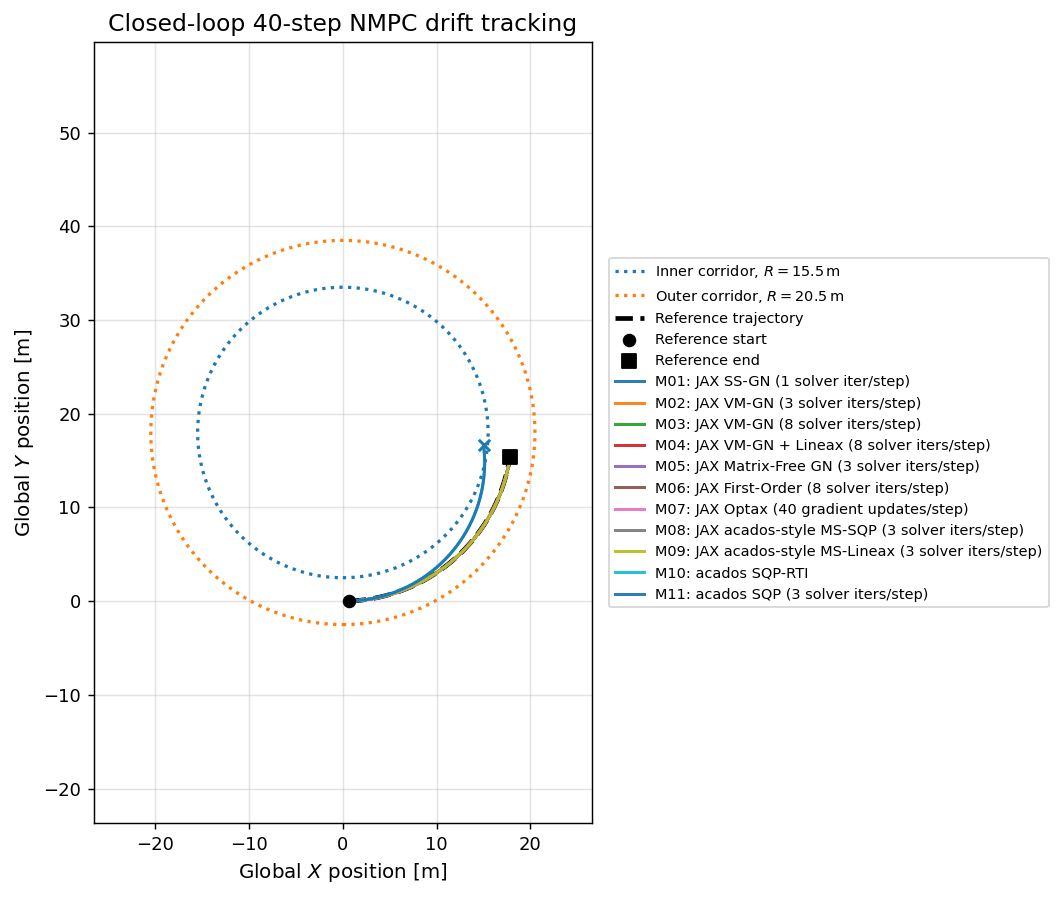

,plot_id,method
0,M01,JAX SS-GN (1 solver iter/step)
1,M02,JAX VM-GN (3 solver iters/step)
2,M03,JAX VM-GN (8 solver iters/step)
3,M04,JAX VM-GN + Lineax (8 solver iters/step)
4,M05,JAX Matrix-Free GN (3 solver iters/step)
5,M06,JAX First-Order (8 solver iters/step)
6,M07,JAX Optax (40 gradient updates/step)
7,M08,JAX acados-style MS-SQP (3 solver iters/step)
8,M09,JAX acados-style MS-Lineax (3 solver iters/step)
9,M10,acados SQP-RTI


In [80]:

# Cell 19 :

method_order = list(ALL_LOGS.keys())
method_id_map = {name: f"M{i:02d}" for i, name in enumerate(method_order, start=1)}

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": FIG_DPI,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 8,
})

fig, ax = plt.subplots(figsize=(8.2, 7.0))

R = DRIFT["turn_radius_m"]
INNER_R = R - DRIFT_CORRIDOR_HALF_WIDTH_M
OUTER_R = R + DRIFT_CORRIDOR_HALF_WIDTH_M

theta_full = np.linspace(0.0, 2.0 * np.pi, 900)
inner_x = INNER_R * np.sin(theta_full)
inner_y = R - INNER_R * np.cos(theta_full)
outer_x = OUTER_R * np.sin(theta_full)
outer_y = R - OUTER_R * np.cos(theta_full)

ax.plot(inner_x, inner_y, linestyle=":", linewidth=1.8, color="tab:blue", label=fr"Inner corridor, $R={INNER_R:.1f}\,$m")
ax.plot(outer_x, outer_y, linestyle=":", linewidth=1.8, color="tab:orange", label=fr"Outer corridor, $R={OUTER_R:.1f}\,$m")
ax.plot(XREF_40[:, 0], XREF_40[:, 1], "k--", linewidth=2.6, label="Reference trajectory")
ax.scatter(XREF_40[0, 0], XREF_40[0, 1], s=42, color="black", marker="o", zorder=5, label="Reference start")
ax.scatter(XREF_40[-1, 0], XREF_40[-1, 1], s=54, color="black", marker="s", zorder=5, label="Reference end")

for name, log in ALL_LOGS.items():
    X = log["state"]
    method_id = method_id_map[name]
    ax.plot(X[:, 0], X[:, 1], linewidth=1.65, alpha=0.95, label=f"{method_id}: {name}")
    ax.scatter(X[-1, 0], X[-1, 1], s=38, marker="x", zorder=4)

ax.set_xlabel(r"Global $X$ position [m]")
ax.set_ylabel(r"Global $Y$ position [m]")
ax.set_title("Closed-loop 40-step NMPC drift tracking")
ax.axis("equal")

# Place legend outside so the trajectory remains readable.
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True, ncol=1)
fig.tight_layout()
fig.savefig("figure_trajectory_publication_clean.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

method_id_table = pd.DataFrame({"plot_id": list(method_id_map.values()), "method": list(method_id_map.keys())})
display(method_id_table)
method_id_table.to_csv("plot_method_id_table.csv", index=False)

Block 20 generates the time-series figures from the closed-loop benchmark stored in `ALL_LOGS`. The helper function `_label(name)` maps long solver names to compact method IDs through `method_id_map`. The block first plots per-step Cartesian tracking error `position_error_m` for every method and saves the result as `figure_position_error_publication.png`, providing a direct view of how closely each controller tracks the reference trajectory over the 40 NMPC steps.

It then plots radial error `radial_error_m` against the circular drift corridor bounds \(\pm \text{DRIFT\_CORRIDOR\_HALF\_WIDTH\_M}\), saving `figure_radial_error_publication.png`. This figure is more drift-specific than the Cartesian error plot because it shows whether the vehicle remains inside the admissible circular corridor. The next plot visualizes sideslip tracking by comparing each method’s logged `beta` against the selected equilibrium sideslip `DRIFT["sideslip_rad"]` and the envelope defined by `BETA_BAND_RAD`; this is saved as `figure_sideslip_tracking_publication.png` and is essential because sustained sideslip is what distinguishes drifting from ordinary path following. The yaw-rate plot similarly compares logged `yaw_rate` against the reference yaw rate `DRIFT["yaw_rate_rad_s"]` and the allowed band defined by `YAW_RATE_BAND_FRAC`, then saves `figure_yaw_rate_tracking_publication.png`. Finally, the block plots per-step online solve time `solve_time_ms` for all methods and saves `figure_solve_time_publication.png`, enabling visual comparison of computational latency across JAX condensed, JAX multiple-shooting, and acados-style methods.


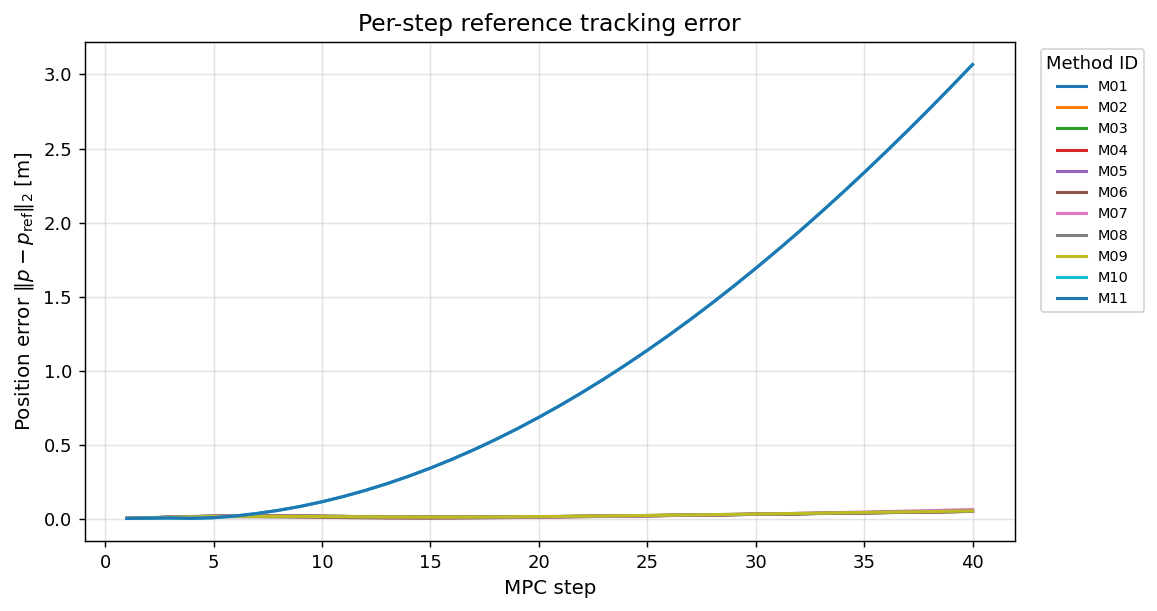

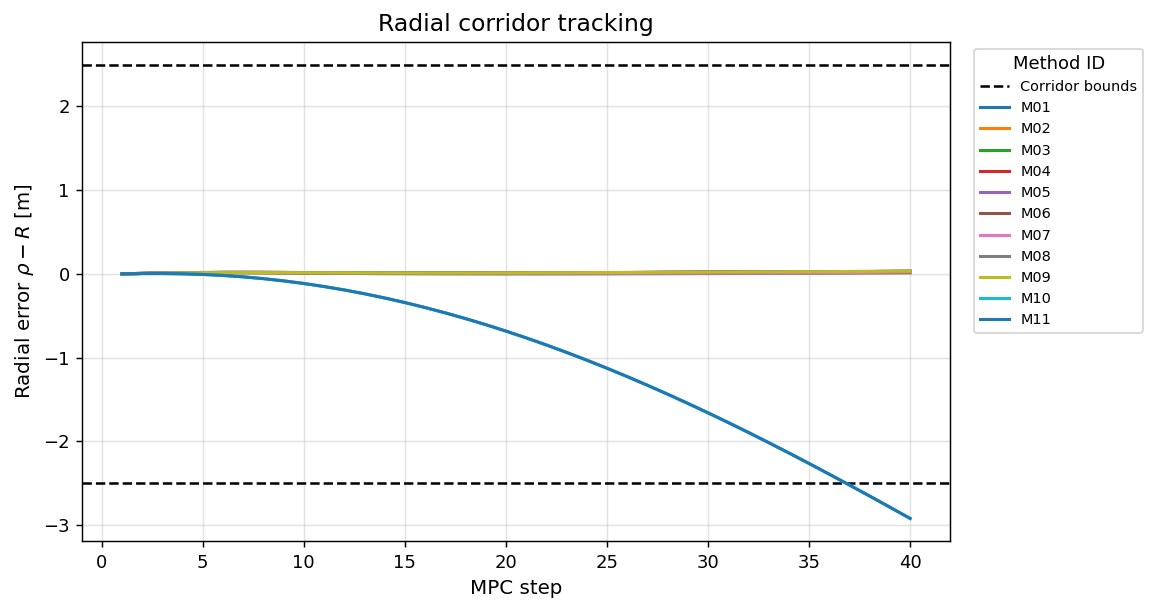

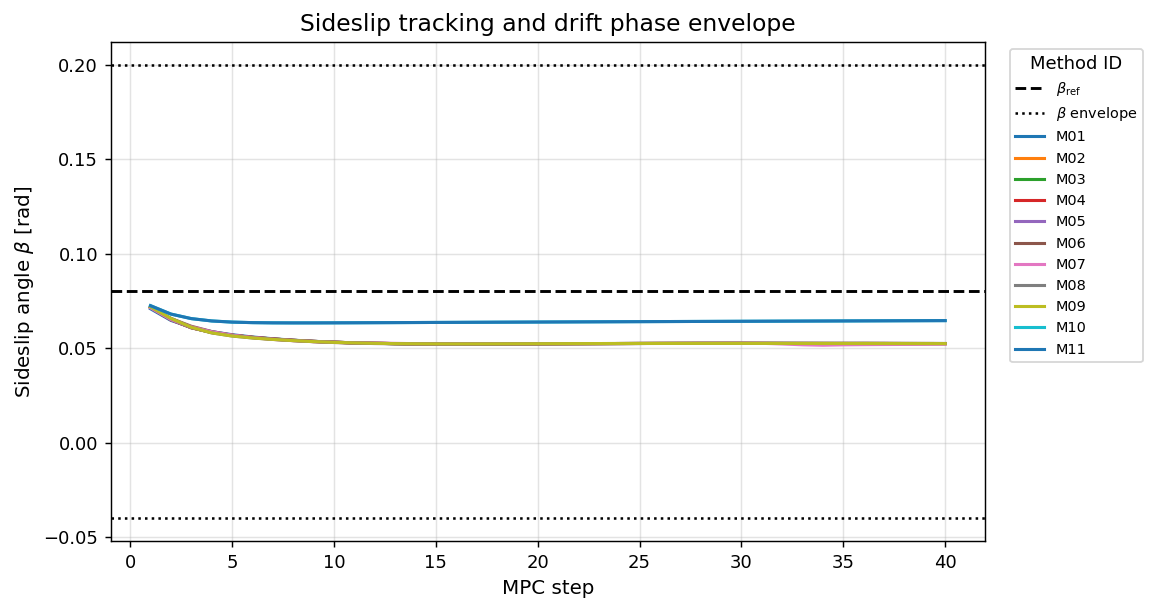

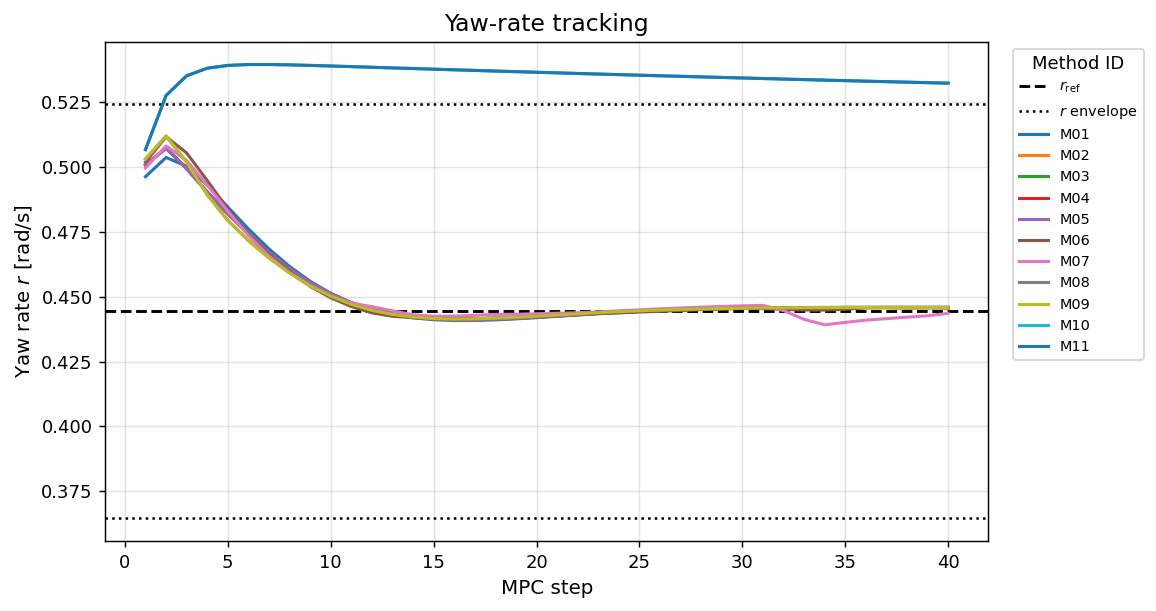

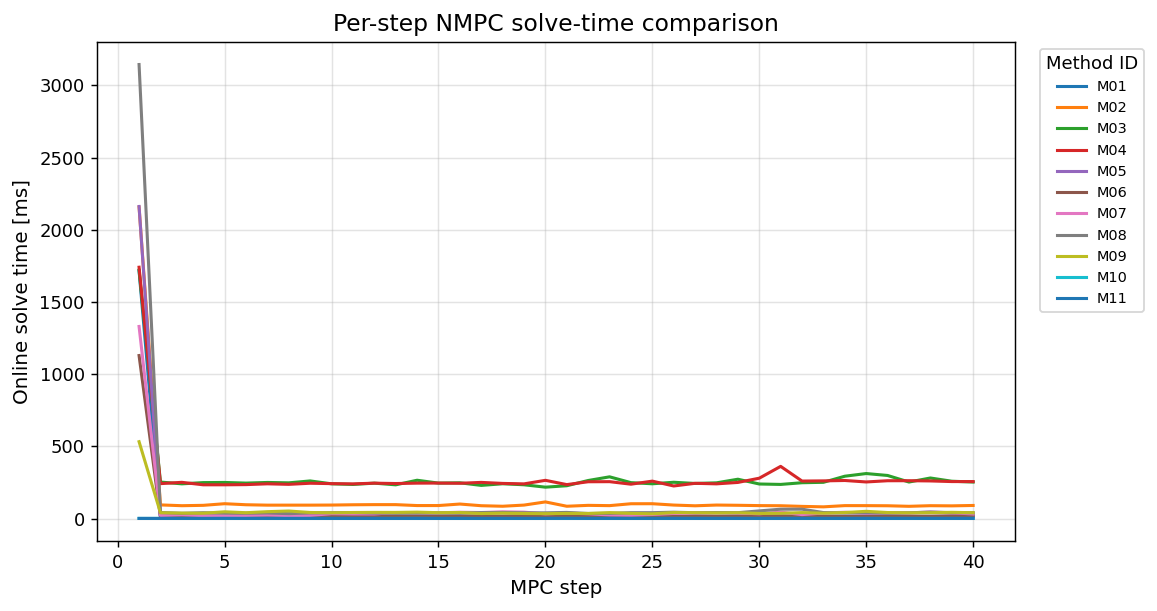

In [81]:
# 
# Cell 20 


def _label(name):
    return method_id_map.get(name, name)

# Position error
fig, ax = plt.subplots(figsize=(9.0, 4.8))
for name, log in ALL_LOGS.items():
    df = log["df"]
    ax.plot(df["step"], df["position_error_m"], linewidth=1.7, label=_label(name))
ax.set_xlabel("MPC step")
ax.set_ylabel(r"Position error $\|p-p_{\mathrm{ref}}\|_2$ [m]")
ax.set_title("Per-step reference tracking error")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), title="Method ID")
fig.tight_layout()
fig.savefig("figure_position_error_publication.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

# Radial error
fig, ax = plt.subplots(figsize=(9.0, 4.8))
ax.axhline(DRIFT_CORRIDOR_HALF_WIDTH_M, linestyle="--", color="black", linewidth=1.4, label="Corridor bounds")
ax.axhline(-DRIFT_CORRIDOR_HALF_WIDTH_M, linestyle="--", color="black", linewidth=1.4)
for name, log in ALL_LOGS.items():
    df = log["df"]
    ax.plot(df["step"], df["radial_error_m"], linewidth=1.7, label=_label(name))
ax.set_xlabel("MPC step")
ax.set_ylabel(r"Radial error $\rho-R$ [m]")
ax.set_title("Radial corridor tracking")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), title="Method ID")
fig.tight_layout()
fig.savefig("figure_radial_error_publication.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

# Sideslip tracking with both lower and upper bounds clearly labeled
fig, ax = plt.subplots(figsize=(9.0, 4.8))
beta_ref = DRIFT["sideslip_rad"]
ax.axhline(beta_ref, linestyle="--", color="black", linewidth=1.6, label=r"$\beta_{\mathrm{ref}}$")
ax.axhline(beta_ref + BETA_BAND_RAD, linestyle=":", color="black", linewidth=1.4, label=r"$\beta$ envelope")
ax.axhline(beta_ref - BETA_BAND_RAD, linestyle=":", color="black", linewidth=1.4)
for name, log in ALL_LOGS.items():
    df = log["df"]
    ax.plot(df["step"], df["beta"], linewidth=1.7, label=_label(name))
ax.set_xlabel("MPC step")
ax.set_ylabel(r"Sideslip angle $\beta$ [rad]")
ax.set_title("Sideslip tracking and drift phase envelope")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), title="Method ID")
fig.tight_layout()
fig.savefig("figure_sideslip_tracking_publication.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

# Yaw-rate tracking with envelope
fig, ax = plt.subplots(figsize=(9.0, 4.8))
r_ref = DRIFT["yaw_rate_rad_s"]
yaw_band_rad_s = abs(r_ref) * YAW_RATE_BAND_FRAC
ax.axhline(r_ref, linestyle="--", color="black", linewidth=1.6, label=r"$r_{\mathrm{ref}}$")
ax.axhline(r_ref + yaw_band_rad_s, linestyle=":", color="black", linewidth=1.4, label=r"$r$ envelope")
ax.axhline(r_ref - yaw_band_rad_s, linestyle=":", color="black", linewidth=1.4)
for name, log in ALL_LOGS.items():
    df = log["df"]
    ax.plot(df["step"], df["yaw_rate"], linewidth=1.7, label=_label(name))
ax.set_xlabel("MPC step")
ax.set_ylabel(r"Yaw rate $r$ [rad/s]")
ax.set_title("Yaw-rate tracking")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), title="Method ID")
fig.tight_layout()
fig.savefig("figure_yaw_rate_tracking_publication.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

# Solve time
fig, ax = plt.subplots(figsize=(9.0, 4.8))
for name, log in ALL_LOGS.items():
    df = log["df"]
    ax.plot(df["step"], df["solve_time_ms"], linewidth=1.7, label=_label(name))
ax.set_xlabel("MPC step")
ax.set_ylabel("Online solve time [ms]")
ax.set_title("Per-step NMPC solve-time comparison")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), title="Method ID")
fig.tight_layout()
fig.savefig("figure_solve_time_publication.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

Cell 21 converts the benchmark statistics into  figures. It first selects timing components such as `candidate_generation_time_ms`, `rollout_residual_time_ms`, `jacobian_time_ms`, `jvp_vjp_time_ms`, `linear_solve_time_ms`, `solver_only_time_ms`, and acados-specific overhead terms, then builds `plot_df` from `timing_decomposition_df`. The stacked-bar plot shows how each method’s mean solve time is distributed across candidate generation, autodiff, linear algebra, solver execution, and result retrieval, and saves the figure as `figure_timing_decomposition_publication.png`. This is useful because total runtime alone does not reveal why one solver is faster or slower.

The block then constructs `pareto_df` from `summary_df` and plots mean solve time against mean position error. It computes a lower-left Pareto frontier by sorting methods by solve time and retaining only methods that improve the best observed tracking error, then annotates each solver with its compact method ID and saves `figure_time_quality_pareto_publication.png`. This provides a concise comparison of the speed–accuracy trade-off among JAX condensed solvers, JAX multiple-shooting solvers, and optional acados baselines. The block also writes `publication_summary_table.csv`, which combines the compact plot ID with the full numerical summary.

Finally, Cell 21 builds a solver-behavior embedding using performance features such as mean and 95th-percentile solve time, mean and maximum position error, radial error, corridor violation, sideslip error, and yaw-rate error. If `UMAP_AVAILABLE` is true and enough methods exist, it uses `umap.UMAP` to form a two-dimensional nonlinear embedding; otherwise, it applies a deterministic SVD-based PCA fallback. The resulting plot, saved as `figure_solver_behavior_manifold_publication.png`, visually clusters solvers with similar timing and tracking behavior, and `solver_behavior_embedding.csv` stores the embedding coordinates.

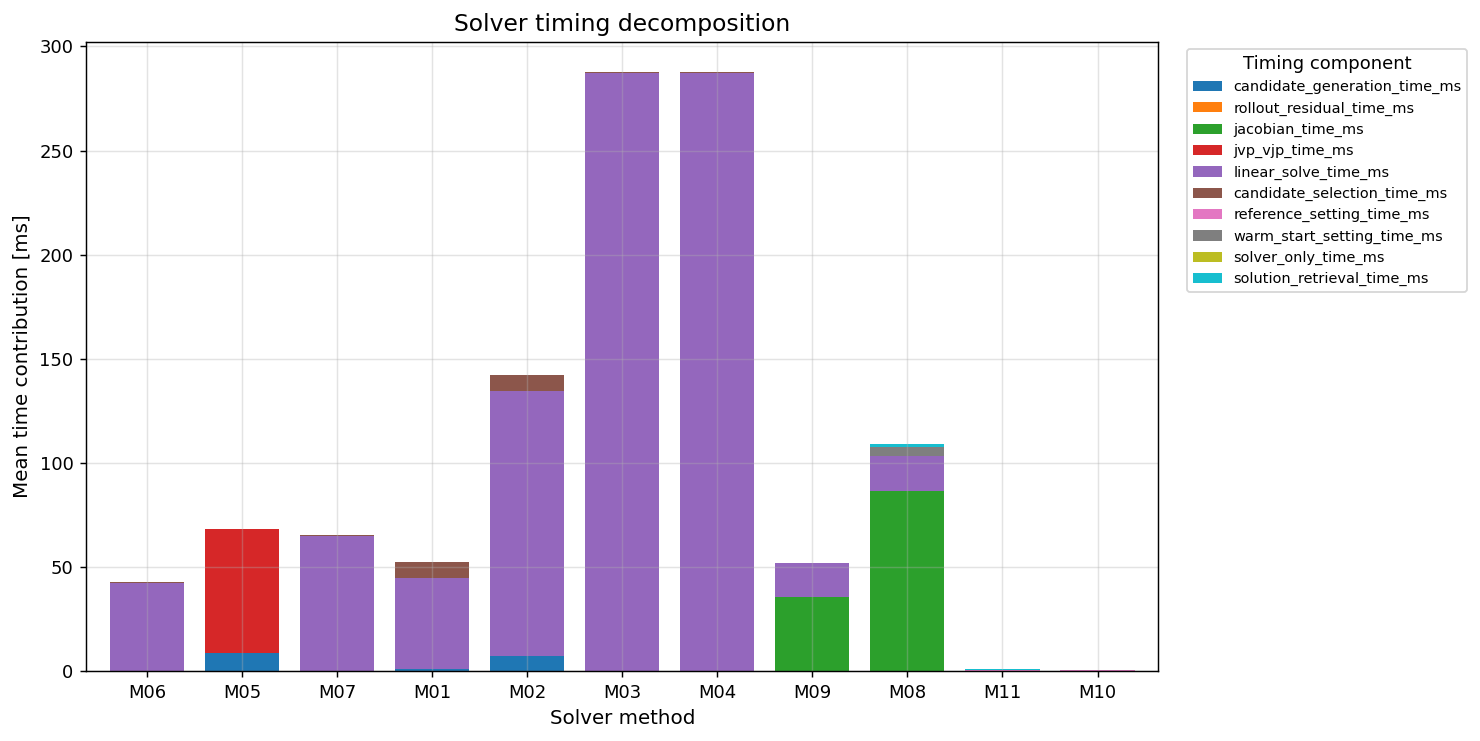

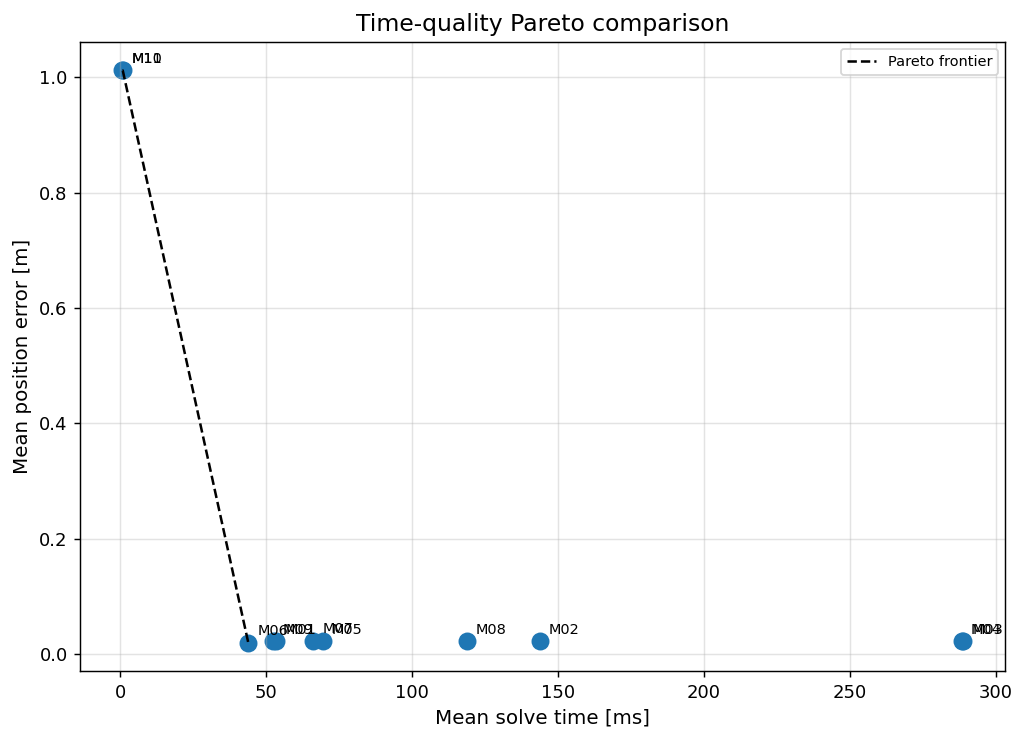

,plot_id,method,mean_solve_time_ms,p95_solve_time_ms,std_solve_time_ms,mean_position_error_m,max_position_error_m,mean_abs_radial_error_m,max_corridor_violation_m,mean_abs_beta_error_rad,mean_abs_yaw_error_rad_s,success_fraction
0,M06,JAX First-Order (8 solver iters/step),43.79811,18.90490,175.98328,0.01963,0.05310,0.00596,0.00000,0.02600,0.00990,1.0
1,M01,JAX SS-GN (1 solver iter/step),53.46737,13.22111,269.69019,0.02198,0.04901,0.01677,0.00000,0.02603,0.00995,1.0
2,M05,JAX Matrix-Free GN (3 solver iters/step),69.26162,18.94278,339.30530,0.02209,0.04975,0.01683,0.00000,0.02604,0.00980,1.0
3,M02,JAX VM-GN (3 solver iters/step),143.73028,103.20318,326.61241,0.02209,0.04977,0.01683,0.00000,0.02604,0.00980,1.0
4,M04,JAX VM-GN + Lineax (8 solver iters/step),288.33620,283.39711,236.44791,0.02211,0.04985,0.01686,0.00000,0.02604,0.00979,1.0
5,M03,JAX VM-GN (8 solver iters/step),288.79247,298.91326,232.92466,0.02211,0.04985,0.01686,0.00000,0.02604,0.00979,1.0
6,M08,JAX acados-style MS-SQP (3 solver iters/step),118.60004,64.56140,490.78057,0.02256,0.05246,0.01693,0.00000,0.02605,0.00964,1.0
7,M09,JAX acados-style MS-Lineax (3 solver iters/step),52.31898,49.93316,77.93579,0.02256,0.05246,0.01693,0.00000,0.02605,0.00964,1.0
8,M07,JAX Optax (40 gradient updates/step),66.12503,45.31417,205.18802,0.02287,0.06181,0.01123,0.00000,0.02613,0.00994,1.0
9,M10,acados SQP-RTI,0.66819,0.75412,0.06802,1.01196,3.06727,0.98667,0.41935,0.01567,0.09079,0.9


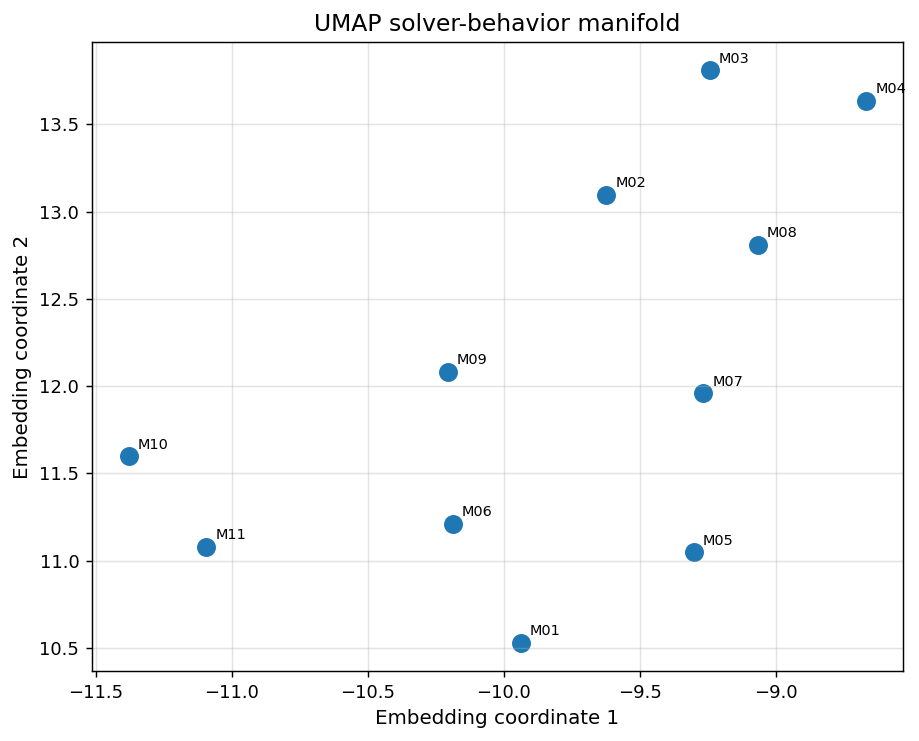

,plot_id,method,embedding_1,embedding_2
0,M06,JAX First-Order (8 solver iters/step),-10.18671,11.21293
1,M01,JAX SS-GN (1 solver iter/step),-9.93750,10.53117
2,M05,JAX Matrix-Free GN (3 solver iters/step),-9.30116,11.04715
3,M02,JAX VM-GN (3 solver iters/step),-9.62234,13.09704
4,M04,JAX VM-GN + Lineax (8 solver iters/step),-8.66706,13.63676
5,M03,JAX VM-GN (8 solver iters/step),-9.24231,13.80904
6,M08,JAX acados-style MS-SQP (3 solver iters/step),-9.06533,12.81168
7,M09,JAX acados-style MS-Lineax (3 solver iters/step),-10.20548,12.08301
8,M07,JAX Optax (40 gradient updates/step),-9.26540,11.96153
9,M10,acados SQP-RTI,-11.37782,11.60064


In [82]:
# 
# Cell 21

plot_cols = [
    "candidate_generation_time_ms",
    "rollout_residual_time_ms",
    "jacobian_time_ms",
    "jvp_vjp_time_ms",
    "linear_solve_time_ms",
    "candidate_selection_time_ms",
    "reference_setting_time_ms",
    "warm_start_setting_time_ms",
    "solver_only_time_ms",
    "solution_retrieval_time_ms",
]

plot_df = timing_decomposition_df.set_index("method").copy()
available = [c for c in plot_cols if c in plot_df.columns]
plot_df[available] = plot_df[available].apply(pd.to_numeric, errors="coerce").fillna(0.0)

fig, ax = plt.subplots(figsize=(11.5, 5.8))
plot_df[available].plot(kind="bar", stacked=True, ax=ax, width=0.78)
ax.set_ylabel("Mean time contribution [ms]")
ax.set_xlabel("Solver method")
ax.set_title("Solver timing decomposition")
ax.grid(True, axis="y", alpha=0.35)
ax.set_xticklabels([method_id_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()], rotation=0)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), title="Timing component")
fig.tight_layout()
fig.savefig("figure_timing_decomposition_publication.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

# Pareto plot with compact IDs to avoid unreadable text overlap.
pareto_df = summary_df.copy()
for col in ["mean_solve_time_ms", "mean_position_error_m"]:
    pareto_df[col] = pd.to_numeric(pareto_df[col], errors="coerce")
pareto_df = pareto_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["mean_solve_time_ms", "mean_position_error_m"])

fig, ax = plt.subplots(figsize=(8.0, 5.8))
ax.scatter(pareto_df["mean_solve_time_ms"], pareto_df["mean_position_error_m"], s=80)

# Compute lower-left Pareto frontier: sort by time and keep decreasing error.
frontier = []
best_err = np.inf
for _, row in pareto_df.sort_values("mean_solve_time_ms").iterrows():
    if row["mean_position_error_m"] <= best_err:
        frontier.append(row)
        best_err = row["mean_position_error_m"]

if len(frontier) > 0:
    frontier_df = pd.DataFrame(frontier)
    ax.plot(frontier_df["mean_solve_time_ms"], frontier_df["mean_position_error_m"], "k--", linewidth=1.4, label="Pareto frontier")

for _, row in pareto_df.iterrows():
    mid = method_id_map.get(row["method"], row["method"])
    ax.annotate(mid, (row["mean_solve_time_ms"], row["mean_position_error_m"]), xytext=(5, 4), textcoords="offset points", fontsize=8)

ax.set_xlabel("Mean solve time [ms]")
ax.set_ylabel("Mean position error [m]")
ax.set_title("Time-quality Pareto comparison")
ax.grid(True, alpha=0.35)
if len(frontier) > 0:
    ax.legend(loc="best")
fig.tight_layout()
fig.savefig("figure_time_quality_pareto_publication.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

# Publication summary table with compact IDs.
publication_summary_df = summary_df.copy()
publication_summary_df.insert(0, "plot_id", publication_summary_df["method"].map(method_id_map))
publication_summary_df.to_csv("publication_summary_table.csv", index=False)
display(publication_summary_df.round(5))

# Optional UMAP solver-behavior manifold. If UMAP is not available, use deterministic PCA fallback.
feature_cols = [
    "mean_solve_time_ms",
    "p95_solve_time_ms",
    "mean_position_error_m",
    "max_position_error_m",
    "mean_abs_radial_error_m",
    "max_corridor_violation_m",
    "mean_abs_beta_error_rad",
    "mean_abs_yaw_error_rad_s",
]
embedding_source = publication_summary_df[["plot_id", "method"] + feature_cols].copy()
for col in feature_cols:
    embedding_source[col] = pd.to_numeric(embedding_source[col], errors="coerce")
X_features = embedding_source[feature_cols].replace([np.inf, -np.inf], np.nan)
X_features = X_features.fillna(X_features.median(numeric_only=True)).fillna(0.0).to_numpy(dtype=float)

# Standardize safely.
mu_feat = X_features.mean(axis=0, keepdims=True)
sig_feat = X_features.std(axis=0, keepdims=True)
sig_feat[sig_feat < 1e-12] = 1.0
Xz = (X_features - mu_feat) / sig_feat

if Xz.shape[0] >= 4 and UMAP_AVAILABLE:
    reducer = umap.UMAP(n_components=2, n_neighbors=min(5, Xz.shape[0]-1), min_dist=0.20, random_state=BENCHMARK_SEED)
    embedding = reducer.fit_transform(Xz)
    manifold_title = "UMAP solver-behavior manifold"
else:
    # Deterministic PCA fallback using SVD; no extra package required.
    U_svd, S_svd, Vt_svd = np.linalg.svd(Xz - Xz.mean(axis=0, keepdims=True), full_matrices=False)
    if Vt_svd.shape[0] >= 2:
        embedding = (Xz - Xz.mean(axis=0, keepdims=True)) @ Vt_svd[:2].T
    else:
        embedding = np.column_stack([Xz[:, 0], np.zeros(Xz.shape[0])])
    manifold_title = "PCA fallback solver-behavior manifold"

fig, ax = plt.subplots(figsize=(7.2, 5.8))
ax.scatter(embedding[:, 0], embedding[:, 1], s=90)
for i, row in embedding_source.iterrows():
    ax.annotate(row["plot_id"], (embedding[i, 0], embedding[i, 1]), xytext=(5, 4), textcoords="offset points", fontsize=8)
ax.set_xlabel("Embedding coordinate 1")
ax.set_ylabel("Embedding coordinate 2")
ax.set_title(manifold_title)
ax.grid(True, alpha=0.35)
fig.tight_layout()
fig.savefig("figure_solver_behavior_manifold_publication.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

embedding_df = pd.DataFrame({
    "plot_id": embedding_source["plot_id"],
    "method": embedding_source["method"],
    "embedding_1": embedding[:, 0],
    "embedding_2": embedding[:, 1],
})
embedding_df.to_csv("solver_behavior_embedding.csv", index=False)
display(embedding_df.round(5))


Cell 22 adds a compiled closed-loop execution path and a final benchmark summary. The function `compiled_closed_loop_scan(x_init, U_init, mu_series, key, steps=40, method_id=METHOD_VM_DENSE_GN, iteration_count=3, candidate_count=N_CANDIDATES)` runs the entire receding-horizon control loop inside one JAX-compiled `lax.scan`. At each step, it splits the random key, builds the horizon reference with `reference_horizon_jax(step)`, extracts the friction horizon using `friction_horizon_jax(mu_series, step)`, solves the NMPC problem through `fused_condensed_solver_switch(...)`, applies the first optimized control `u0`, propagates the vehicle with `rk4_step(...)`, shifts the solution sequence forward as the next warm start, and stores the closed-loop state, control, and objective. This differs from the earlier Python-loop benchmark because the complete closed-loop rollout is compiled as one static JAX program, which can reduce Python overhead and better represent accelerator-oriented deployment.

The function `build_pmap_runner()` optionally constructs a multi-device version of this compiled closed-loop scan. If fewer than two JAX devices are available, it returns `None` and prints that `pmap` is unavailable. If multiple devices exist, it wraps `compiled_closed_loop_scan` with `jax.pmap`, allowing independent closed-loop simulations to run in parallel across devices. This is useful for batched robustness studies, such as testing different friction profiles, seeds, or initial conditions simultaneously. However, it is not a substitute for embedded real-time deployment: `pmap` is mainly relevant for workstation/GPU/TPU parallel experiments, whereas acados remains more suitable for deterministic C-code deployment on embedded CPUs.

The final lines display the best methods ranked by `mean_position_error_m` and the fastest methods ranked by `mean_solve_time_ms`, then report that the notebook has generated the CSV tables and figures. This block therefore closes the workflow by demonstrating an accelerator-compatible closed-loop execution path and summarizing the solver benchmark. Its main limitation is that the `pmap` runner is only constructed, not used for a full reported robustness experiment as it is run in one laptop/cpu; therefore, multi-device scalability is supported by the code structure but not yet demonstrated quantitatively.

In [83]:
# Cell 22

@partial(
    jax.jit,
    static_argnames=("steps", "method_id", "iteration_count", "candidate_count"),
)
def compiled_closed_loop_scan(x_init, U_init, mu_series, key, steps=40, method_id=METHOD_VM_DENSE_GN, iteration_count=3, candidate_count=N_CANDIDATES):
    def body(carry, step):
        x, U_prev, key = carry
        key, subkey = jax.random.split(key)
        X_ref, U_ref = reference_horizon_jax(step)
        mu_seq = friction_horizon_jax(mu_series, step)
        U_sol, idx, obj = fused_condensed_solver_switch(
            method_id, x, U_prev, X_ref, U_ref, mu_seq, step, subkey,
            iteration_count=iteration_count,
            candidate_count=candidate_count,
            use_checkpoint=True,
        )
        u0 = U_sol[0]
        x_next = rk4_step(x, u0, mu_series[step])
        U_next = jnp.vstack([U_sol[1:], U_sol[-1:]])
        out = {"state": x_next, "control": u0, "objective": obj}
        return (x_next, U_next, key), out

    (_, _, _), outputs = jax.lax.scan(
        body,
        (x_init, U_init, key),
        jnp.arange(steps),
    )
    return outputs

def build_pmap_runner():
    if jax.device_count() < 2:
        print("pmap runner not built: fewer than two JAX devices.")
        return None
    return jax.pmap(compiled_closed_loop_scan, in_axes=(0, 0, 0, 0, None, None, None, None))

PMAP_RUNNER = build_pmap_runner()

print("Best methods by position error:")
display(summary_df.sort_values("mean_position_error_m").head(5))

print("Fastest methods:")
display(summary_df.sort_values("mean_solve_time_ms").head(5))

print("Notebook completed. Generated CSVs and figures are saved in the working directory.")

pmap runner not built: fewer than two JAX devices.
Best methods by position error:


,method,mean_solve_time_ms,p95_solve_time_ms,std_solve_time_ms,mean_position_error_m,max_position_error_m,mean_abs_radial_error_m,max_corridor_violation_m,mean_abs_beta_error_rad,mean_abs_yaw_error_rad_s,success_fraction
0,JAX First-Order (8 solver iters/step),43.798105,18.904903,175.983282,0.019630,0.053098,0.005963,0.0,0.025999,0.009898,1.0
1,JAX SS-GN (1 solver iter/step),53.467373,13.221112,269.690185,0.021983,0.049007,0.016774,0.0,0.026034,0.009948,1.0
2,JAX Matrix-Free GN (3 solver iters/step),69.261616,18.942780,339.305303,0.022089,0.049755,0.016831,0.0,0.026035,0.009802,1.0
3,JAX VM-GN (3 solver iters/step),143.730285,103.203182,326.612409,0.022091,0.049769,0.016835,0.0,0.026036,0.009801,1.0
4,JAX VM-GN + Lineax (8 solver iters/step),288.336205,283.397107,236.447910,0.022106,0.049854,0.016860,0.0,0.026037,0.009793,1.0


Fastest methods:


,method,mean_solve_time_ms,p95_solve_time_ms,std_solve_time_ms,mean_position_error_m,max_position_error_m,mean_abs_radial_error_m,max_corridor_violation_m,mean_abs_beta_error_rad,mean_abs_yaw_error_rad_s,success_fraction
9,acados SQP-RTI,0.668187,0.754118,0.068025,1.011958,3.067269,0.986665,0.419355,0.015669,0.090795,0.9
10,acados SQP (3 solver iters/step),0.789716,1.045345,0.114339,1.011958,3.067269,0.986665,0.419355,0.015669,0.090795,0.9
0,JAX First-Order (8 solver iters/step),43.798105,18.904903,175.983282,0.019630,0.053098,0.005963,0.000000,0.025999,0.009898,1.0
7,JAX acados-style MS-Lineax (3 solver iters/step),52.318982,49.933155,77.935789,0.022561,0.052455,0.016927,0.000000,0.026046,0.009641,1.0
1,JAX SS-GN (1 solver iter/step),53.467373,13.221112,269.690185,0.021983,0.049007,0.016774,0.000000,0.026034,0.009948,1.0


Notebook completed. Generated CSVs and figures are saved in the working directory.




Cell 23 generates a phase-plane diagnostic for the closed-loop drift state using sideslip angle \(\beta\) and yaw rate \(r\). It first builds `phase_df` by collecting the logged closed-loop data from `ALL_LOGS`, attaching each method name and compact `plot_id`, and then defines the reference drift operating point using `beta_ref = DRIFT["sideslip_rad"]` and `r_ref = DRIFT["yaw_rate_rad_s"]`. The yaw-rate tolerance is computed as `yaw_band_rad_s = abs(r_ref) * YAW_RATE_BAND_FRAC`, while the sideslip tolerance is given by `BETA_BAND_RAD`.

The plotting section draws the desired drift equilibrium as dashed reference lines and highlights the acceptable drift envelope using `axvspan(...)` for the sideslip band and `axhspan(...)` for the yaw-rate band. For each controller, the logged trajectory `df["beta"]` versus `df["yaw_rate"]` is plotted, with the initial point marked by a circle and the final point marked by a cross. This is an important diagnostic because a path-tracking plot can look successful even when the vehicle is not actually drifting; the \(\beta\)–\(r\) plane directly verifies whether the closed-loop motion approaches and remains near the intended sideslip–yaw-rate drift equilibrium.

The block then computes `phase_summary`, which reports each method’s mean absolute sideslip error, maximum sideslip-envelope violation, mean absolute yaw-rate error, and maximum yaw-rate-envelope violation.

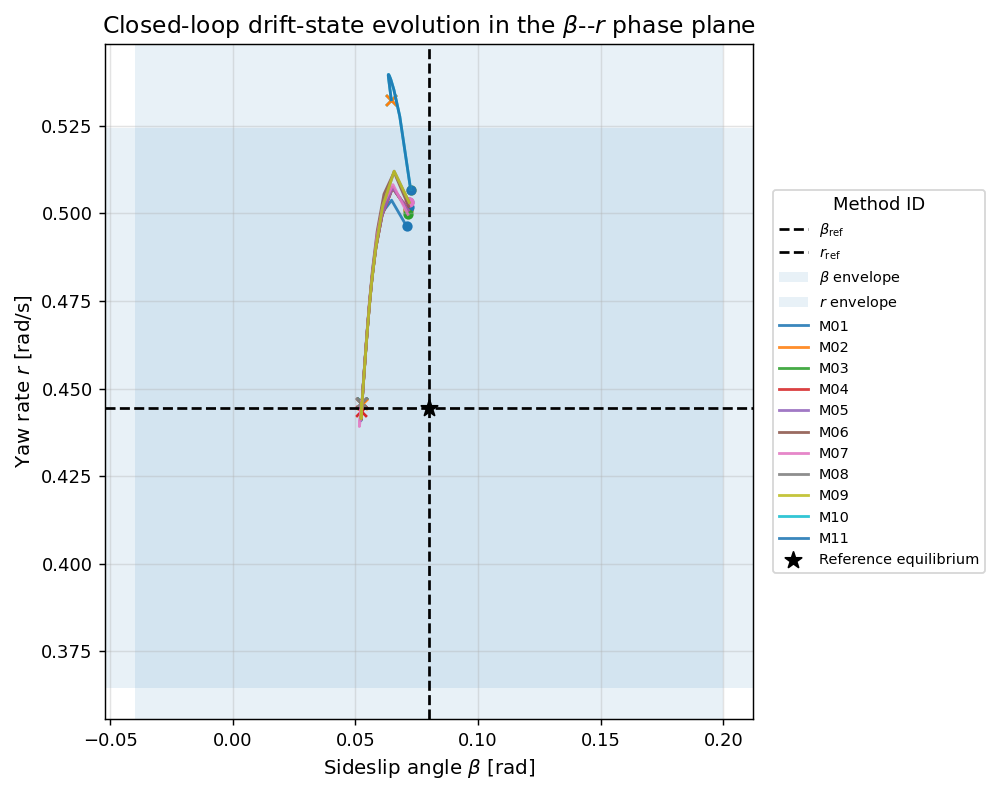

,plot_id,method,mean_beta_abs_error_rad,max_beta_envelope_violation_rad,mean_yaw_abs_error_rad_s,max_yaw_envelope_violation_rad_s
0,M01,JAX SS-GN (1 solver iter/step),0.02603,0.0,0.00995,0.0000
1,M02,JAX VM-GN (3 solver iters/step),0.02604,0.0,0.00980,0.0000
2,M03,JAX VM-GN (8 solver iters/step),0.02604,0.0,0.00979,0.0000
3,M04,JAX VM-GN + Lineax (8 solver iters/step),0.02604,0.0,0.00979,0.0000
4,M05,JAX Matrix-Free GN (3 solver iters/step),0.02604,0.0,0.00980,0.0000
5,M06,JAX First-Order (8 solver iters/step),0.02600,0.0,0.00990,0.0000
6,M07,JAX Optax (40 gradient updates/step),0.02613,0.0,0.00994,0.0000
7,M08,JAX acados-style MS-SQP (3 solver iters/step),0.02605,0.0,0.00964,0.0000
8,M09,JAX acados-style MS-Lineax (3 solver iters/step),0.02605,0.0,0.00964,0.0000
9,M10,acados SQP-RTI,0.01567,0.0,0.09079,0.0152


In [84]:

#
# Cell 23: 

# The beta-yaw-rate phase plane is the most direct diagnostic for drifting.
# A path-tracking plot can look good even when the vehicle is not drifting;
# this plot verifies whether the closed-loop response approaches the desired
# sideslip/yaw-rate operating point.

phase_rows = []
for method_name, log in ALL_LOGS.items():
    df = log["df"].copy()
    df["method"] = method_name
    df["plot_id"] = method_id_map.get(method_name, method_name)
    phase_rows.append(df)
phase_df = pd.concat(phase_rows, ignore_index=True)

beta_ref = DRIFT["sideslip_rad"]
r_ref = DRIFT["yaw_rate_rad_s"]
yaw_band_rad_s = abs(r_ref) * YAW_RATE_BAND_FRAC

fig, ax = plt.subplots(figsize=(7.8, 6.2))

# Drift envelope rectangle.
ax.axvline(beta_ref, color="black", linestyle="--", linewidth=1.5, label=r"$\beta_{\mathrm{ref}}$")
ax.axhline(r_ref, color="black", linestyle="--", linewidth=1.5, label=r"$r_{\mathrm{ref}}$")
ax.axvspan(beta_ref - BETA_BAND_RAD, beta_ref + BETA_BAND_RAD, alpha=0.10, label=r"$\beta$ envelope")
ax.axhspan(r_ref - yaw_band_rad_s, r_ref + yaw_band_rad_s, alpha=0.10, label=r"$r$ envelope")

for method_name, log in ALL_LOGS.items():
    df = log["df"]
    pid = method_id_map.get(method_name, method_name)
    ax.plot(df["beta"], df["yaw_rate"], linewidth=1.55, alpha=0.88, label=pid)
    ax.scatter(df["beta"].iloc[0], df["yaw_rate"].iloc[0], s=22, marker="o")
    ax.scatter(df["beta"].iloc[-1], df["yaw_rate"].iloc[-1], s=36, marker="x")

ax.scatter([beta_ref], [r_ref], s=90, marker="*", color="black", zorder=5, label="Reference equilibrium")
ax.set_xlabel(r"Sideslip angle $\beta$ [rad]")
ax.set_ylabel(r"Yaw rate $r$ [rad/s]")
ax.set_title(r"Closed-loop drift-state evolution in the $\beta$--$r$ phase plane")
ax.grid(True, alpha=0.35)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="Method ID")
fig.tight_layout()
fig.savefig("figure_phase_plane_beta_yaw_publication.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

# Quantitative phase-envelope summary.
phase_summary = (
    phase_df.assign(
        beta_envelope_violation_rad=lambda d: np.maximum(0.0, np.abs(d["beta"] - beta_ref) - BETA_BAND_RAD),
        yaw_envelope_violation_rad_s=lambda d: np.maximum(0.0, np.abs(d["yaw_rate"] - r_ref) - yaw_band_rad_s),
    )
    .groupby(["plot_id", "method"])
    .agg(
        mean_beta_abs_error_rad=("beta_error_rad", lambda x: float(np.mean(np.abs(x)))),
        max_beta_envelope_violation_rad=("beta_envelope_violation_rad", "max"),
        mean_yaw_abs_error_rad_s=("yaw_rate_error_rad_s", lambda x: float(np.mean(np.abs(x)))),
        max_yaw_envelope_violation_rad_s=("yaw_envelope_violation_rad_s", "max"),
    )
    .reset_index()
)
phase_summary.to_csv("phase_plane_envelope_summary.csv", index=False)
display(phase_summary.round(5))


Cell 24 visualizes the feasibility of the drift equilibrium selected earlier in the notebook. It starts from `eq_df`, converts candidate sideslip and steering angles into degrees, and defines `_eq_tire_usage(row)` to recompute the front and rear tire utilization for each candidate equilibrium using `tire_forces(...)`. This function reconstructs a circular-drift state from the candidate sideslip `beta`, steering angle `delta`, rear force `fxr`, drift speed, and turn radius, then computes normalized front lateral usage and rear combined usage. The resulting `front_tire_usage` and `rear_tire_usage` columns are appended to `eq_plot_df`, giving a physical interpretation of how close each candidate equilibrium is to the friction limit.

It then creates a four-panel feasibility map. The first subplot shows equilibrium residual norm versus sideslip, indicating whether the requested drift state can be approximately maintained by the model. The second subplot shows required steering angle against the steering limits `P.max_steer_rad`, revealing whether the equilibrium demands feasible steering. The third subplot shows the required rear longitudinal force against `P.min_rear_force_n` and `P.max_rear_force_n`, checking actuator feasibility. The fourth subplot compares front and rear tire utilization against the unit friction limit, showing whether the selected drift point is close to tire saturation. The figure is saved as `figure_equilibrium_feasibility_map_publication.png`, while the enriched feasibility table is saved as `equilibrium_feasibility_map_with_tire_usage.csv`.

This cell is useful because it demonstrates that the selected circular-drift reference is not arbitrary: it is chosen from a sideslip feasibility map constrained by actuator limits, model residuals, and tire utilization. However, this feasibility is only valid for the notebook’s simplified single-track model with static loads and reduced tire saturation. It should not be interpreted as proof that the same drift equilibrium would be feasible on a high-fidelity vehicle model or real vehicle without validation against combined-slip tire data, load-transfer dynamics, and experimental benchmarks.

In [ ]:
# Cell 24 

# The equilibrium map verifies that the selected reference is physically meaningful.
# It shows whether increasing desired sideslip makes the required control and residual
# infeasible under the given tire/friction/actuator limits.

eq_plot_df = eq_df.copy()
eq_plot_df["beta_deg"] = np.rad2deg(eq_plot_df["beta"])
eq_plot_df["delta_deg"] = np.rad2deg(eq_plot_df["delta"])

def _eq_tire_usage(row):
    beta = float(row["beta"])
    delta = float(row["delta"])
    fxr = float(row["fxr"])
    V = DRIFT["speed_m_s"]
    R = DRIFT["turn_radius_m"]
    x = jnp.asarray([0.0, 0.0, -beta, V*np.cos(beta), V*np.sin(beta), V/R, delta])
    u = jnp.asarray([0.0, fxr])
    fyf, fyr, fxr_j = tire_forces(x, u, P.mu_nominal)
    fyf = float(fyf)
    fyr = float(fyr)
    fxr_v = float(fxr_j)
    front = abs(fyf) / (P.mu_nominal * FZ_F)
    rear = np.sqrt(fyr**2 + fxr_v**2) / (P.mu_nominal * FZ_R)
    return pd.Series({"front_tire_usage": front, "rear_tire_usage": rear})

usage_cols = eq_plot_df.apply(_eq_tire_usage, axis=1)
eq_plot_df = pd.concat([eq_plot_df, usage_cols], axis=1)

fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.0))

axes[0, 0].plot(eq_plot_df["beta_deg"], eq_plot_df["residual_norm"], marker="o", linewidth=1.7)
axes[0, 0].axvline(np.rad2deg(DRIFT["sideslip_rad"]), color="black", linestyle="--", linewidth=1.3, label="Selected")
axes[0, 0].set_xlabel(r"Candidate sideslip $\beta$ [deg]")
axes[0, 0].set_ylabel(r"Equilibrium residual norm")
axes[0, 0].set_title("Feasibility residual")
axes[0, 0].legend()

axes[0, 1].plot(eq_plot_df["beta_deg"], eq_plot_df["delta_deg"], marker="o", linewidth=1.7)
axes[0, 1].axhline(np.rad2deg(P.max_steer_rad), color="black", linestyle=":", linewidth=1.2, label="Steering limit")
axes[0, 1].axhline(-np.rad2deg(P.max_steer_rad), color="black", linestyle=":", linewidth=1.2)
axes[0, 1].set_xlabel(r"Candidate sideslip $\beta$ [deg]")
axes[0, 1].set_ylabel(r"Equilibrium steering $\delta_{eq}$ [deg]")
axes[0, 1].set_title("Required steering")
axes[0, 1].legend()

axes[1, 0].plot(eq_plot_df["beta_deg"], eq_plot_df["fxr"], marker="o", linewidth=1.7)
axes[1, 0].axhline(P.max_rear_force_n, color="black", linestyle=":", linewidth=1.2, label="Rear-force limit")
axes[1, 0].axhline(P.min_rear_force_n, color="black", linestyle=":", linewidth=1.2)
axes[1, 0].set_xlabel(r"Candidate sideslip $\beta$ [deg]")
axes[1, 0].set_ylabel(r"Rear force $F_{x,r}$ [N]")
axes[1, 0].set_title("Required rear longitudinal force")
axes[1, 0].legend()

axes[1, 1].plot(eq_plot_df["beta_deg"], eq_plot_df["front_tire_usage"], marker="o", linewidth=1.7, label="Front")
axes[1, 1].plot(eq_plot_df["beta_deg"], eq_plot_df["rear_tire_usage"], marker="s", linewidth=1.7, label="Rear")
axes[1, 1].axhline(1.0, color="black", linestyle="--", linewidth=1.2, label="Friction limit")
axes[1, 1].set_xlabel(r"Candidate sideslip $\beta$ [deg]")
axes[1, 1].set_ylabel("Tire utilization [-]")
axes[1, 1].set_title("Equilibrium tire utilization")
axes[1, 1].legend()

for ax in axes.flat:
    ax.grid(True, alpha=0.35)

fig.suptitle("Drift-equilibrium feasibility map", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig("figure_equilibrium_feasibility_map_publication.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

eq_plot_df.to_csv("equilibrium_feasibility_map_with_tire_usage.csv", index=False)
display(eq_plot_df[["beta_deg", "delta_deg", "fxr", "residual_norm", "front_tire_usage", "rear_tire_usage", "score"]].round(4))


Cell  25 evaluates whether each closed-loop controller remains physically plausible with respect to tire capacity and actuator limits. The function `closed_loop_force_usage(log)` iterates through each logged NMPC step, reconstructs the vehicle state `x` and applied input `u`, and calls `tire_forces(x, u, P.mu_nominal)` to recompute the front lateral force `fyf`, rear lateral force `fyr`, and rear longitudinal force `fxr`. It then computes `front_tire_usage = abs(fyf)/(mu*FZ_F)` and `rear_tire_usage = sqrt(fyr**2 + fxr**2)/(mu*FZ_R)`, where the rear metric approximates combined longitudinal–lateral tire utilization. The resulting `usage_df` is saved as `closed_loop_tire_utilization.csv` and plotted in `figure_tire_utilization_publication.png`, with the friction limit shown at utilization 1.0. This is important because trajectory tracking alone is insufficient for drifting; the controller must also operate near but not unrealistically beyond tire-force limits.

The second part of the block plots actuator activity from `ALL_LOGS`, including steering angle `delta`, steering-rate command `u_delta_rate`, and rear longitudinal force `u_rear_force`, together with their physical limits from `VehicleParams`. The figure is saved as `figure_actuator_activity_publication.png`. The final table `actuator_summary` computes the minimum margin to steering-angle, steering-rate, rear-force upper, and rear-force lower limits for each method, then saves it as `actuator_constraint_activity_summary.csv`. This block therefore checks whether the NMPC solutions are not only geometrically accurate but also physically and actuator-feasible under the notebook’s simplified model. Its main limitation is that tire utilization is computed using static normal loads and the same reduced tire model used by the controller, so it does not reveal violations that would appear under dynamic load transfer, full combined-slip Pacejka, wheel-speed dynamics, or a high-fidelity simulator.

In [ ]:
# Cell 25


def closed_loop_force_usage(log):
    rows = []
    df = log["df"]
    for _, row in df.iterrows():
        x = jnp.asarray([row["x"], row["y"], row["psi"], row["vx"], row["vy"], row["yaw_rate"], row["delta"]])
        u = jnp.asarray([row["u_delta_rate"], row["u_rear_force"]])
        fyf, fyr, fxr = tire_forces(x, u, P.mu_nominal)
        fyf = float(fyf)
        fyr = float(fyr)
        fxr = float(fxr)
        rows.append({
            "step": int(row["step"]),
            "front_tire_usage": abs(fyf) / (P.mu_nominal * FZ_F),
            "rear_tire_usage": np.sqrt(fyr**2 + fxr**2) / (P.mu_nominal * FZ_R),
            "fyf_N": fyf,
            "fyr_N": fyr,
            "fxr_N": fxr,
        })
    return pd.DataFrame(rows)

usage_logs = []
for method_name, log in ALL_LOGS.items():
    usage = closed_loop_force_usage(log)
    usage["method"] = method_name
    usage["plot_id"] = method_id_map.get(method_name, method_name)
    usage_logs.append(usage)
usage_df = pd.concat(usage_logs, ignore_index=True)
usage_df.to_csv("closed_loop_tire_utilization.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), sharex=True)
for method_name, group in usage_df.groupby("method"):
    pid = method_id_map.get(method_name, method_name)
    axes[0].plot(group["step"], group["front_tire_usage"], linewidth=1.5, label=pid)
    axes[1].plot(group["step"], group["rear_tire_usage"], linewidth=1.5, label=pid)

for ax, title in zip(axes, ["Front tire utilization", "Rear combined-slip utilization"]):
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1.3, label="Friction limit")
    ax.set_xlabel("MPC step")
    ax.set_ylabel("Utilization [-]")
    ax.set_title(title)
    ax.grid(True, alpha=0.35)

axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="Method ID")
fig.tight_layout()
fig.savefig("figure_tire_utilization_publication.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

# Actuator activity and limits.
fig, axes = plt.subplots(3, 1, figsize=(9.5, 8.5), sharex=True)
for method_name, log in ALL_LOGS.items():
    df = log["df"]
    pid = method_id_map.get(method_name, method_name)
    axes[0].plot(df["step"], df["delta"], linewidth=1.35, label=pid)
    axes[1].plot(df["step"], df["u_delta_rate"], linewidth=1.35, label=pid)
    axes[2].plot(df["step"], df["u_rear_force"], linewidth=1.35, label=pid)

axes[0].axhline(P.max_steer_rad, color="black", linestyle="--", linewidth=1.2)
axes[0].axhline(-P.max_steer_rad, color="black", linestyle="--", linewidth=1.2)
axes[1].axhline(P.max_steer_rate_rad_s, color="black", linestyle="--", linewidth=1.2)
axes[1].axhline(-P.max_steer_rate_rad_s, color="black", linestyle="--", linewidth=1.2)
axes[2].axhline(P.max_rear_force_n, color="black", linestyle="--", linewidth=1.2)
axes[2].axhline(P.min_rear_force_n, color="black", linestyle="--", linewidth=1.2)

axes[0].set_ylabel(r"Steering $\delta$ [rad]")
axes[1].set_ylabel(r"Steering rate $\dot\delta$ [rad/s]")
axes[2].set_ylabel(r"Rear force $F_{x,r}$ [N]")
axes[2].set_xlabel("MPC step")
axes[0].set_title("Actuator activity and physical limits")
for ax in axes:
    ax.grid(True, alpha=0.35)
axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="Method ID")
fig.tight_layout()
fig.savefig("figure_actuator_activity_publication.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

actuator_summary = all_step_df.assign(
    steer_limit_margin=lambda d: P.max_steer_rad - np.abs(d["delta"]),
    steer_rate_limit_margin=lambda d: P.max_steer_rate_rad_s - np.abs(d["u_delta_rate"]),
    rear_force_high_margin=lambda d: P.max_rear_force_n - d["u_rear_force"],
    rear_force_low_margin=lambda d: d["u_rear_force"] - P.min_rear_force_n,
).groupby("method").agg(
    min_steer_margin_rad=("steer_limit_margin", "min"),
    min_steer_rate_margin_rad_s=("steer_rate_limit_margin", "min"),
    min_rear_force_high_margin_N=("rear_force_high_margin", "min"),
    min_rear_force_low_margin_N=("rear_force_low_margin", "min"),
).reset_index()
actuator_summary.insert(0, "plot_id", actuator_summary["method"].map(method_id_map))
actuator_summary.to_csv("actuator_constraint_activity_summary.csv", index=False)
display(actuator_summary.round(4))


Cell 26 analyzes whether each NMPC method satisfies the real-time timing requirement consistently across the closed-loop simulation, rather than only on average. It first creates `heat_df` from `all_step_df`, maps each solver name to its compact `plot_id`, and builds `heat_table` using `pivot_table(index="plot_id", columns="step", values="solve_time_ms")`. This produces a method-by-time-step matrix of solve times. The matrix is visualized with `imshow`  where each row corresponds to a solver and each column corresponds to an MPC step. This heatmap is important because it exposes timing spikes, warm-start transients, and step-dependent solver instability that may be hidden by mean runtime alone. The same timing matrix is exported as `per_step_solve_time_heatmap_table.csv`.

The function `mean_ci(series)` computes the mean and approximate 95% confidence interval of a metric across the closed-loop steps. It safely converts each metric to numeric values, removes missing entries, handles empty or single-sample cases, and otherwise returns \( \text{mean} \pm 1.96\sigma/\sqrt{n} \). The loop over methods and metrics then builds `ci_df` for `solve_time_ms`, `position_error_m`, `radial_error_m`, `beta_error_rad`, and `yaw_rate_error_rad_s`, saving the result as `closed_loop_metric_mean_ci95.csv`. This gives a compact uncertainty-style summary for both computational and tracking metrics. However, the confidence interval should be interpreted carefully because the 40 closed-loop steps are temporally correlated, not independent Monte Carlo samples.

The final part of the block evaluates real-time deadline feasibility. It defines `sampling_deadline_ms = 1000.0 * DT`, computes the fraction of steps where `solve_time_ms` exceeds this deadline, merges that violation rate into `summary_deadline`, and plots two bar charts: one for `p95_solve_time_ms` relative to the sampling-time deadline and one for deadline violation percentage.  This block is therefore important for judging whether the JAX and acados-style solvers are  accurate in real-time. Its limitation is that deadline feasibility is evaluated only on the nominal scenario; thats based on the laptop cpu, not in GPU or TPU.

In [ ]:
# Cell 26: 


heat_df = all_step_df.copy()
heat_df["plot_id"] = heat_df["method"].map(method_id_map)
heat_table = heat_df.pivot_table(index="plot_id", columns="step", values="solve_time_ms", aggfunc="mean")
heat_table = heat_table.reindex([method_id_map[m] for m in ALL_LOGS.keys() if m in method_id_map])

fig, ax = plt.subplots(figsize=(12.0, 5.8))
im = ax.imshow(heat_table.to_numpy(dtype=float), aspect="auto", interpolation="nearest")
ax.set_xticks(np.arange(CLOSED_LOOP_STEPS))
ax.set_xticklabels(np.arange(1, CLOSED_LOOP_STEPS + 1), rotation=90, fontsize=7)
ax.set_yticks(np.arange(len(heat_table.index)))
ax.set_yticklabels(heat_table.index)
ax.set_xlabel("MPC step")
ax.set_ylabel("Method ID")
ax.set_title("Per-step NMPC solve-time heatmap")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Solve time [ms]")
fig.tight_layout()
fig.savefig("figure_solve_time_heatmap_publication.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

heat_table.to_csv("per_step_solve_time_heatmap_table.csv")
display(heat_table.round(3))

# Mean ± 95% CI across closed-loop steps for core metrics.
def mean_ci(series):
    x = pd.to_numeric(series, errors="coerce").dropna().to_numpy(dtype=float)
    if len(x) == 0:
        return pd.Series({"mean": np.nan, "ci95": np.nan})
    if len(x) == 1:
        return pd.Series({"mean": float(x[0]), "ci95": 0.0})
    return pd.Series({"mean": float(np.mean(x)), "ci95": float(1.96 * np.std(x, ddof=1) / np.sqrt(len(x)))})

ci_records = []
for method, group in heat_df.groupby("method"):
    pid = method_id_map.get(method, method)
    for metric in ["solve_time_ms", "position_error_m", "radial_error_m", "beta_error_rad", "yaw_rate_error_rad_s"]:
        stats = mean_ci(group[metric])
        ci_records.append({"plot_id": pid, "method": method, "metric": metric, "mean": stats["mean"], "ci95": stats["ci95"]})
ci_df = pd.DataFrame(ci_records)
ci_df.to_csv("closed_loop_metric_mean_ci95.csv", index=False)
display(ci_df.round(5))

# Bar chart for 95th-percentile solve time and deadline violation rate.
summary_deadline = summary_df.copy()
summary_deadline["plot_id"] = summary_deadline["method"].map(method_id_map)
sampling_deadline_ms = 1000.0 * DT
violation = all_step_df.assign(deadline_violation=lambda d: d["solve_time_ms"] > sampling_deadline_ms).groupby("method")["deadline_violation"].mean().reset_index(name="deadline_violation_fraction")
summary_deadline = summary_deadline.merge(violation, on="method", how="left")

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
ordered = summary_deadline.sort_values("p95_solve_time_ms")
axes[0].bar(ordered["plot_id"], ordered["p95_solve_time_ms"])
axes[0].axhline(sampling_deadline_ms, color="black", linestyle="--", linewidth=1.2, label="Sampling time")
axes[0].set_xlabel("Method ID")
axes[0].set_ylabel("95th-percentile solve time [ms]")
axes[0].set_title("Real-time timing margin")
axes[0].legend()
axes[1].bar(ordered["plot_id"], 100.0 * ordered["deadline_violation_fraction"].fillna(0.0))
axes[1].set_xlabel("Method ID")
axes[1].set_ylabel("Deadline violation [%]")
axes[1].set_title("Deadline violation rate")
for ax in axes:
    ax.grid(True, axis="y", alpha=0.35)
fig.tight_layout()
fig.savefig("figure_timing_deadline_statistics_publication.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()


Cell 27 diagnoses why each controller performs well or poorly, instead of only reporting aggregate tracking error. It first builds `component_df` by looping through `ALL_LOGS` and computing mean-square contributions from `position_error_m`, `radial_error_m`, `beta_error_rad`, `yaw_rate_error_rad_s`, and `corridor_violation_m`. The code then forms `plot_component_df`, normalizes each component by its maximum value for readability, and plots a stacked bar chart saved as `figure_error_component_diagnostics_publication.png`. This is useful as an ablation-style diagnostic because it ilustrates whether a solver’s closed-loop error is dominated by geometric tracking, radial corridor deviation, sideslip mismatch, yaw-rate mismatch, or corridor violation. However, it is not a true ablation study because the controller is not rerun with individual cost terms removed; it only decomposes observed closed-loop errors after the fact.

The second part defines `simulate_with_prediction_snapshots(method_record, snapshot_steps=(1, 10, 20, 30), seed=BENCHMARK_SEED, scenario="nominal")`, which reruns one representative controller and stores predicted NMPC horizons at selected MPC steps. The function repeatedly calls `solve_one_step(...)`, reconstructs the predicted trajectory with `rollout_scan(...)`, applies the first control using `rk4_step(...)`, and advances the warm start with `shift_warm_start_np(...)`. The code then selects a preferred high-accuracy method, usually one whose label contains `"VM-GN (8"`, and plots the 40-step reference, current reference horizon, predicted horizon, realized trajectory, and current state at steps 1, 10, 20, and 30. 

In [ ]:

# Cell 27 


component_rows = []
for method_name, log in ALL_LOGS.items():
    df = log["df"]
    pid = method_id_map.get(method_name, method_name)
    component_rows.append({
        "plot_id": pid,
        "method": method_name,
        "position_component": float(np.mean(df["position_error_m"]**2)),
        "radial_component": float(np.mean(df["radial_error_m"]**2)),
        "beta_component": float(np.mean(df["beta_error_rad"]**2)),
        "yaw_component": float(np.mean(df["yaw_rate_error_rad_s"]**2)),
        "corridor_component": float(np.mean(df["corridor_violation_m"]**2)),
    })
component_df = pd.DataFrame(component_rows)
component_df.to_csv("closed_loop_error_component_diagnostics.csv", index=False)

plot_component_df = component_df.set_index("plot_id")[[
    "position_component", "radial_component", "beta_component", "yaw_component", "corridor_component"
]]
# Normalize columns for readability; the raw values are saved in CSV.
norm_component_df = plot_component_df.copy()
for col in norm_component_df.columns:
    denom = norm_component_df[col].max()
    if np.isfinite(denom) and denom > 1e-12:
        norm_component_df[col] = norm_component_df[col] / denom

fig, ax = plt.subplots(figsize=(11.5, 5.6))
norm_component_df.plot(kind="bar", stacked=True, ax=ax, width=0.78)
ax.set_xlabel("Method ID")
ax.set_ylabel("Normalized mean-square component [-]")
ax.set_title("Ablation-style error-component diagnostics")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), title="Component")
ax.grid(True, axis="y", alpha=0.35)
fig.tight_layout()
fig.savefig("figure_error_component_diagnostics_publication.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

display(component_df.round(6))

# Prediction-vs-realization plot for a representative method.
# This reconstructs predicted horizons at selected MPC steps using the actual solver.
def simulate_with_prediction_snapshots(method_record, snapshot_steps=(1, 10, 20, 30), seed=BENCHMARK_SEED, scenario="nominal"):
    key = jax.random.PRNGKey(seed)
    x = np.asarray(initial_state_np(), dtype=float)
    U_prev = np.asarray(initial_control_sequence_np(), dtype=float)
    mu_series = np.asarray(friction_schedule_np(CLOSED_LOOP_STEPS, seed, scenario), dtype=float)
    snapshots = []
    states = []
    for step in range(CLOSED_LOOP_STEPS):
        key, subkey = jax.random.split(key)
        U_sol, obj, status, total_ms, timing, X_ref, U_ref = solve_one_step(method_record, x, U_prev, step, mu_series, subkey)
        if (step + 1) in snapshot_steps:
            mu_seq = jnp.asarray(mu_series[step:step + N])
            X_pred = np.asarray(rollout_scan(jnp.asarray(x), jnp.asarray(U_sol), mu_seq, True))
            snapshots.append({
                "step": step + 1,
                "x0": np.asarray(x),
                "X_pred": X_pred,
                "X_ref": X_ref,
                "U_sol": np.asarray(U_sol),
            })
        u0 = np.asarray(U_sol[0], dtype=float)
        x_next = np.asarray(rk4_step(jnp.asarray(x), jnp.asarray(u0), mu_series[step]), dtype=float)
        states.append(x_next)
        x = x_next
        U_prev = shift_warm_start_np(U_sol)
    return snapshots, np.asarray(states)

# Select a representative high-accuracy JAX method if available; otherwise use the first method.
preferred = None
for m in METHODS:
    if "VM-GN (8" in m.get("label", ""):
        preferred = m
        break
if preferred is None:
    preferred = METHODS[0]

snapshot_steps = (1, 10, 20, 30)
try:
    snapshots, realized_states = simulate_with_prediction_snapshots(preferred, snapshot_steps=snapshot_steps)
    fig, axes = plt.subplots(2, 2, figsize=(11.0, 9.0))
    axes = axes.ravel()
    for ax, snap in zip(axes, snapshots):
        ax.plot(XREF_40[:, 0], XREF_40[:, 1], "k--", linewidth=1.5, label="40-step reference")
        ax.plot(snap["X_ref"][:, 0], snap["X_ref"][:, 1], color="black", linewidth=2.0, label="Reference horizon")
        ax.plot(snap["X_pred"][:, 0], snap["X_pred"][:, 1], linewidth=2.0, label="Predicted horizon")
        ax.plot(realized_states[:snap["step"], 0], realized_states[:snap["step"], 1], linewidth=1.8, label="Realized trajectory")
        ax.scatter(snap["x0"][0], snap["x0"][1], marker="o", s=40, color="black", label="Current state")
        ax.set_title(f"Prediction snapshot at MPC step {snap['step']}")
        ax.set_xlabel(r"Global $X$ [m]")
        ax.set_ylabel(r"Global $Y$ [m]")
        ax.axis("equal")
        ax.grid(True, alpha=0.35)
    axes[0].legend(loc="upper left", fontsize=8)
    fig.suptitle(f"Prediction consistency for {preferred['label']}", y=1.02, fontsize=14)
    fig.tight_layout()
    fig.savefig("figure_prediction_vs_realization_publication.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
except Exception as e:
    print("Prediction-consistency diagnostic skipped:", repr(e))


Cell 28 extends the nominal closed-loop benchmark into a compact robustness study over different friction conditions and random seeds. The flag `RUN_ROBUSTNESS_STUDY` controls whether the study is executed, while `ROBUSTNESS_SEEDS = [0, 1]` and `ROBUSTNESS_SCENARIOS = ["nominal", "low_mu", "random_patches"]` define the tested uncertainty cases. The list `ROBUSTNESS_METHOD_LABEL_KEYWORDS` selects representative methods, including high-performing vectorized Gauss–Newton, matrix-free Gauss–Newton, JAX acados-style multiple shooting, and real acados SQP-RTI if available. The code then builds `robust_methods` by matching these keywords against `METHODS`, with a fallback to the first few methods if labels change.

For each scenario, seed, and selected method, the block calls `simulate_method(m, steps=CLOSED_LOOP_STEPS, seed=seed, scenario=scenario)`, stores the full closed-loop log in `robustness_logs`, summarizes the result with `summarize_logs(...)`, and appends scenario, seed, method name, and compact plot ID to `robustness_records`. Failed runs are caught with `try/except`, so one unstable method does not terminate the whole robustness study. The final table `robustness_df` is exported as `robustness_friction_mismatch_results.csv` and displayed for inspection.

The plotting section compares robustness using boxplots for `mean_position_error_m`, `mean_abs_beta_error_rad`, `mean_abs_yaw_error_rad_s`, and `max_corridor_violation_m`, grouped by friction scenario. These metrics jointly evaluate geometric tracking, sideslip regulation, yaw-rate regulation, and corridor safety under nominal friction, uniformly lower friction, and random friction patches. The resulting figure, `figure_robustness_friction_boxplots_publication.png`, is important because it moves beyond a single idealized benchmark and tests whether the NMPC remains effective under friction mismatch.

In [ ]:

# Cell 28: 


RUN_ROBUSTNESS_STUDY = True
ROBUSTNESS_SEEDS = [0, 1]
ROBUSTNESS_SCENARIOS = ["nominal", "low_mu", "random_patches"]
ROBUSTNESS_METHOD_LABEL_KEYWORDS = ["VM-GN (8", "Matrix-Free", "acados-style MS-SQP", "SQP-RTI"]

robust_methods = []
for m in METHODS:
    label = m.get("label", "")
    if any(key in label for key in ROBUSTNESS_METHOD_LABEL_KEYWORDS):
        robust_methods.append(m)
# Fallback if labels change.
if len(robust_methods) == 0:
    robust_methods = METHODS[:min(4, len(METHODS))]

robustness_records = []
robustness_logs = {}

if RUN_ROBUSTNESS_STUDY:
    for scenario in ROBUSTNESS_SCENARIOS:
        for seed in ROBUSTNESS_SEEDS:
            for m in robust_methods:
                label = f"{m['label']} | {scenario} | seed={seed}"
                print("Robustness run:", label)
                try:
                    log = simulate_method(m, steps=CLOSED_LOOP_STEPS, seed=seed, scenario=scenario)
                    robustness_logs[label] = log
                    s = summarize_logs({m["label"]: log}).iloc[0].to_dict()
                    s["scenario"] = scenario
                    s["seed"] = seed
                    s["method"] = m["label"]
                    s["plot_id"] = method_id_map.get(m["label"], m["label"])
                    robustness_records.append(s)
                except Exception as e:
                    print("Robustness run failed:", label, repr(e))

robustness_df = pd.DataFrame(robustness_records)
if len(robustness_df) > 0:
    robustness_df.to_csv("robustness_friction_mismatch_results.csv", index=False)
    display(robustness_df.round(5))

    metrics_to_plot = [
        ("mean_position_error_m", "Mean position error [m]"),
        ("mean_abs_beta_error_rad", r"Mean $|\beta-\beta_{ref}|$ [rad]"),
        ("mean_abs_yaw_error_rad_s", r"Mean $|r-r_{ref}|$ [rad/s]"),
        ("max_corridor_violation_m", "Max corridor violation [m]"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5))
    axes = axes.ravel()
    for ax, (metric, ylabel) in zip(axes, metrics_to_plot):
        data = []
        labels = []
        for scenario in ROBUSTNESS_SCENARIOS:
            vals = pd.to_numeric(robustness_df.loc[robustness_df["scenario"] == scenario, metric], errors="coerce").dropna().to_numpy()
            data.append(vals)
            labels.append(scenario)
        ax.boxplot(data, tick_labels=labels, showmeans=True)
        ax.set_ylabel(ylabel)
        ax.set_title(metric.replace("_", " "))
        ax.grid(True, axis="y", alpha=0.35)
    fig.suptitle("Robustness under friction mismatch and random friction patches", y=1.02, fontsize=14)
    fig.tight_layout()
    fig.savefig("figure_robustness_friction_boxplots_publication.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
else:
    print("Robustness=True.")
